# ARTICLE'S MAIN CODES

#### necessary versions of the libraries

In [ ]:
pip install numpy==1.23

In [ ]:
pip install tsfresh==0.20.3 

In [ ]:
pip install pandas==1.5.3 

In [ ]:
pip install scipy==1.7.3

# MAIN CODES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from numpy import mean, std
from scipy.stats import shapiro, normaltest, anderson, probplot

from sklearn.compose import make_column_selector as selector
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PolynomialFeatures, FunctionTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error
)
from sklearn.model_selection import (
    cross_val_score,
    RepeatedKFold,
    train_test_split
)

from statsmodels.tsa.holtwinters import ExponentialSmoothing

import gtda.time_series as ts
import gtda.diagrams as diag
from gtda.time_series import TakensEmbedding, SlidingWindow
from gtda.homology import VietorisRipsPersistence
from gtda.pipeline import Pipeline
from gtda.plotting import plot_point_cloud


In [2]:
# Load the file for time series
data_path = 'TRIAL_SET_3_H1ts.csv'
data = pd.read_csv(data_path)

In [3]:
SMALL_SIZE = 16
MEDIUM_SIZE = 18
BIGGER_SIZE = 20

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=MEDIUM_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=MEDIUM_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE) 
plt.rcParams['font.family'] = 'DeJavu Serif'
plt.rcParams['font.serif'] = ['Times New Roman']

In [4]:
data

,Operation
0,60
1,60
2,60
3,60
4,60
...,...
674,50
675,54
676,56
677,55


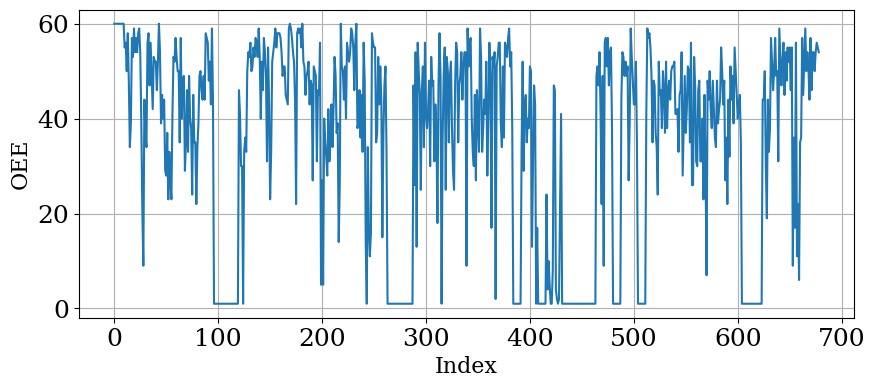

In [6]:
import matplotlib.pyplot as plt

# Plot the time series by index
plt.figure(figsize=(10, 4))
plt.plot(data.values)
plt.xlabel('Index')
plt.ylabel('OEE')

plt.grid(True)

# Save the plot as SVG
plt.savefig('ts_h1.svg', format='svg')

# Show the plot
plt.show()


# prepare to store results

In [7]:
# Initialize a DataFrame to store results
def initialize_results():
    columns = ['Model_Name', 'MAE', 'MAPE','Cost']
    return pd.DataFrame(columns=columns)

# Function to add new results to the DataFrame
def update_results(results_df, model_name, mae, mape,Cost):
    new_result = {'Model_Name': model_name, 'MAE': mae, 'MAPE': mape , 'Cost': Cost}
    results_df = pd.concat([results_df, pd.DataFrame([new_result])], ignore_index=True)
    return results_df
# Example usage
if __name__ == "__main__":
    # Initialize results DataFrame
    main_results = initialize_results()

# MODEL 0 BASE SARIMA WITHOUT DECOMPOSITION

In [8]:
start_time=time.time()

In [9]:
from statsmodels.tsa.stattools import kpss

# Applying the KPSS test to the training data to test for stationarity
kpss_test = kpss(data['Operation'], regression='c')

# Unpacking the KPSS test results
kpss_statistic, p_value, lags, critical_values = kpss_test

# Displaying the KPSS test results
kpss_test_result = {
    'KPSS Statistic': kpss_statistic,
    'p-value': p_value,
    'Lags Used': lags,
    'Critical Values': critical_values,
    'Conclusion': 'Stationary' if p_value > 0.05 else 'Not stationary'
}

kpss_test_result

C:\Users\ar600780\AppData\Local\Temp\ipykernel_3860\3746776136.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test = kpss(data['Operation'], regression='c')


{'KPSS Statistic': 0.3054655876791595,
 'p-value': 0.1,
 'Lags Used': 15,
 'Critical Values': {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739},
 'Conclusion': 'Stationary'}

In [10]:
from pmdarima.arima import auto_arima, OCSBTest, CHTest

# time series after first differencing
# OCSB test that returns the recommended order of seasonal differencing:
n_ocsb = OCSBTest(m=12).estimate_seasonal_differencing_term(data['Operation'])

# CH test that returns the recommended order of seasonal differencing:
n_ch = CHTest(m=12).estimate_seasonal_differencing_term(data['Operation'])

# seasonal differencing recommendation:
print("time series -")
n_seasdiffs = {"recommended order of seasonal differencing":"", "OCSB recommendation":n_ocsb, "nCH recommendation":n_ch}
[print(key, ":", value) for key,value in n_seasdiffs.items()]

time series -
recommended order of seasonal differencing : 
OCSB recommendation : 0
nCH recommendation : 0


[None, None, None]

In [11]:
train_data = data[:-4]  # Last 4 rows for testing
test_data = data[-4:]

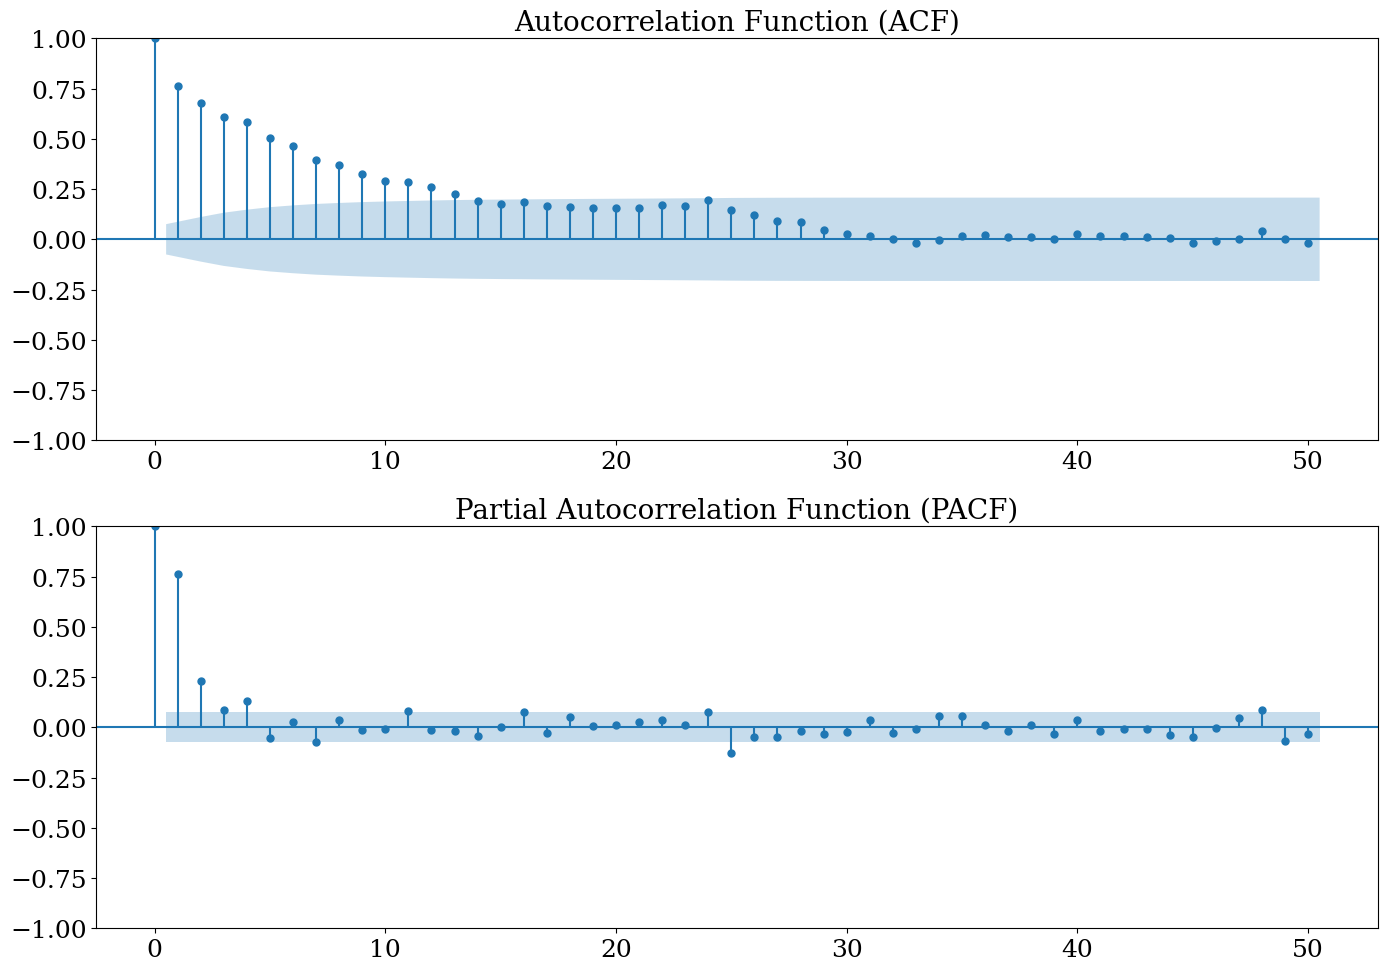

In [12]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot ACF and PACF for the cleaned training data
plt.figure(figsize=(14, 10))

# ACF plot
plt.subplot(2, 1, 1)
plot_acf(train_data['Operation'], lags=50, ax=plt.gca())
plt.title("Autocorrelation Function (ACF)")

# PACF plot
plt.subplot(2, 1, 2)
plot_pacf(train_data['Operation'], lags=50, ax=plt.gca(), method='ywm')
plt.title("Partial Autocorrelation Function (PACF)")

# Save the figure as an SVG file

plt.tight_layout()
plt.show()

                               SARIMAX Results                                
Dep. Variable:              Operation   No. Observations:                  675
Model:               SARIMAX(4, 0, 0)   Log Likelihood               -2693.564
Date:                Mon, 31 Mar 2025   AIC                           5397.127
Time:                        16:00:58   BIC                           5419.701
Sample:                             0   HQIC                          5405.868
                                - 675                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5906      0.031     18.865      0.000       0.529       0.652
ar.L2          0.1798      0.039      4.635      0.000       0.104       0.256
ar.L3          0.0332      0.043      0.771      0.4

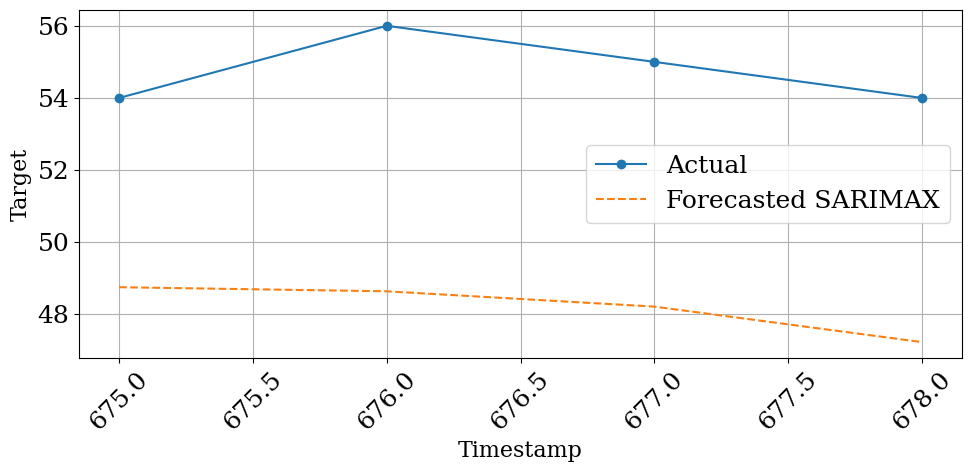

MAE: 6.54, MAPE: 0.12


In [13]:
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt

# Ensure data is sorted
train_data = train_data.sort_index()
test_data = test_data.sort_index()

# Fit SARIMAX model with combined Fourier terms
model = SARIMAX(train_data['Operation'], 
                order=(4, 0, 0),  # AR(4) with no differencing
                seasonal_order=(0, 0, 0, 8)
                )  
sarimax_results = model.fit(disp=False)
print(sarimax_results.summary())
# Forecast using combined Fourier terms
sarimax_forecast = sarimax_results.get_forecast(steps=len(test_data)).predicted_mean


# Evaluation metrics
sarimax_mae = mean_absolute_error(test_data['Operation'], sarimax_forecast)
sarimax_mape = mean_absolute_percentage_error(test_data['Operation'], sarimax_forecast)


# Plot results
plt.figure(figsize=(10, 5))
plt.plot(test_data.index, test_data['Operation'], label='Actual', marker='o')
plt.plot(test_data.index, sarimax_forecast, label='Forecasted SARIMAX', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Print evaluation metrics
print(f"MAE: {sarimax_mae:.2f}, MAPE: {sarimax_mape:.2f}")
mae=sarimax_mae
mape=sarimax_mape 


In [14]:
end_time=time.time()

In [15]:
Cost=end_time-start_time

In [16]:
main_results = update_results(main_results, 'BASE SARIMA WITHOUT DECOMPOSITION', mae, mape,Cost)

In [17]:
main_results

,Model_Name,MAE,MAPE,Cost
0,BASE SARIMA WITHOUT DECOMPOSITION,6.541955,0.119359,104.399591


# MODEL 0-1 BASE AUTO SARIMA WITHOUT DECOMPOSITION

In [16]:
start_time=time.time()

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[8] intercept   : AIC=5498.204, Time=0.05 sec
 ARIMA(1,1,0)(1,0,0)[8] intercept   : AIC=5426.703, Time=0.42 sec
 ARIMA(0,1,1)(0,0,1)[8] intercept   : AIC=5399.347, Time=0.38 sec
 ARIMA(0,1,0)(0,0,0)[8]             : AIC=5496.204, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[8] intercept   : AIC=5397.478, Time=0.20 sec
 ARIMA(0,1,1)(1,0,0)[8] intercept   : AIC=5399.341, Time=0.45 sec
 ARIMA(0,1,1)(1,0,1)[8] intercept   : AIC=5401.330, Time=1.33 sec
 ARIMA(1,1,1)(0,0,0)[8] intercept   : AIC=5393.418, Time=0.44 sec
 ARIMA(1,1,1)(1,0,0)[8] intercept   : AIC=5395.342, Time=0.74 sec
 ARIMA(1,1,1)(0,0,1)[8] intercept   : AIC=5395.344, Time=0.47 sec
 ARIMA(1,1,1)(1,0,1)[8] intercept   : AIC=5397.337, Time=1.68 sec
 ARIMA(1,1,0)(0,0,0)[8] intercept   : AIC=5424.762, Time=0.20 sec
 ARIMA(2,1,1)(0,0,0)[8] intercept   : AIC=inf, Time=1.39 sec
 ARIMA(1,1,2)(0,0,0)[8] intercept   : AIC=inf, Time=1.40 sec
 ARIMA(0,1,2)(0,0,0)[8] intercept   : AIC=5

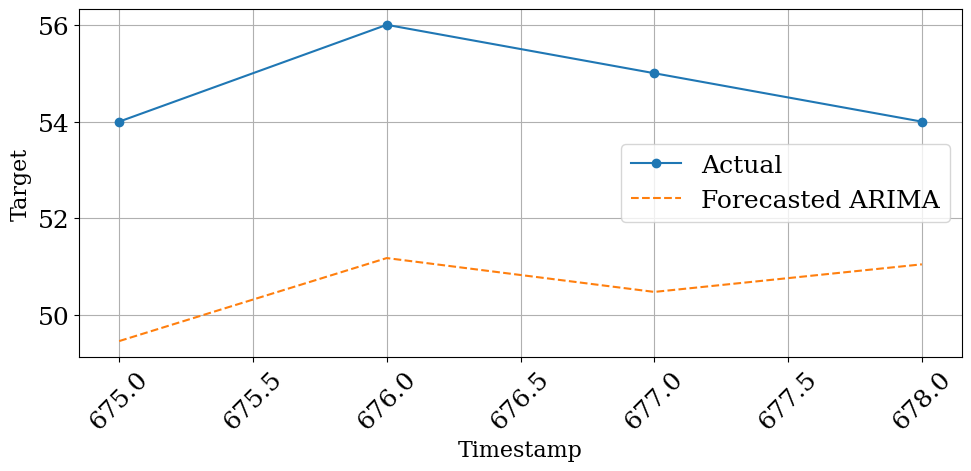

Test MAE: 4.2040
Test MAPE: 0.0767


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# Fit auto_arima with exogenous variables and seasonal period of 8
stepwise_model = auto_arima(
    y=train_data['Operation'],
    seasonal=True,
    m=8,
    start_p=0, start_q=0,
    max_p=5, max_q=5,
    start_P=0, start_Q=0,
    max_P=2, max_Q=2,
    d=None, D=None,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True,
    information_criterion='aic'
)

# Forecast for test period using exogenous variables
n_periods = len(test_data['Operation'])
sarima_predictions = stepwise_model.predict(n_periods=n_periods)

# Calculate evaluation metrics
sarima_mae = mean_absolute_error(test_data['Operation'], sarima_predictions)
sarima_mape = mean_absolute_percentage_error(test_data['Operation'], sarima_predictions)

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(test_data.index, test_data['Operation'], label='Actual', marker='o')
plt.plot(test_data.index, sarima_predictions, label='Forecasted ARIMA', linestyle='--')

plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Output the MAE and MAPE values
print("Test MAE: {:.4f}".format(sarima_mae))
print("Test MAPE: {:.4f}".format(sarima_mape))


In [18]:
end_time=time.time()

In [19]:
Cost=end_time-start_time

In [20]:
main_results = update_results(main_results, 'BASE AUTO SARIMA WITHOUT DECOMPOSITION', sarima_mae, sarima_mape,Cost)

In [21]:
main_results

,Model_Name,MAE,MAPE,Cost
0,BASE SARIMA WITHOUT DECOMPOSITION,6.541955,0.119359,18.071575
1,BASE AUTO SARIMA WITHOUT DECOMPOSITION,4.204041,0.076676,40.555002


### STOP HERE FOR ITERATION PURPOSES

In [26]:
data

,Operation
0,60
1,60
2,60
3,60
4,60
...,...
674,50
675,54
676,56
677,55


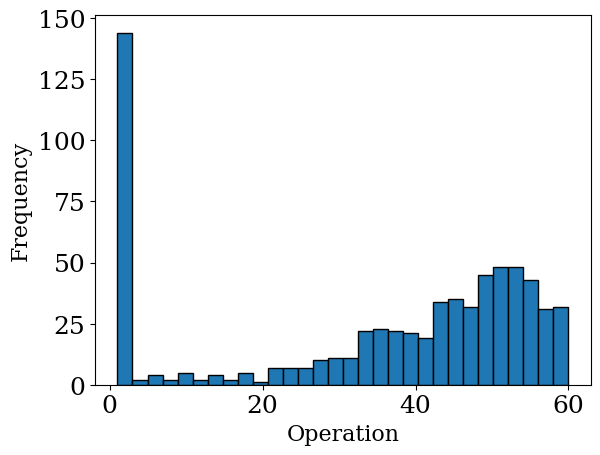

Skewness: -0.6954460357539106
Kurtosis: -1.0394719432110744


In [27]:
import matplotlib.pyplot as plt

# Plot the histogram for the 'Operation' column
plt.hist(data['Operation'], bins=30, edgecolor='black')
plt.xlabel('Operation')
plt.ylabel('Frequency')


# Save the figure as an SVG file
plt.savefig("hist_h1.svg", format="svg", dpi=900, bbox_inches='tight', facecolor='white')

# Show the plot
plt.show()

# Calculate skewness and kurtosis
skewness = data['Operation'].skew()
kurtosis = data['Operation'].kurt()

print("Skewness:", skewness)
print("Kurtosis:", kurtosis)


## PART I DECOMPOSITION

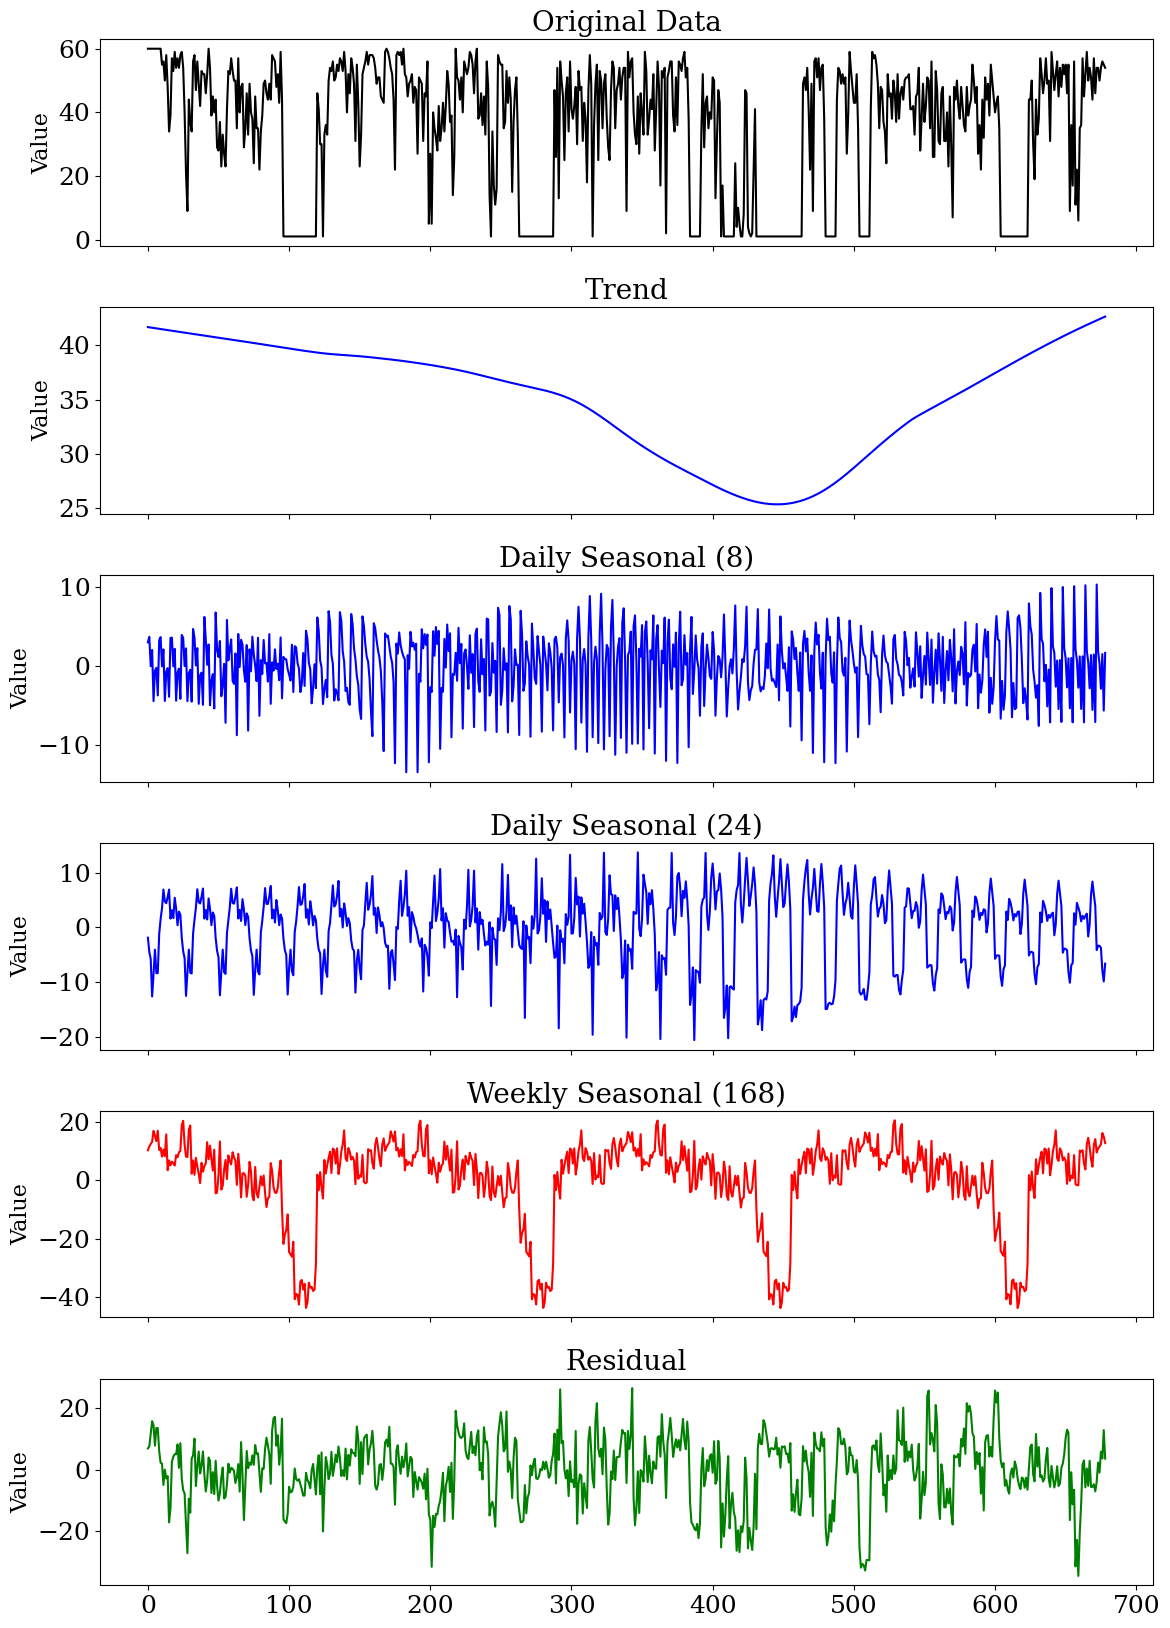

In [28]:
import pandas as pd
from statsmodels.tsa.seasonal import MSTL
import matplotlib.pyplot as plt

# Ensure the data is sorted by time
data = data.sort_index()

# MSTL decomposition
stl_kwargs = {"seasonal_deg": 0}
model = MSTL(data['Operation'], periods=(8, 24, 168), stl_kwargs=stl_kwargs)
res = model.fit()

# Extracting the seasonal components
seasonal_8=res.seasonal.iloc[:, 0]
seasonal_24 = res.seasonal.iloc[:, 1]  # Daily seasonal component
seasonal_168 = res.seasonal.iloc[:, 2]  # Weekly seasonal component
trend = res.trend
residual = res.resid

# Plotting
fig, axes = plt.subplots(6, 1, figsize=(12, 18), sharex=True)

data['Operation'].plot(ax=axes[0], color='black', title='Original Data')
axes[0].set_ylabel('Value')


trend.plot(ax=axes[1], color='blue', title='Trend')
axes[1].set_ylabel('Value')


seasonal_8.plot(ax=axes[2], color='blue', title='Daily Seasonal (8)')
axes[2].set_ylabel('Value')


seasonal_24.plot(ax=axes[3], color='blue', title='Daily Seasonal (24)')
axes[3].set_ylabel('Value')


seasonal_168.plot(ax=axes[4], color='red', title='Weekly Seasonal (168)')
axes[4].set_ylabel('Value')


residual.plot(ax=axes[5], color='green', title='Residual')
axes[5].set_ylabel('Value')

# Save the figure as an SVG file
plt.savefig("d_h1.svg", format="svg", dpi=900, bbox_inches='tight', facecolor='white')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [29]:
# Create DataFrames for each component
trend_df = pd.DataFrame({'Trend': trend})
seasonal_8_df = pd.DataFrame( {'Seasonal_8': seasonal_8})
seasonal_24_df = pd.DataFrame({ 'Seasonal_24': seasonal_24})
seasonal_168_df = pd.DataFrame({ 'Seasonal_168': seasonal_168})
residual_df = pd.DataFrame({ 'Operation': residual})

In [30]:
# Define the number of test samples
test_size = 4

# Divide each DataFrame into train and test sets
trend_train = trend_df.iloc[:-test_size]
trend_test = trend_df.iloc[-test_size:]

seasonal_8_train = seasonal_8_df.iloc[:-test_size]
seasonal_8_test = seasonal_8_df.iloc[-test_size:]

seasonal_24_train = seasonal_24_df.iloc[:-test_size]
seasonal_24_test = seasonal_24_df.iloc[-test_size:]

seasonal_168_train = seasonal_168_df.iloc[:-test_size]
seasonal_168_test = seasonal_168_df.iloc[-test_size:]

In [31]:
reference=data['Operation'].iloc[-test_size:]

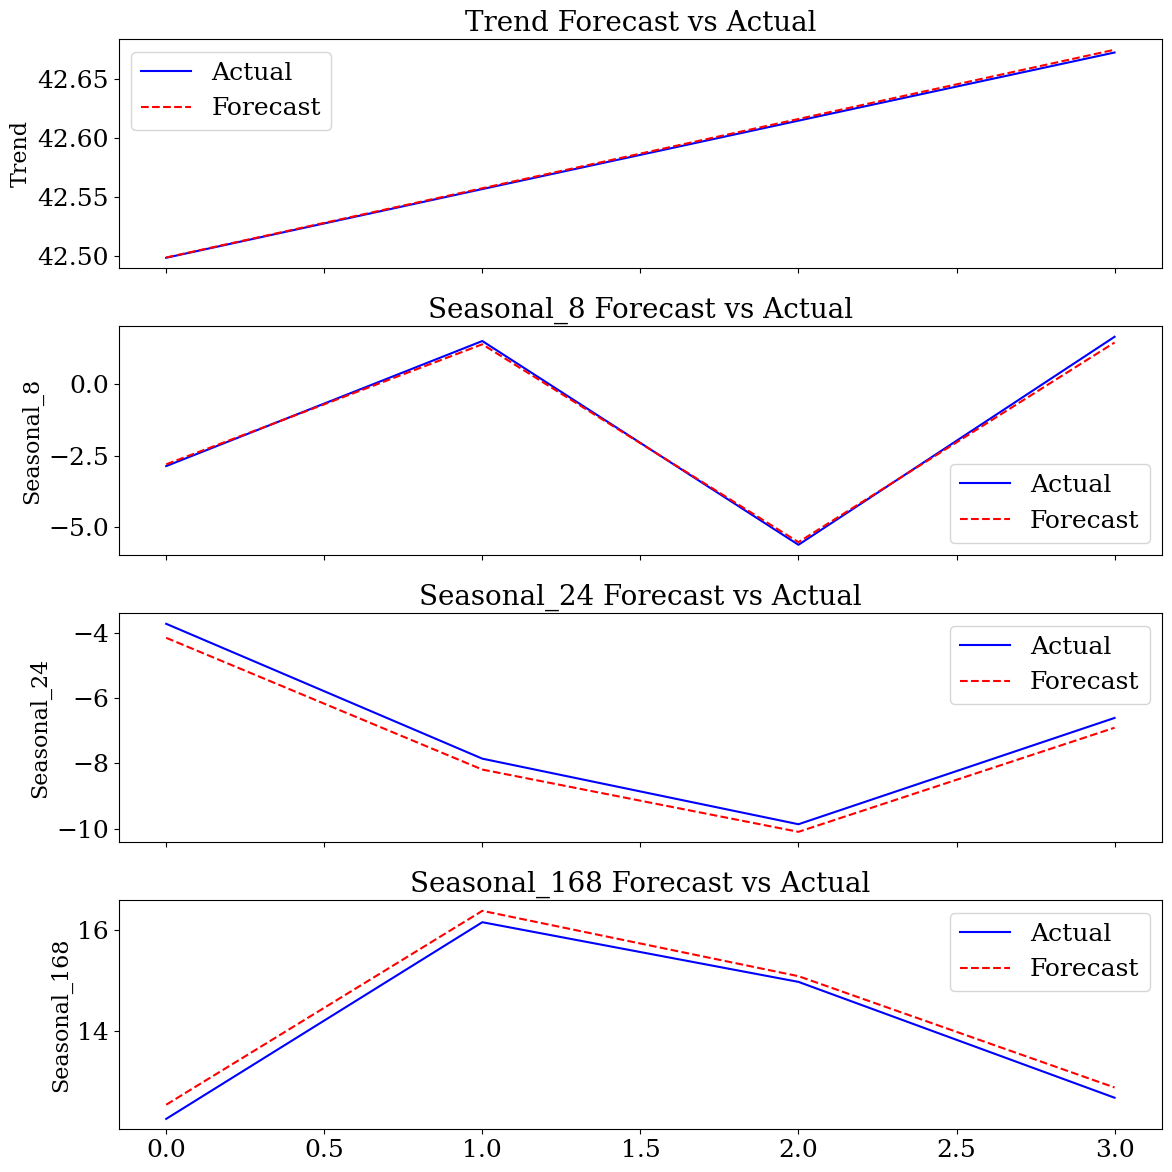

In [32]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing
# Initialize dictionaries to store results
mae_results = {}
mape_results = {}


# Define the ETS model (additive trend)
trend_model = ExponentialSmoothing(
    trend_train['Trend'], 
    trend='add',  # Use 'mul' for multiplicative trend if appropriate
    seasonal=None,  # No seasonality for pure trend modeling
    damped_trend=False  # Set to True if a damped trend is preferred
)

# Fit the model
fitted_trend_model = trend_model.fit()

# Forecast the next 20 data points
trend_forecast = np.array(fitted_trend_model.forecast(len(trend_test)))


# Calculate error metrics
mae_results['Trend'] = mean_absolute_error(trend_test['Trend'], trend_forecast)
mape_results['Trend'] = mean_absolute_percentage_error(trend_test['Trend'], trend_forecast)


# Forecast Seasonal (8) by repeating the last period's values
seasonal_8_forecast = np.tile(
    seasonal_8_train['Seasonal_8'][-8:].values,
    len(seasonal_8_test) // 8 + 1
)[:len(seasonal_8_test)]
mae_results['Seasonal_8'] = mean_absolute_error(seasonal_8_test['Seasonal_8'], seasonal_8_forecast)
mape_results['Seasonal_8'] = mean_absolute_percentage_error(seasonal_8_test['Seasonal_8'], seasonal_8_forecast)

# Forecast Seasonal (24) by repeating the last period's values
seasonal_24_forecast = np.tile(
    seasonal_24_train['Seasonal_24'][-24:].values,
    len(seasonal_24_test) // 24 + 1
)[:len(seasonal_24_test)]
mae_results['Seasonal_24'] = mean_absolute_error(seasonal_24_test['Seasonal_24'], seasonal_24_forecast)
mape_results['Seasonal_24'] = mean_absolute_percentage_error(seasonal_24_test['Seasonal_24'], seasonal_24_forecast)

# Forecast Seasonal (168) similarly
seasonal_168_forecast = np.tile(
    seasonal_168_train['Seasonal_168'][-168:].values,
    len(seasonal_168_test) // 168 + 1
)[:len(seasonal_168_test)]
mae_results['Seasonal_168'] = mean_absolute_error(seasonal_168_test['Seasonal_168'], seasonal_168_forecast)
mape_results['Seasonal_168'] = mean_absolute_percentage_error(seasonal_168_test['Seasonal_168'], seasonal_168_forecast)

# Plotting
fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)
components = ['Trend', 'Seasonal_8','Seasonal_24', 'Seasonal_168']
forecasts = [trend_forecast, seasonal_8_forecast, seasonal_24_forecast, seasonal_168_forecast]
test_data = [trend_test['Trend'],seasonal_8_test['Seasonal_8'], seasonal_24_test['Seasonal_24'], seasonal_168_test['Seasonal_168']]

for i, component in enumerate(components):
    axes[i].plot(test_data[i].values, label="Actual", color='blue')
    axes[i].plot(forecasts[i], label="Forecast", color='red', linestyle='dashed')
    axes[i].set_title(f'{component} Forecast vs Actual')
    axes[i].set_ylabel(component)
    axes[i].legend()

plt.tight_layout()
plt.show()



In [33]:
summed_up_array = np.sum(forecasts, axis=0)

In [34]:
import pandas as pd

# Assuming 'reference_df' is the reference DataFrame with the desired index
# and 'summed_up' is the array with values

summed_up = pd.DataFrame({
    'Index': reference.index,  # Use the index from the reference DataFrame
    'sum': summed_up_array  # Use the values from the array
})

# Set the index to match the reference DataFrame
summed_up.set_index('Index', inplace=True)

# Display the DataFrame
print(summed_up)

             sum
Index           
675    48.111896
676    52.132891
677    42.071367
678    50.125613


In [35]:
reference

675    54
676    56
677    55
678    54
Name: Operation, dtype: int64

In [36]:
file_path = 'summed_up.xlsx'
summed_up.to_excel(file_path, index=False)  # index=False to exclude the index column

In [37]:
file_path = 'reference.xlsx'
reference.to_excel(file_path, index=False)  # index=False to exclude the index column

## PART II FEATURE EXTRACTION

In [38]:
window_length = 24
window_size = 24
time_delay = 8
dimension = 3
stride = 1

In [39]:
df=residual_df

### STATISTICAL FEATURE EXTRACTION by TSFRESH

In [36]:
from tsfresh.feature_extraction import extract_features
from tsfresh.utilities.dataframe_functions import roll_time_series

In [37]:
start_time = time.time()

# Ensure tsfresh is installed
# !pip install tsfresh

# Add an index column to represent time
df['id'] = 1  # All data belongs to one time series
df['time'] = range(len(df))

# Rolling window to create overlapping segments
rolled_df = roll_time_series(df, column_id='id', column_sort='time', max_timeshift=window_size-1)

# Extract features using tsfresh
extracted_features = extract_features(
    rolled_df,
    column_id='id',
    column_sort='time',
    column_value='Operation',
    disable_progressbar=False
)


Feature Extraction: 100%|██████████| 30/30 [00:35<00:00,  1.18s/it]


In [38]:
extracted_features=extracted_features.reset_index(drop=True)

In [39]:
data = extracted_features.iloc[window_length-1:].reset_index(drop=True)

In [40]:
data

,Operation__variance_larger_than_standard_deviation,Operation__has_duplicate_max,Operation__has_duplicate_min,Operation__has_duplicate,Operation__sum_values,Operation__abs_energy,Operation__mean_abs_change,Operation__mean_change,Operation__mean_second_derivative_central,Operation__median,...,Operation__fourier_entropy__bins_5,Operation__fourier_entropy__bins_10,Operation__fourier_entropy__bins_100,Operation__permutation_entropy__dimension_3__tau_1,Operation__permutation_entropy__dimension_4__tau_1,Operation__permutation_entropy__dimension_5__tau_1,Operation__permutation_entropy__dimension_6__tau_1,Operation__permutation_entropy__dimension_7__tau_1,Operation__query_similarity_count__query_None__threshold_0.0,Operation__mean_n_absolute_max__number_of_maxima_7
0,1.0,0.0,0.0,0.0,95.695742,1887.835093,4.624834,0.074421,0.168289,5.008649,...,0.793730,1.178655,2.204785,1.729346,2.466577,2.787788,2.944439,2.890372,NaN,14.145075
1,1.0,0.0,0.0,0.0,85.715681,1849.618214,5.104600,-0.462486,-0.359744,4.580724,...,0.937156,1.178655,2.351673,1.756276,2.491494,2.857103,2.944439,2.890372,NaN,14.145075
2,1.0,0.0,0.0,0.0,71.436978,1837.554056,5.083057,-0.800683,-0.176204,3.342527,...,0.937156,1.412745,2.351673,1.735639,2.557508,2.857103,2.944439,2.890372,NaN,14.145075
3,1.0,0.0,0.0,0.0,51.935513,1761.573109,4.951505,-1.026648,0.006450,2.367940,...,0.983961,1.519383,2.458311,1.707390,2.516410,2.857103,2.944439,2.890372,NaN,13.704725
4,1.0,0.0,0.0,0.0,18.098915,1836.557741,5.336469,-1.411612,-0.081699,2.079532,...,1.031767,1.585771,2.564949,1.707390,2.463281,2.830940,2.944439,2.890372,NaN,14.021308
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
651,1.0,0.0,0.0,0.0,-161.075227,4298.486577,8.569862,-0.609381,-0.050302,-5.492154,...,0.937156,1.303876,2.138397,1.694077,2.557508,2.926418,2.944439,2.890372,NaN,21.671677
652,1.0,0.0,0.0,0.0,-168.309579,4162.245628,8.819000,-0.268830,0.801944,-5.492154,...,0.937156,1.377820,2.138397,1.591834,2.491494,2.926418,2.944439,2.890372,NaN,21.436498
653,1.0,0.0,0.0,0.0,-176.649935,4031.936004,7.673485,0.876684,-0.404457,-5.492154,...,0.830518,1.377820,2.098147,1.603319,2.557508,2.926418,2.944439,2.890372,NaN,21.317456
654,1.0,0.0,0.0,0.0,-147.227587,3925.382905,7.396083,0.599282,0.449153,-5.070439,...,0.925129,1.524707,2.351673,1.591834,2.466577,2.926418,2.944439,2.890372,NaN,20.800099


In [41]:
residual_df

,Operation,id,time
0,6.904692,1,0
1,7.561804,1,1
2,11.698816,1,2
3,15.810258,1,3
4,14.440726,1,4
...,...,...,...
674,-0.982344,1,674
675,5.799075,1,675
676,3.641816,1,676
677,12.900423,1,677


In [42]:
df_ref = df.iloc[window_length-1:].reset_index(drop=True)

In [43]:
# Identify columns with inf, -inf, or NaN values
cols_with_invalid_values = data.columns[data.isin([np.inf, -np.inf]).any() | data.isna().any()]

# Replace inf and -inf with NaN first
data.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill NaN values with column mean
data[cols_with_invalid_values] = data[cols_with_invalid_values].apply(lambda col: col.fillna(col.mean()), axis=0)


In [44]:
df_ref = df_ref.drop(index=0).reset_index(drop=True)

In [45]:
regression_target_series = df_ref['Operation']

In [46]:
# Combine features and target into a single dataset for regression analysis
regression_dataset = data.copy()

In [47]:
regression_dataset['Target'] = regression_target_series

In [48]:
df1=regression_dataset

In [49]:
df1 = df1.drop(index=df1.index[-1]).reset_index(drop=True)

In [50]:
df1 = df1.dropna(axis=1, how='all').loc[:, ~(df1 == np.inf).all()]

In [51]:
# Dropping columns with low variance from df1
if 'df1' in locals():
    # Calculate variance of each column
    variance = df1.var()
    
    # Threshold for low variance (can be adjusted)
    low_variance_threshold = 0.01  # Example: close to zero variance
    
    # Identify columns with variance below the threshold
    low_variance_columns = variance[variance < low_variance_threshold].index
    
    # Drop low variance columns
    df1 = df1.drop(columns=low_variance_columns)

In [52]:
df1

,Operation__sum_values,Operation__abs_energy,Operation__mean_abs_change,Operation__mean_change,Operation__mean_second_derivative_central,Operation__median,Operation__mean,Operation__standard_deviation,Operation__variation_coefficient,Operation__variance,...,Operation__count_above__t_0,Operation__count_below__t_0,Operation__fourier_entropy__bins_2,Operation__fourier_entropy__bins_3,Operation__fourier_entropy__bins_5,Operation__fourier_entropy__bins_10,Operation__fourier_entropy__bins_100,Operation__permutation_entropy__dimension_4__tau_1,Operation__mean_n_absolute_max__number_of_maxima_7,Target
0,95.695742,1887.835093,4.624834,0.074421,0.168289,5.008649,3.987323,7.922187,1.986844,62.761054,...,0.750000,0.250000,0.271189,0.535961,0.793730,1.178655,2.204785,2.466577,14.145075,-3.075369
1,85.715681,1849.618214,5.104600,-0.462486,-0.359744,4.580724,3.571487,8.019471,2.245415,64.311908,...,0.708333,0.291667,0.429323,0.535961,0.937156,1.178655,2.351673,2.491494,14.145075,-6.716898
2,71.436978,1837.554056,5.083057,-0.800683,-0.176204,3.342527,2.976541,8.228302,2.764384,67.704957,...,0.666667,0.333333,0.429323,0.429323,0.937156,1.412745,2.351673,2.557508,14.145075,-7.802650
3,51.935513,1761.573109,4.951505,-1.026648,0.006450,2.367940,2.163980,8.289516,3.830681,68.716071,...,0.625000,0.375000,0.429323,0.687092,0.983961,1.519383,2.458311,2.516410,13.704725,-18.026339
4,18.098915,1836.557741,5.336469,-1.411612,-0.081699,2.079532,0.754121,8.715190,11.556746,75.954540,...,0.583333,0.416667,0.429323,0.687092,1.031767,1.585771,2.564949,2.463281,14.021308,-27.334787
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
650,-149.788340,4403.705181,8.546572,-0.348797,0.080526,-5.492154,-6.241181,12.022287,-1.926284,144.535378,...,0.333333,0.666667,0.429323,0.687092,0.937156,1.410514,2.204785,2.557508,21.671677,-0.982344
651,-161.075227,4298.486577,8.569862,-0.609381,-0.050302,-5.492154,-6.711468,11.578420,-1.725170,134.059807,...,0.291667,0.708333,0.429323,0.687092,0.937156,1.303876,2.138397,2.557508,21.671677,5.799075
652,-168.309579,4162.245628,8.819000,-0.268830,0.801944,-5.492154,-7.012899,11.146576,-1.589439,124.246147,...,0.291667,0.708333,0.429323,0.687092,0.937156,1.377820,2.138397,2.491494,21.436498,3.641816
653,-176.649935,4031.936004,7.673485,0.876684,-0.404457,-5.492154,-7.360414,10.668722,-1.449473,113.821640,...,0.291667,0.708333,0.429323,0.429323,0.830518,1.377820,2.098147,2.557508,21.317456,12.900423


In [53]:
from sklearn.ensemble import RandomForestRegressor
from feature_engine.selection import SmartCorrelatedSelection

In [54]:
# Assume the last column is the target variable (modify if needed)
target_column = "Target"  # Change if your target column has a different name
X = df1.drop(columns=[target_column])  # Extract feature columns
y = df1[target_column]  # Define the target variable

# Initialize SmartCorrelatedSelection for regression
tr = SmartCorrelatedSelection(
    variables=None,  # Apply to all numeric features
    method="pearson",  # Pearson correlation method
    threshold=0.9,  # Correlation threshold
    missing_values="raise",  # Raise error if missing values exist
    selection_method="model_performance",  # Use model performance to select features
    estimator=RandomForestRegressor(random_state=1, n_estimators=100),  # RandomForest for regression
    scoring="r2",  # Use R² as the evaluation metric
    cv=3  # 3-fold cross-validation
)

# Fit and transform the dataset to select best features
X_selected = tr.fit_transform(X, y)

# Reconstruct df2 with selected features and target variable
df1 = pd.concat([X_selected, y], axis=1)

In [55]:
from sklearn.preprocessing import MinMaxScaler

# Separate features and target
features = df1.drop(columns=["Target"])
target = df1["Target"]

# Apply scaling only to features
scaler = MinMaxScaler()
features_scaled = pd.DataFrame(scaler.fit_transform(features), columns=features.columns, index=features.index)

# Recombine scaled features with the original Target
df1_scaled = pd.concat([features_scaled, target], axis=1)

In [56]:
end_time = time.time()
statistical_ext=start_time-end_time

In [57]:
file_path = 'statistical_data.xlsx'
df1_scaled.to_excel(file_path, index=False)  # index=False to exclude the index column

### TOPOLOGICAL FEATURE EXTRACTION

In [58]:
import pandas as pd
import numpy as np
from gtda.diagrams import (
    Scaler, PersistenceEntropy, Amplitude, BettiCurve, 
    PersistenceLandscape, Silhouette, HeatKernel
)
import gtda.time_series as ts
import gtda.diagrams as diag
from gtda.time_series import TakensEmbedding
from gtda.time_series import SlidingWindow
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
from gtda.pipeline import Pipeline
from gtda.homology import VietorisRipsPersistence
from gtda.plotting import plot_point_cloud

In [59]:
start_time = time.time()

In [60]:
X=df['Operation']

In [61]:
import numpy as np
import pandas as pd
from gtda.time_series import SlidingWindow, TakensEmbedding
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import Scaler

# Load your data (replace 'df' with your actual DataFrame)
X = df['Operation'].to_numpy()

# Sliding Window
SW = SlidingWindow(size=window_size, stride=stride)
X_sw = SW.fit_transform(X)

# Debugging shape
print(f"Sliding Window Output Shape: {X_sw.shape}")

# Takens Embedding
TE = TakensEmbedding(time_delay=time_delay, dimension=dimension)
X_te = TE.fit_transform(X_sw)

# Debugging shape
print(f"Takens Embedding Output Shape: {X_te.shape}")

# Vietoris-Rips Persistence
VR = VietorisRipsPersistence(homology_dimensions=[0, 1])
diagrams = VR.fit_transform(X_te)

# Debugging number of diagrams
print(f"Number of Persistence Diagrams: {len(diagrams)}")

# Scaling Persistence Diagrams
scaler = Scaler()
scaled_diagrams = scaler.fit_transform(diagrams)

# Debugging scaled diagrams shape
print(f"Scaled Diagrams Shape: {scaled_diagrams.shape}")


Sliding Window Output Shape: (656, 24)
Takens Embedding Output Shape: (656, 8, 3)
Number of Persistence Diagrams: 656
Scaled Diagrams Shape: (656, 9, 3)


In [62]:
# Initialize feature extractors
persistence_entropy = PersistenceEntropy()
amplitude_bottleneck = Amplitude(metric='bottleneck')
amplitude_wasserstein = Amplitude(metric='wasserstein')
amplitude_landscape = Amplitude(metric='landscape')
betti_curve = BettiCurve()
persistence_landscape = PersistenceLandscape()
silhouette = Silhouette()
heat_kernel = HeatKernel(sigma=0.1, n_bins=100, n_jobs=-1)

In [63]:
# Extract features
entropy_features = persistence_entropy.fit_transform(scaled_diagrams)
amplitude_bottleneck_features = amplitude_bottleneck.fit_transform(scaled_diagrams)
amplitude_wasserstein_features = amplitude_wasserstein.fit_transform(scaled_diagrams)
amplitude_landscape_features = amplitude_landscape.fit_transform(scaled_diagrams)
betti_features = betti_curve.fit_transform(scaled_diagrams)
landscape_features = persistence_landscape.fit_transform(scaled_diagrams)
silhouette_features = silhouette.fit_transform(scaled_diagrams)
heat_kernel_features = heat_kernel.fit_transform(scaled_diagrams)

In [64]:
betti_features.shape

(656, 2, 100)

In [65]:
l1_h0 = []
l2_h0 = []
l1_h1 = []
l2_h1 = []

for i in range(betti_features.shape[0]):
    h0_curve = betti_features[i, 0, :]
    h1_curve = betti_features[i, 1, :]

    l1_h0.append(np.sum(np.abs(h0_curve)))
    l2_h0.append(np.sqrt(np.sum(h0_curve**2)))

    l1_h1.append(np.sum(np.abs(h1_curve)))
    l2_h1.append(np.sqrt(np.sum(h1_curve**2)))

# Create DataFrame
betti_df = pd.DataFrame({
    'betti_L1_H0': l1_h0,
    'betti_L2_H0': l2_h0,
    'betti_L1_H1': l1_h1,
    'betti_L2_H1': l2_h1
})

# Show result
betti_df


,betti_L1_H0,betti_L2_H0,betti_L1_H1,betti_L2_H1
0,153,27.586228,0,0.000000
1,147,27.477263,0,0.000000
2,174,30.000000,0,0.000000
3,171,29.240383,0,0.000000
4,196,32.031235,0,0.000000
...,...,...,...,...
651,261,38.871583,0,0.000000
652,230,35.665109,0,0.000000
653,178,32.771939,0,0.000000
654,198,33.496268,3,1.732051


In [66]:
l1_h0_ls = []
l2_h0_ls = []
l1_h1_ls = []
l2_h1_ls = []

for i in range(landscape_features.shape[0]):
    h0_landscape = landscape_features[i, 0, :]
    h1_landscape = landscape_features[i, 1, :]

    l1_h0_ls.append(np.sum(np.abs(h0_landscape)))
    l2_h0_ls.append(np.sqrt(np.sum(h0_landscape**2)))

    l1_h1_ls.append(np.sum(np.abs(h1_landscape)))
    l2_h1_ls.append(np.sqrt(np.sum(h1_landscape**2)))

# Create DataFrame
landscape_df = pd.DataFrame({
    'landscape_features_L1_H0_LS': l1_h0_ls,
    'landscape_features_L2_H0_LS': l2_h0_ls,
    'landscape_features_L1_H1_LS': l1_h1_ls,
    'landscape_features_L2_H1_LS': l2_h1_ls
})

# Show result
landscape_df


,landscape_features_L1_H0_LS,landscape_features_L2_H0_LS,landscape_features_L1_H1_LS,landscape_features_L2_H1_LS
0,9.466145,1.661243,0.000000,0.000000
1,6.973635,1.321040,0.000000,0.000000
2,7.911656,1.452253,0.000000,0.000000
3,7.911656,1.452253,0.000000,0.000000
4,8.250686,1.498672,0.000000,0.000000
...,...,...,...,...
651,22.001070,3.127772,0.000000,0.000000
652,22.001070,3.127772,0.000000,0.000000
653,4.993632,1.028320,0.000000,0.000000
654,9.309054,1.640676,0.021678,0.015402


In [67]:
l1_h0_si = []
l2_h0_si = []
l1_h1_si = []
l2_h1_si = []

for i in range(silhouette_features.shape[0]):
    h0_silhouette = silhouette_features[i, 0, :]
    h1_silhouette = silhouette_features[i, 1, :]

    l1_h0_si.append(np.sum(np.abs(h0_silhouette)))
    l2_h0_si.append(np.sqrt(np.sum(h0_silhouette**2)))

    l1_h1_si.append(np.sum(np.abs(h1_silhouette)))
    l2_h1_si.append(np.sqrt(np.sum(h1_silhouette**2)))

# Create DataFrame
silhouette_df = pd.DataFrame({
    'silhouette_features_L1_H0_SI': l1_h0_si,
    'silhouette_features_L2_H0_SI': l2_h0_si,
    'silhouette_features_L1_H1_SI': l1_h1_si,
    'silhouette_features_L2_H1_SI': l2_h1_si
})

# Show result
silhouette_df.head()


,silhouette_features_L1_H0_SI,silhouette_features_L2_H0_SI,silhouette_features_L1_H1_SI,silhouette_features_L2_H1_SI
0,4.849882,0.845476,0.0,0.0
1,4.006875,0.743882,0.0,0.0
2,5.146299,0.946214,0.0,0.0
3,5.264502,0.971164,0.0,0.0
4,6.109257,1.123398,0.0,0.0


In [68]:
# Flatten entropy features
entropy_flattened = entropy_features.reshape(entropy_features.shape[0], -1)
entropy_df = pd.DataFrame(entropy_flattened, columns=[f"entropy_{i}" for i in range(entropy_flattened.shape[1])])

In [69]:
entropy_df

,entropy_0,entropy_1
0,2.596761,-1.000000
1,2.627987,0.000000
2,2.634374,0.000000
3,2.591366,0.000000
4,2.618160,-1.000000
...,...,...
651,2.720919,-1.000000
652,2.673963,-1.000000
653,2.749617,-1.000000
654,2.712209,0.000000


In [70]:
# Flatten amplitude bottleneck features
amplitude_bottleneck_flattened = amplitude_bottleneck_features.reshape(amplitude_bottleneck_features.shape[0], -1)
amplitude_bottleneck_df = pd.DataFrame(amplitude_bottleneck_flattened, columns=[f"amplitude_bottleneck_{i}" for i in range(amplitude_bottleneck_flattened.shape[1])])
amplitude_bottleneck_df 

,amplitude_bottleneck_0,amplitude_bottleneck_1
0,0.437362,0.000000
1,0.375436,0.004320
2,0.399812,0.004320
3,0.399812,0.004320
4,0.408287,0.000000
...,...,...
651,0.666683,0.000000
652,0.666683,0.000000
653,0.317667,0.000000
654,0.433765,0.016639


In [71]:
# Flatten amplitude wasserstein features
amplitude_wasserstein_flattened = amplitude_wasserstein_features.reshape(amplitude_wasserstein_features.shape[0], -1)
amplitude_wasserstein_df = pd.DataFrame(amplitude_wasserstein_flattened, columns=[f"amplitude_wasserstein_{i}" for i in range(amplitude_wasserstein_flattened.shape[1])])
amplitude_wasserstein_df


,amplitude_wasserstein_0,amplitude_wasserstein_1
0,0.655480,0.000000
1,0.615890,0.004320
2,0.723631,0.004320
3,0.723243,0.004320
4,0.811710,0.000000
...,...,...
651,1.039887,0.000000
652,0.944377,0.000000
653,0.684173,0.000000
654,0.786057,0.016639


In [72]:
amplitude_landscape_flattened = amplitude_landscape_features.reshape(amplitude_landscape_features.shape[0], -1)
amplitude_landscape_df = pd.DataFrame(amplitude_landscape_flattened, columns=[f"amplitude_landscape_{i}" for i in range(amplitude_landscape_flattened.shape[1])])
amplitude_landscape_df 

,amplitude_landscape_0,amplitude_landscape_1
0,0.236119,0.000000
1,0.187764,0.000000
2,0.206414,0.000000
3,0.206414,0.000000
4,0.213012,0.000000
...,...,...
651,0.444562,0.000000
652,0.444562,0.000000
653,0.146159,0.000000
654,0.233196,0.001734


In [73]:
heat_kernel_features.shape

(656, 2, 100, 100)

In [74]:
def compute_entropy(matrix):
    p = matrix.flatten()
    p = p[p > 0]  # Avoid log(0)
    p /= p.sum()  # Normalize to probability distribution
    return -np.sum(p * np.log(p))

def extract_heat_kernel_features(heat_kernel_features):
    feature_list = []

    for i in range(heat_kernel_features.shape[0]):  # for each sample
        features_sample = {}

        for dim, h_dim in enumerate(["H0", "H1"]):
            matrix = heat_kernel_features[i, dim, :, :]  # shape: (100, 100)

            # Global features
            features_sample[f"L1_{h_dim}"] = np.sum(np.abs(matrix))
            features_sample[f"L2_{h_dim}"] = np.sqrt(np.sum(matrix ** 2))

            # Per-column features
            for col in range(matrix.shape[1]):
                col_data = matrix[:, col]
                features_sample[f"Col{col}_L1_{h_dim}"] = np.sum(np.abs(col_data))
                features_sample[f"Col{col}_L2_{h_dim}"] = np.sqrt(np.sum(col_data ** 2))

        feature_list.append(features_sample)

    heat_kernel_df = pd.DataFrame(feature_list)
    return heat_kernel_df

# Usage
heat_kernel_df = extract_heat_kernel_features(heat_kernel_features)
heat_kernel_df.head()


,L1_H0,L2_H0,Col0_L1_H0,Col0_L2_H0,Col1_L1_H0,Col1_L2_H0,Col2_L1_H0,Col2_L2_H0,Col3_L1_H0,Col3_L2_H0,...,Col95_L1_H1,Col95_L2_H1,Col96_L1_H1,Col96_L2_H1,Col97_L1_H1,Col97_L2_H1,Col98_L1_H1,Col98_L2_H1,Col99_L1_H1,Col99_L2_H1
0,16721.547207,688.804122,1343.469298,225.872548,1304.948962,220.193732,1217.759184,205.721164,1095.144065,184.319117,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,16721.547000,704.283596,1343.469298,230.704960,1304.948962,224.952031,1217.759184,210.226649,1095.144065,188.418837,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,17126.124171,665.775875,1350.243106,216.241690,1314.040154,211.185983,1228.508277,197.803440,1105.913730,177.766359,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,16242.181197,620.530583,1285.792244,201.842800,1247.160919,196.772546,1163.847647,184.100343,1047.211000,165.460642,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,16460.623431,644.714359,1288.074140,208.235624,1250.432595,203.343905,1167.931564,190.637337,1051.427124,171.712262,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [75]:
# Combine all the DataFrames into a single DataFrame
combined_df = pd.concat([
    entropy_df,
    amplitude_bottleneck_df,
    amplitude_wasserstein_df,
    amplitude_landscape_df,
    betti_df,
    landscape_df,
    silhouette_df,
    heat_kernel_df
], axis=1)


In [76]:
def compute_carlsson_features(births, deaths, fn_max=5):
    lifetimes = deaths - births
    d_max = np.max(deaths) if len(deaths) > 0 else 0
    
    f1 = np.sum(births * lifetimes) if fn_max >= 1 else None
    f2 = np.sum((d_max - deaths) * lifetimes) if fn_max >= 2 else None
    f3 = np.sum((births ** 2) * (lifetimes ** 4)) if fn_max >= 3 else None
    f4 = np.sum(((d_max - deaths) ** 2) * (lifetimes ** 4)) if fn_max >= 4 else None
    f5 = np.max(lifetimes) if (fn_max >= 5 and len(lifetimes) > 0) else None

    return f1, f2, f3, f4, f5

features = {}
fn_max = 5  # You can adjust the number of Carlsson features

for dim in range(2):  # Loop over each homology dimension (0 and 1)
    filtered_diagrams = [diagram[diagram[:, 2] == dim] for diagram in scaled_diagrams]

    lifetimes = [diagram[:, 1] - diagram[:, 0] for diagram in filtered_diagrams]

    for i, lifetime in enumerate(lifetimes):
        sample_key = f'sample_{i + 1}'
        if sample_key not in features:
            features[sample_key] = {}

        features[sample_key][f'dim_{dim}_num_features'] = len(lifetime)
        features[sample_key][f'dim_{dim}_sum_lifetimes'] = np.sum(lifetime)

        if len(lifetime) > 0:
            features[sample_key][f'dim_{dim}_max_lifetime'] = np.max(lifetime)
            features[sample_key][f'dim_{dim}_mean_lifetime'] = np.mean(lifetime)
            features[sample_key][f'dim_{dim}_median_lifetime'] = np.median(lifetime)
            features[sample_key][f'dim_{dim}_std_lifetime'] = np.std(lifetime)
            features[sample_key][f'dim_{dim}_variance_lifetime'] = np.var(lifetime)
            features[sample_key][f'dim_{dim}_min_lifetime'] = np.min(lifetime)

            birth_times = filtered_diagrams[i][:, 0]
            death_times = filtered_diagrams[i][:, 1]

            features[sample_key][f'dim_{dim}_sum_birth_times'] = np.sum(birth_times)
            features[sample_key][f'dim_{dim}_mean_birth_time'] = np.mean(birth_times)
            features[sample_key][f'dim_{dim}_sum_death_times'] = np.sum(death_times)
            features[sample_key][f'dim_{dim}_mean_death_time'] = np.mean(death_times)

            # Add Carlsson features:
            f1, f2, f3, f4, f5 = compute_carlsson_features(birth_times, death_times, fn_max=fn_max)
            if f1 is not None:
                features[sample_key][f'dim_{dim}_carlsson_f1'] = f1
            if f2 is not None:
                features[sample_key][f'dim_{dim}_carlsson_f2'] = f2
            if f3 is not None:
                features[sample_key][f'dim_{dim}_carlsson_f3'] = f3
            if f4 is not None:
                features[sample_key][f'dim_{dim}_carlsson_f4'] = f4
            if f5 is not None:
                features[sample_key][f'dim_{dim}_carlsson_f5'] = f5

        else:
            # Fill zeros if empty diagram
            for metric in ['max_lifetime', 'mean_lifetime', 'median_lifetime', 'std_lifetime', 'variance_lifetime', 'min_lifetime', 'sum_birth_times', 'mean_birth_time', 'sum_death_times', 'mean_death_time']:
                features[sample_key][f'dim_{dim}_{metric}'] = 0

            # Add Carlsson feature zeros if empty
            for j in range(1, fn_max + 1):
                features[sample_key][f'dim_{dim}_carlsson_f{j}'] = 0

# Convert the nested dictionary to a DataFrame
features_df = pd.DataFrame.from_dict(features, orient='index')
features_df.reset_index(inplace=True)
features_df.rename(columns={'index': 'sample'}, inplace=True)
features_df.drop(columns=['sample'], inplace=True)

In [77]:
features_df.columns

Index(['dim_0_num_features', 'dim_0_sum_lifetimes', 'dim_0_max_lifetime',
       'dim_0_mean_lifetime', 'dim_0_median_lifetime', 'dim_0_std_lifetime',
       'dim_0_variance_lifetime', 'dim_0_min_lifetime',
       'dim_0_sum_birth_times', 'dim_0_mean_birth_time',
       'dim_0_sum_death_times', 'dim_0_mean_death_time', 'dim_0_carlsson_f1',
       'dim_0_carlsson_f2', 'dim_0_carlsson_f3', 'dim_0_carlsson_f4',
       'dim_0_carlsson_f5', 'dim_1_num_features', 'dim_1_sum_lifetimes',
       'dim_1_max_lifetime', 'dim_1_mean_lifetime', 'dim_1_median_lifetime',
       'dim_1_std_lifetime', 'dim_1_variance_lifetime', 'dim_1_min_lifetime',
       'dim_1_sum_birth_times', 'dim_1_mean_birth_time',
       'dim_1_sum_death_times', 'dim_1_mean_death_time', 'dim_1_carlsson_f1',
       'dim_1_carlsson_f2', 'dim_1_carlsson_f3', 'dim_1_carlsson_f4',
       'dim_1_carlsson_f5'],
      dtype='object')

In [78]:
features_df

,dim_0_num_features,dim_0_sum_lifetimes,dim_0_max_lifetime,dim_0_mean_lifetime,dim_0_median_lifetime,dim_0_std_lifetime,dim_0_variance_lifetime,dim_0_min_lifetime,dim_0_sum_birth_times,dim_0_mean_birth_time,...,dim_1_min_lifetime,dim_1_sum_birth_times,dim_1_mean_birth_time,dim_1_sum_death_times,dim_1_mean_death_time,dim_1_carlsson_f1,dim_1_carlsson_f2,dim_1_carlsson_f3,dim_1_carlsson_f4,dim_1_carlsson_f5
0,7,3.022152,0.874724,0.431736,0.289460,0.243147,0.059121,0.194809,0.0,0.0,...,0.000000,0.641971,0.320985,0.641971,0.320985,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000
1,7,2.898300,0.750872,0.414043,0.289460,0.212893,0.045323,0.194809,0.0,0.0,...,0.000000,1.137560,0.568780,1.146200,0.573100,0.007055,0.000000,3.715314e-09,0.000000e+00,0.008640
2,7,3.448703,0.799623,0.492672,0.414459,0.237695,0.056499,0.194809,0.0,0.0,...,0.000000,1.137560,0.568780,1.146200,0.573100,0.007055,0.000000,3.715314e-09,0.000000e+00,0.008640
3,7,3.392431,0.799623,0.484633,0.441690,0.253050,0.064034,0.111305,0.0,0.0,...,0.000000,1.137560,0.568780,1.146200,0.573100,0.007055,0.000000,3.715314e-09,0.000000e+00,0.008640
4,7,3.891388,0.816575,0.555913,0.693360,0.259730,0.067460,0.111305,0.0,0.0,...,0.000000,0.641971,0.320985,0.641971,0.320985,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
651,7,5.163580,1.333366,0.737654,0.607954,0.271642,0.073790,0.528200,0.0,0.0,...,0.000000,0.641971,0.320985,0.641971,0.320985,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000
652,7,4.540607,1.333366,0.648658,0.587537,0.298111,0.088870,0.296943,0.0,0.0,...,0.000000,0.641971,0.320985,0.641971,0.320985,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000
653,7,3.495065,0.635334,0.499295,0.551272,0.134857,0.018186,0.287824,0.0,0.0,...,0.000000,0.641971,0.320985,0.641971,0.320985,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000
654,7,3.920376,0.867531,0.560054,0.587537,0.198538,0.039417,0.287824,0.0,0.0,...,0.000000,1.218313,0.609156,1.251590,0.625795,0.029861,0.000000,9.874016e-07,0.000000e+00,0.033277


In [79]:
features_df.reset_index(drop=True, inplace=True)

In [80]:
features_df

,dim_0_num_features,dim_0_sum_lifetimes,dim_0_max_lifetime,dim_0_mean_lifetime,dim_0_median_lifetime,dim_0_std_lifetime,dim_0_variance_lifetime,dim_0_min_lifetime,dim_0_sum_birth_times,dim_0_mean_birth_time,...,dim_1_min_lifetime,dim_1_sum_birth_times,dim_1_mean_birth_time,dim_1_sum_death_times,dim_1_mean_death_time,dim_1_carlsson_f1,dim_1_carlsson_f2,dim_1_carlsson_f3,dim_1_carlsson_f4,dim_1_carlsson_f5
0,7,3.022152,0.874724,0.431736,0.289460,0.243147,0.059121,0.194809,0.0,0.0,...,0.000000,0.641971,0.320985,0.641971,0.320985,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000
1,7,2.898300,0.750872,0.414043,0.289460,0.212893,0.045323,0.194809,0.0,0.0,...,0.000000,1.137560,0.568780,1.146200,0.573100,0.007055,0.000000,3.715314e-09,0.000000e+00,0.008640
2,7,3.448703,0.799623,0.492672,0.414459,0.237695,0.056499,0.194809,0.0,0.0,...,0.000000,1.137560,0.568780,1.146200,0.573100,0.007055,0.000000,3.715314e-09,0.000000e+00,0.008640
3,7,3.392431,0.799623,0.484633,0.441690,0.253050,0.064034,0.111305,0.0,0.0,...,0.000000,1.137560,0.568780,1.146200,0.573100,0.007055,0.000000,3.715314e-09,0.000000e+00,0.008640
4,7,3.891388,0.816575,0.555913,0.693360,0.259730,0.067460,0.111305,0.0,0.0,...,0.000000,0.641971,0.320985,0.641971,0.320985,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
651,7,5.163580,1.333366,0.737654,0.607954,0.271642,0.073790,0.528200,0.0,0.0,...,0.000000,0.641971,0.320985,0.641971,0.320985,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000
652,7,4.540607,1.333366,0.648658,0.587537,0.298111,0.088870,0.296943,0.0,0.0,...,0.000000,0.641971,0.320985,0.641971,0.320985,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000
653,7,3.495065,0.635334,0.499295,0.551272,0.134857,0.018186,0.287824,0.0,0.0,...,0.000000,0.641971,0.320985,0.641971,0.320985,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000
654,7,3.920376,0.867531,0.560054,0.587537,0.198538,0.039417,0.287824,0.0,0.0,...,0.000000,1.218313,0.609156,1.251590,0.625795,0.029861,0.000000,9.874016e-07,0.000000e+00,0.033277


In [81]:
final_combined_df = pd.concat([combined_df.reset_index(drop=True), features_df], axis=1)

In [82]:
final_combined_df

,entropy_0,entropy_1,amplitude_bottleneck_0,amplitude_bottleneck_1,amplitude_wasserstein_0,amplitude_wasserstein_1,amplitude_landscape_0,amplitude_landscape_1,betti_L1_H0,betti_L2_H0,...,dim_1_min_lifetime,dim_1_sum_birth_times,dim_1_mean_birth_time,dim_1_sum_death_times,dim_1_mean_death_time,dim_1_carlsson_f1,dim_1_carlsson_f2,dim_1_carlsson_f3,dim_1_carlsson_f4,dim_1_carlsson_f5
0,2.596761,-1.000000,0.437362,0.000000,0.655480,0.000000,0.236119,0.000000,153,27.586228,...,0.000000,0.641971,0.320985,0.641971,0.320985,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000
1,2.627987,0.000000,0.375436,0.004320,0.615890,0.004320,0.187764,0.000000,147,27.477263,...,0.000000,1.137560,0.568780,1.146200,0.573100,0.007055,0.000000,3.715314e-09,0.000000e+00,0.008640
2,2.634374,0.000000,0.399812,0.004320,0.723631,0.004320,0.206414,0.000000,174,30.000000,...,0.000000,1.137560,0.568780,1.146200,0.573100,0.007055,0.000000,3.715314e-09,0.000000e+00,0.008640
3,2.591366,0.000000,0.399812,0.004320,0.723243,0.004320,0.206414,0.000000,171,29.240383,...,0.000000,1.137560,0.568780,1.146200,0.573100,0.007055,0.000000,3.715314e-09,0.000000e+00,0.008640
4,2.618160,-1.000000,0.408287,0.000000,0.811710,0.000000,0.213012,0.000000,196,32.031235,...,0.000000,0.641971,0.320985,0.641971,0.320985,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
651,2.720919,-1.000000,0.666683,0.000000,1.039887,0.000000,0.444562,0.000000,261,38.871583,...,0.000000,0.641971,0.320985,0.641971,0.320985,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000
652,2.673963,-1.000000,0.666683,0.000000,0.944377,0.000000,0.444562,0.000000,230,35.665109,...,0.000000,0.641971,0.320985,0.641971,0.320985,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000
653,2.749617,-1.000000,0.317667,0.000000,0.684173,0.000000,0.146159,0.000000,178,32.771939,...,0.000000,0.641971,0.320985,0.641971,0.320985,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000
654,2.712209,0.000000,0.433765,0.016639,0.786057,0.016639,0.233196,0.001734,198,33.496268,...,0.000000,1.218313,0.609156,1.251590,0.625795,0.029861,0.000000,9.874016e-07,0.000000e+00,0.033277


In [83]:
final_combined_df = final_combined_df.loc[:, ~final_combined_df.isin([np.inf, -np.inf]).any() & final_combined_df.notna().all()]

In [84]:
# Dropping columns with low variance from final_combined_df
if 'final_combined_df' in locals():
    # Calculate variance of each column
    variance = final_combined_df.var()
    
    # Threshold for low variance (can be adjusted)
    low_variance_threshold = 0.01  # Example: close to zero variance
    
    # Identify columns with variance below the threshold
    low_variance_columns = variance[variance < low_variance_threshold].index
    
    # Drop low variance columns
    final_combined_df_cleaned = final_combined_df.drop(columns=low_variance_columns)

In [85]:
data=final_combined_df_cleaned

In [86]:
# Identify columns with inf, -inf, or NaN values
cols_with_invalid_values = data.columns[data.isin([np.inf, -np.inf]).any() | data.isna().any()]

# Replace inf and -inf with NaN first
data.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill NaN values with column mean
data[cols_with_invalid_values] = data[cols_with_invalid_values].apply(lambda col: col.fillna(col.mean()), axis=0)

In [87]:
simplified_df=data

In [88]:
# Adjust the indices of the feature dataset for regression analysis
regression_features_df = simplified_df[:-1].reset_index(drop=True)
regression_target_series = df['Operation'][window_size:].reset_index(drop=True)

# Combine features and target into a single dataset for regression analysis
regression_dataset = regression_features_df.copy()
regression_dataset['Target'] = regression_target_series

In [89]:
df2=regression_dataset

In [90]:
df2

,entropy_0,entropy_1,amplitude_bottleneck_0,amplitude_wasserstein_0,amplitude_landscape_0,betti_L1_H0,betti_L2_H0,betti_L1_H1,betti_L2_H1,landscape_features_L1_H0_LS,...,dim_0_sum_death_times,dim_0_mean_death_time,dim_0_carlsson_f2,dim_0_carlsson_f4,dim_0_carlsson_f5,dim_1_sum_birth_times,dim_1_mean_birth_time,dim_1_sum_death_times,dim_1_mean_death_time,Target
0,2.596761,-1.0,0.437362,0.655480,0.236119,153,27.586228,0,0.000000,9.466145,...,3.022152,0.431736,0.924932,0.019318,0.874724,0.641971,0.320985,0.641971,0.320985,-3.075369
1,2.627987,0.0,0.375436,0.615890,0.187764,147,27.477263,0,0.000000,6.973635,...,2.898300,0.414043,0.658968,0.007819,0.750872,1.137560,0.568780,1.146200,0.573100,-6.716898
2,2.634374,0.0,0.399812,0.723631,0.206414,174,30.000000,0,0.000000,7.911656,...,3.448703,0.492672,0.663093,0.010765,0.799623,1.137560,0.568780,1.146200,0.573100,-7.802650
3,2.591366,0.0,0.399812,0.723243,0.206414,171,29.240383,0,0.000000,7.911656,...,3.392431,0.484633,0.620344,0.010809,0.799623,1.137560,0.568780,1.146200,0.573100,-18.026339
4,2.618160,-1.0,0.408287,0.811710,0.213012,196,32.031235,0,0.000000,8.250686,...,3.891388,0.555913,0.542119,0.012156,0.816575,0.641971,0.320985,0.641971,0.320985,-27.334787
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
650,2.616373,-1.0,0.666683,1.097896,0.444562,262,36.578682,0,0.000000,22.001070,...,5.209372,0.744196,2.124499,0.374020,1.333366,0.641971,0.320985,0.641971,0.320985,-0.982344
651,2.720919,-1.0,0.666683,1.039887,0.444562,261,38.871583,0,0.000000,22.001070,...,5.163580,0.737654,2.559477,0.446931,1.333366,0.641971,0.320985,0.641971,0.320985,5.799075
652,2.673963,-1.0,0.666683,0.944377,0.444562,230,35.665109,0,0.000000,22.001070,...,4.540607,0.648658,2.486896,0.332867,1.333366,0.641971,0.320985,0.641971,0.320985,3.641816
653,2.749617,-1.0,0.317667,0.684173,0.146159,178,32.771939,0,0.000000,4.993632,...,3.495065,0.499295,0.348162,0.003640,0.635334,0.641971,0.320985,0.641971,0.320985,12.900423


In [91]:
from sklearn.ensemble import RandomForestRegressor
from feature_engine.selection import SmartCorrelatedSelection

In [92]:
# Assume the last column is the target variable (modify if needed)
target_column = "Target"  # Change if your target column has a different name
X = df2.drop(columns=[target_column])  # Extract feature columns
y = df2[target_column]  # Define the target variable

# Initialize SmartCorrelatedSelection for regression
tr = SmartCorrelatedSelection(
    variables=None,  # Apply to all numeric features
    method="pearson",  # Pearson correlation method
    threshold=0.99,  # Correlation threshold
    missing_values="raise",  # Raise error if missing values exist
    selection_method="model_performance",  # Use model performance to select features
    estimator=RandomForestRegressor(random_state=1, n_estimators=100),  # RandomForest for regression
    scoring="r2",  # Use R² as the evaluation metric
    cv=3  # 3-fold cross-validation
)

# Fit and transform the dataset to select best features
X_selected = tr.fit_transform(X, y)

# Reconstruct df2 with selected features and target variable
df2 = pd.concat([X_selected, y], axis=1)

In [93]:
from sklearn.preprocessing import MinMaxScaler

# Separate features and target
features = df2.drop(columns=["Target"])
target = df2["Target"]

# Apply scaling only to features
scaler = MinMaxScaler()
features_scaled = pd.DataFrame(scaler.fit_transform(features), columns=features.columns, index=features.index)

# Recombine scaled features with the original Target
df2_scaled = pd.concat([features_scaled, target], axis=1)


In [94]:
end_time = time.time()
topological_ext=start_time-end_time

In [95]:
file_path = 'topological_data.xlsx'
df2_scaled.to_excel(file_path, index=False)  # index=False to exclude the index column

In [96]:
df2_scaled

,entropy_0,entropy_1,amplitude_wasserstein_0,betti_L1_H0,betti_L2_H0,betti_L1_H1,betti_L2_H1,landscape_features_L1_H0_LS,landscape_features_L2_H0_LS,landscape_features_L1_H1_LS,...,Col97_L1_H1,Col98_L2_H1,Col99_L2_H1,dim_0_median_lifetime,dim_0_std_lifetime,dim_0_min_lifetime,dim_0_carlsson_f2,dim_0_carlsson_f4,dim_1_sum_death_times,Target
0,0.726004,0.000000,0.365710,0.325490,0.354875,0.000000,0.000000,0.173145,0.246289,0.000000,...,0.0,0.0,0.0,0.173090,0.352635,0.279586,0.219420,0.017568,0.000000,-3.075369
1,0.768633,0.504921,0.326804,0.301961,0.350466,0.000000,0.000000,0.121658,0.183489,0.000000,...,0.0,0.0,0.0,0.173090,0.299687,0.279586,0.151013,0.007091,0.338784,-6.716898
2,0.777353,0.504921,0.432683,0.407843,0.452532,0.000000,0.000000,0.141035,0.207710,0.000000,...,0.0,0.0,0.0,0.315155,0.343092,0.279586,0.152074,0.009775,0.338784,-7.802650
3,0.718639,0.504921,0.432302,0.396078,0.421799,0.000000,0.000000,0.141035,0.207710,0.000000,...,0.0,0.0,0.0,0.346104,0.369964,0.143370,0.141079,0.009816,0.338784,-18.026339
4,0.755217,0.000000,0.519240,0.494118,0.534713,0.000000,0.000000,0.148038,0.216279,0.000000,...,0.0,0.0,0.0,0.632132,0.381655,0.143370,0.120959,0.011042,0.000000,-27.334787
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
650,0.752778,0.000000,0.800480,0.752941,0.718696,0.000000,0.000000,0.432073,0.517005,0.000000,...,0.0,0.0,0.0,0.566185,0.570022,0.219247,0.527952,0.340725,0.000000,-0.982344
651,0.895503,0.000000,0.743475,0.749020,0.811463,0.000000,0.000000,0.432073,0.517005,0.000000,...,0.0,0.0,0.0,0.535067,0.402502,0.823432,0.639829,0.407152,0.000000,5.799075
652,0.831399,0.000000,0.649615,0.627451,0.681734,0.000000,0.000000,0.432073,0.517005,0.000000,...,0.0,0.0,0.0,0.511863,0.448824,0.446192,0.621161,0.303231,0.000000,3.641816
653,0.934680,0.000000,0.393907,0.423529,0.564681,0.000000,0.000000,0.080758,0.129454,0.000000,...,0.0,0.0,0.0,0.470647,0.163121,0.431317,0.071073,0.003284,0.000000,12.900423


### COMBINING FEATURES

In [97]:
print(df1_scaled.shape)
print(df2_scaled.shape)

(655, 258)
(655, 139)


In [98]:
df1_scaled = df1_scaled.reset_index(drop=True)
df2_scaled = df2_scaled.reset_index(drop=True)
df1_scaled = df1_scaled.drop('Target', axis=1)

In [99]:
df3= pd.concat([df2_scaled, df1_scaled], axis=1)

In [100]:
df3

,entropy_0,entropy_1,amplitude_wasserstein_0,betti_L1_H0,betti_L2_H0,betti_L1_H1,betti_L2_H1,landscape_features_L1_H0_LS,landscape_features_L2_H0_LS,landscape_features_L1_H1_LS,...,Operation__energy_ratio_by_chunks__num_segments_10__segment_focus_2,Operation__energy_ratio_by_chunks__num_segments_10__segment_focus_3,Operation__energy_ratio_by_chunks__num_segments_10__segment_focus_9,Operation__ratio_beyond_r_sigma__r_0.5,Operation__count_below__t_0,Operation__fourier_entropy__bins_2,Operation__fourier_entropy__bins_3,Operation__fourier_entropy__bins_5,Operation__fourier_entropy__bins_100,Operation__permutation_entropy__dimension_4__tau_1
0,0.726004,0.000000,0.365710,0.325490,0.354875,0.000000,0.000000,0.173145,0.246289,0.000000,...,0.326515,0.028036,0.059986,0.357143,0.260870,0.000000,0.322247,0.395892,0.632177,0.393219
1,0.768633,0.504921,0.326804,0.301961,0.350466,0.000000,0.000000,0.121658,0.183489,0.000000,...,0.184271,0.024357,0.068753,0.428571,0.304348,0.377411,0.322247,0.504556,0.782189,0.427124
2,0.777353,0.504921,0.432683,0.407843,0.452532,0.000000,0.000000,0.141035,0.207710,0.000000,...,0.036573,0.028615,0.045095,0.500000,0.347826,0.377411,0.192461,0.504556,0.782189,0.516953
3,0.718639,0.504921,0.432302,0.396078,0.421799,0.000000,0.000000,0.141035,0.207710,0.000000,...,0.028376,0.010817,0.091448,0.500000,0.391304,0.377411,0.506185,0.540017,0.891094,0.461029
4,0.755217,0.000000,0.519240,0.494118,0.534713,0.000000,0.000000,0.148038,0.216279,0.000000,...,0.023095,0.271158,0.319479,0.357143,0.434783,0.377411,0.506185,0.576236,1.000000,0.388734
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
650,0.752778,0.000000,0.800480,0.752941,0.718696,0.000000,0.000000,0.432073,0.517005,0.000000,...,0.543748,0.643931,0.007216,0.357143,0.695652,0.377411,0.506185,0.504556,0.632177,0.516953
651,0.895503,0.000000,0.743475,0.749020,0.811463,0.000000,0.000000,0.432073,0.517005,0.000000,...,0.970100,0.207609,0.002103,0.357143,0.739130,0.377411,0.506185,0.504556,0.564378,0.516953
652,0.831399,0.000000,0.649615,0.627451,0.681734,0.000000,0.000000,0.432073,0.517005,0.000000,...,0.791859,0.051464,0.012561,0.428571,0.739130,0.377411,0.506185,0.504556,0.564378,0.427124
653,0.934680,0.000000,0.393907,0.423529,0.564681,0.000000,0.000000,0.080758,0.129454,0.000000,...,0.664992,0.017154,0.017609,0.428571,0.739130,0.377411,0.192461,0.423764,0.523272,0.516953


In [101]:
file_path = 'combined_data.xlsx'
df3.to_excel(file_path, index=False)  # index=False to exclude the index column

## PART III FEATURE SELECTION and FORECASTING

In [40]:
data_path = 'summed_up.xlsx'
summed_up = pd.read_excel(data_path)

In [41]:
data_path = 'reference.xlsx'
reference = pd.read_excel(data_path)

In [42]:
data_path = 'statistical_data.xlsx'
datas = pd.read_excel(data_path)

In [43]:
data_path = 'topological_data.xlsx'
datat = pd.read_excel(data_path)

In [44]:
data_path = 'combined_data.xlsx'
datac = pd.read_excel(data_path)

In [46]:
all_equal = (
    datat['Target'].equals(datas['Target']) and
    datat['Target'].equals(datac['Target'])
)

print("All Target columns are equal:" if all_equal else "Target columns are NOT equal.")


All Target columns are equal:


In [47]:
from statsmodels.tsa.stattools import kpss

# Applying the KPSS test to the training data to test for stationarity
kpss_test = kpss(datac['Target'], regression='c')

# Unpacking the KPSS test results
kpss_statistic, p_value, lags, critical_values = kpss_test

# Displaying the KPSS test results
kpss_test_result = {
    'KPSS Statistic': kpss_statistic,
    'p-value': p_value,
    'Lags Used': lags,
    'Critical Values': critical_values,
    'Conclusion': 'Stationary' if p_value > 0.05 else 'Not stationary'
}

kpss_test_result


C:\Users\ar600780\AppData\Local\Temp\ipykernel_3860\1226833019.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test = kpss(datac['Target'], regression='c')


{'KPSS Statistic': 0.043097366372728374,
 'p-value': 0.1,
 'Lags Used': 14,
 'Critical Values': {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739},
 'Conclusion': 'Stationary'}

In [48]:
from pmdarima.arima import auto_arima, OCSBTest, CHTest

# time series after first differencing
# OCSB test that returns the recommended order of seasonal differencing:
n_ocsb = OCSBTest(m=12).estimate_seasonal_differencing_term(datac['Target'])

# CH test that returns the recommended order of seasonal differencing:
n_ch = CHTest(m=12).estimate_seasonal_differencing_term(datac['Target'])

# seasonal differencing recommendation:
print("time series -")
n_seasdiffs = {"recommended order of seasonal differencing":"", "OCSB recommendation":n_ocsb, "nCH recommendation":n_ch}
[print(key, ":", value) for key,value in n_seasdiffs.items()]

time series -
recommended order of seasonal differencing : 
OCSB recommendation : 0
nCH recommendation : 0


[None, None, None]

In [49]:
train_data = datac[:-4]  # Last 4 rows for testing
test_data = datac[-4:]

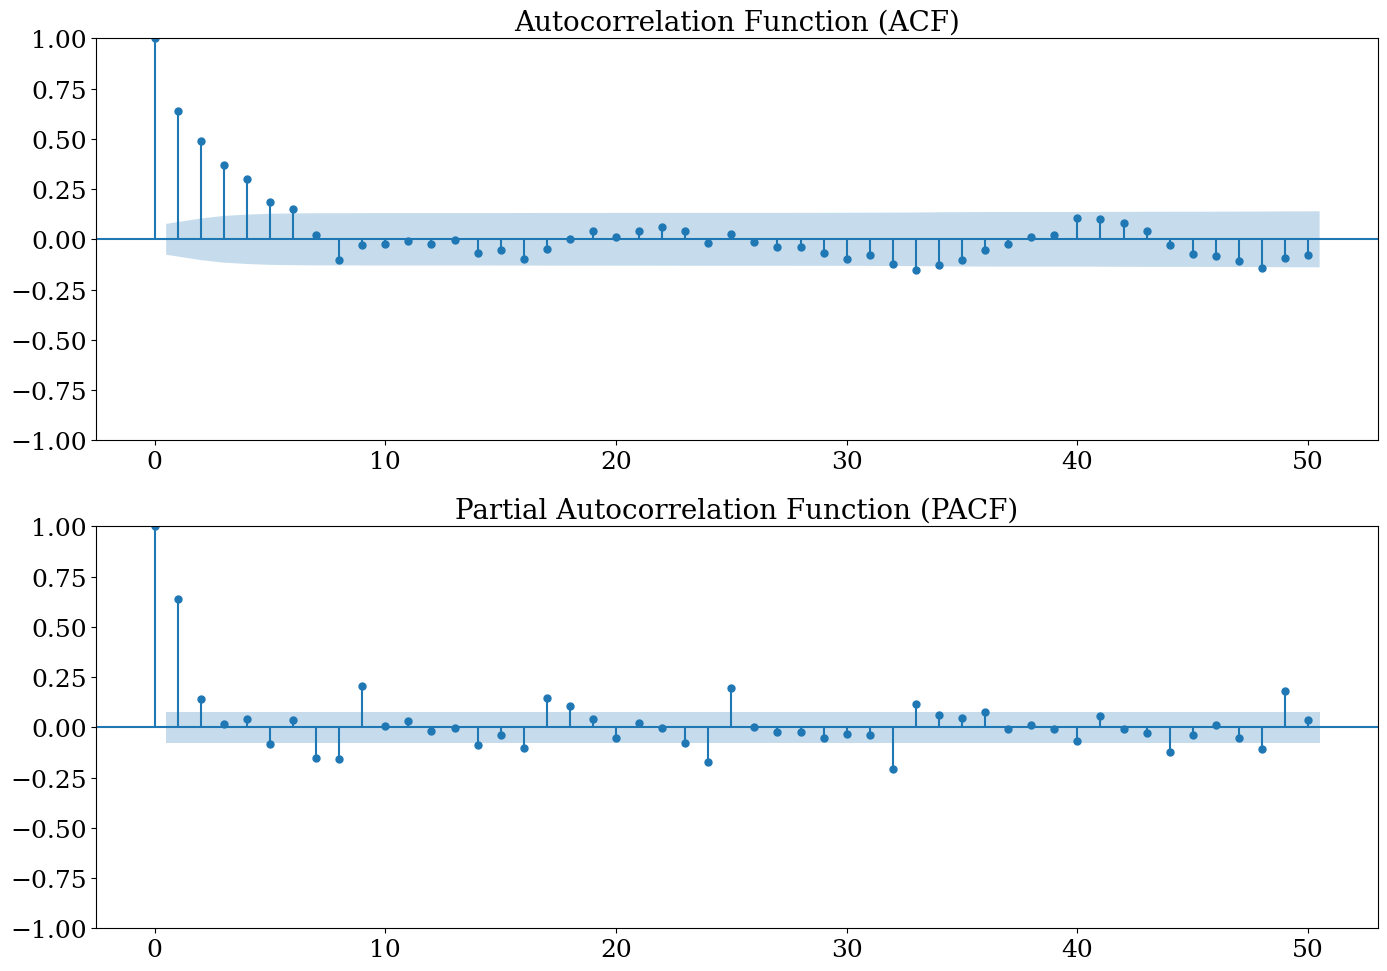

In [50]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot ACF and PACF for the cleaned training data
plt.figure(figsize=(14, 10))

# ACF plot
plt.subplot(2, 1, 1)
plot_acf(train_data['Target'], lags=50, ax=plt.gca())
plt.title("Autocorrelation Function (ACF)")

# PACF plot
plt.subplot(2, 1, 2)
plot_pacf(train_data['Target'], lags=50, ax=plt.gca(), method='ywm')
plt.title("Partial Autocorrelation Function (PACF)")

# Save the figure as an SVG file
plt.savefig("acf_h1.svg", format="svg", dpi=900, bbox_inches='tight', facecolor='white')
plt.tight_layout()
plt.show()

In [113]:
data=datac

# MODEL 1 : NO FEATURE SARIMA

In [114]:
start_time=time.time()

In [115]:
train_data = data[:-4]  # Last 4 rows for testing
test_data = data[-4:]

                                      SARIMAX Results                                      
Dep. Variable:                              Target   No. Observations:                  651
Model:             SARIMAX(2, 0, 0)x(1, 0, [1], 8)   Log Likelihood               -2161.431
Date:                             Sun, 30 Mar 2025   AIC                           4332.863
Time:                                     21:29:11   BIC                           4355.255
Sample:                                          0   HQIC                          4341.548
                                             - 651                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6066      0.034     17.609      0.000       0.539       0.674
ar.L2          0.2922      

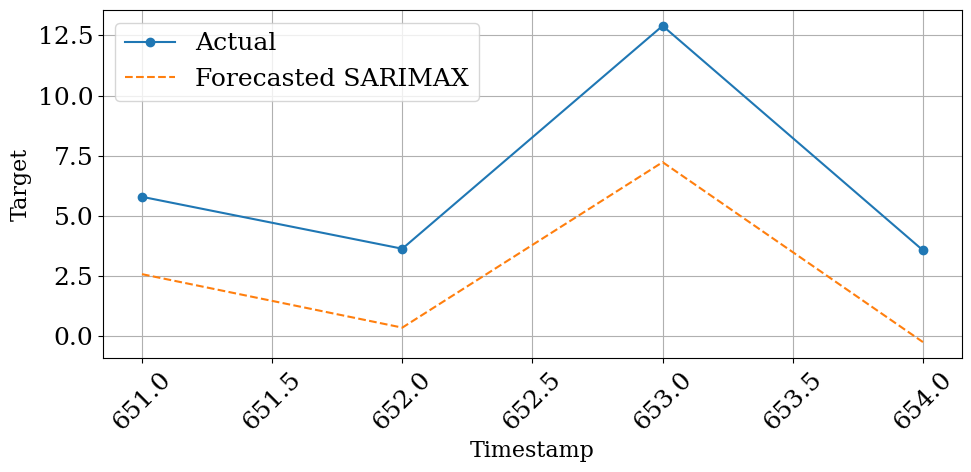

MAE: 3.99, MAPE: 0.74


In [116]:
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt

# Ensure data is sorted
train_data = train_data.sort_index()
test_data = test_data.sort_index()

# Fit SARIMAX model with combined Fourier terms
model = SARIMAX(train_data['Target'], 
                order=(2, 0, 0),  # AR(4) with no differencing
                seasonal_order=(1, 0, 1, 8)
                )  
sarimax_results = model.fit(disp=False)
print(sarimax_results.summary())
# Forecast using combined Fourier terms
sarimax_forecast = sarimax_results.get_forecast(steps=len(test_data)).predicted_mean


# Evaluation metrics
sarimax_mae = mean_absolute_error(test_data['Target'], sarimax_forecast)
sarimax_mape = mean_absolute_percentage_error(test_data['Target'], sarimax_forecast)


# Plot results
plt.figure(figsize=(10, 5))
plt.plot(test_data.index, test_data['Target'], label='Actual', marker='o')
plt.plot(test_data.index, sarimax_forecast, label='Forecasted SARIMAX', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Print evaluation metrics
print(f"MAE: {sarimax_mae:.2f}, MAPE: {sarimax_mape:.2f}")


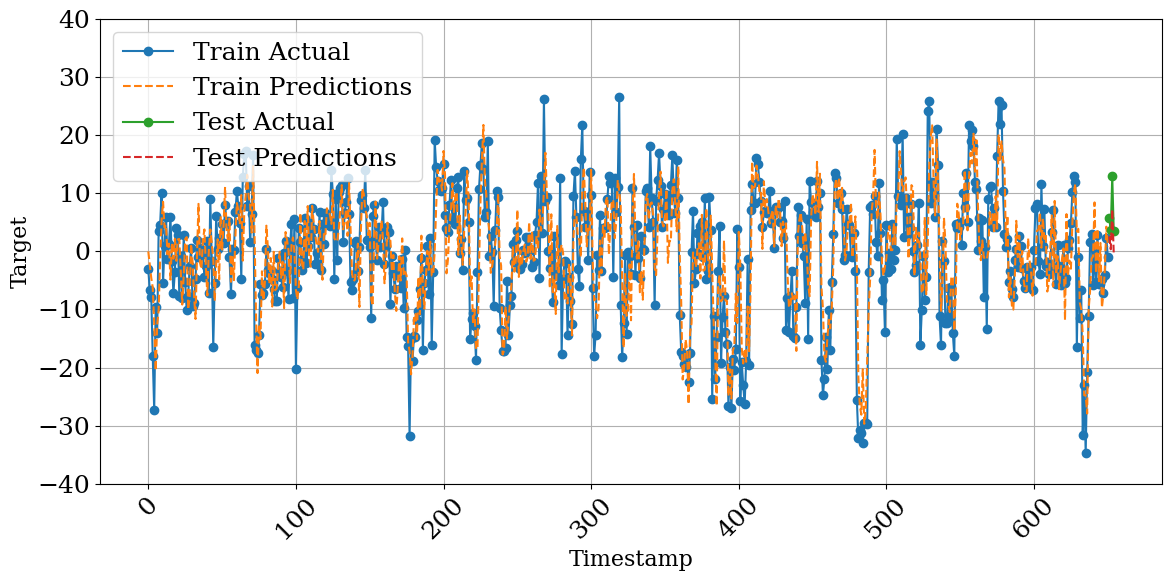

Train MAE: 5.1506
Train MAPE: 5.5528
Test MAE: 3.9912
Test MAPE: 0.7396


In [117]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(2, 0, 0),  # AR(4) with no differencing
                seasonal_order=(1, 0, 1, 8)
                )  
sarimax_results = model.fit(disp=False)

# In-sample predictions for the training set
train_predictions = sarimax_results.predict(start=train_data.index[0], 
                                             end=train_data.index[-1], 
                                      )

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data))
test_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics for the training set
train_mae = mean_absolute_error(train_data['Target'], train_predictions)
train_mape = mean_absolute_percentage_error(train_data['Target'], train_predictions)

# Calculate evaluation metrics for the test set
test_mae = mean_absolute_error(test_data['Target'], test_predictions)
test_mape = mean_absolute_percentage_error(test_data['Target'], test_predictions)

# Plot the results: actual and predictions for both train and test data
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data['Target'], label='Train Actual', marker='o')
plt.plot(train_data.index, train_predictions, label='Train Predictions', linestyle='--')
plt.plot(test_data.index, test_data['Target'], label='Test Actual', marker='o')
plt.plot(test_data.index, test_predictions, label='Test Predictions', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(-40, 40)
plt.show()

# Output the evaluation metrics
print("Train MAE: {:.4f}".format(train_mae))
print("Train MAPE: {:.4f}".format(train_mape))
print("Test MAE: {:.4f}".format(test_mae))
print("Test MAPE: {:.4f}".format(test_mape))


   Combined_Sum
0     50.698207
1     52.498093
2     49.308469
3     49.890251
MAE: 4.15
MAPE: 7.58%


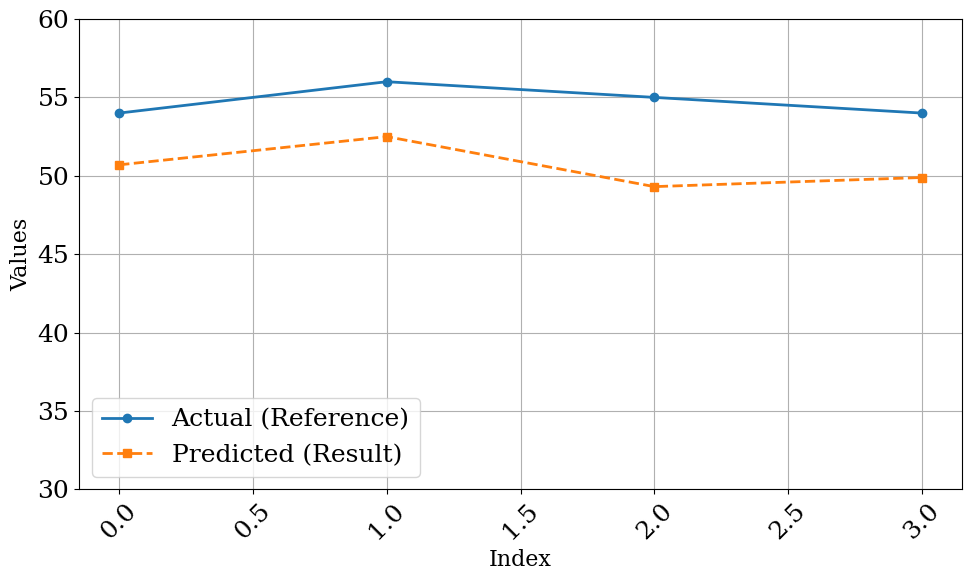

In [118]:
# Convert the DataFrames to NumPy arrays
sarimax_forecast_array = sarimax_forecast.to_numpy().flatten()
summed_up_array = summed_up.to_numpy().flatten()

# Ensure both arrays have the same length
min_length = min(len(sarimax_forecast_array), len(summed_up_array))
sarimax_forecast_array = sarimax_forecast_array[:min_length]
summed_up_array = summed_up_array[:min_length]

# Perform element-wise summation
combined_sum_array = sarimax_forecast_array + summed_up_array

# Convert the result back to a DataFrame (optional)
result_df = pd.DataFrame(combined_sum_array, columns=['Combined_Sum'])

# Print the resulting DataFrame
print(result_df)

# Reset the index of the reference DataFrame
reference = reference.reset_index(drop=True)

# Ensure alignment of lengths
min_length = min(len(result_df), len(reference))
predicted = result_df.iloc[:min_length]['Combined_Sum']
test = reference.iloc[:min_length].squeeze()

# Calculate MAE and MAPE
mae = mean_absolute_error(test, predicted)
mape = mean_absolute_percentage_error(test, predicted)

# Print MAE and MAPE
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2%}")

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(test.index, test, label='Actual (Reference)', marker='o', linestyle='-', linewidth=2)
plt.plot(predicted.index, predicted, label='Predicted (Result)', marker='s', linestyle='--', linewidth=2)
 
plt.xlabel('Index')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(30, 60)
plt.show()



In [119]:
end_time=time.time()

In [120]:
Cost=end_time-start_time

In [121]:
main_results = update_results(main_results, 'SARIMA by DECOMPOSITION W NO FEATURE ', mae, mape,Cost)

In [122]:
main_results

,Model_Name,MAE,MAPE,Cost
0,BASE SARIMA WITHOUT DECOMPOSITION,6.541955,0.119359,18.071575
1,BASE AUTO SARIMA WITHOUT DECOMPOSITION,4.204041,0.076676,40.555002
2,SARIMA by DECOMPOSITION W NO FEATURE,4.151245,0.075817,6.884008


# MODEL 1-1 : NO FEATURE AUTO SARIMA

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[8] intercept   : AIC=4912.165, Time=0.04 sec
 ARIMA(1,0,0)(1,0,0)[8] intercept   : AIC=4539.386, Time=0.87 sec
 ARIMA(0,0,1)(0,0,1)[8] intercept   : AIC=4686.767, Time=0.38 sec
 ARIMA(0,0,0)(0,0,0)[8]             : AIC=4910.931, Time=0.02 sec
 ARIMA(1,0,0)(0,0,0)[8] intercept   : AIC=4576.213, Time=0.07 sec
 ARIMA(1,0,0)(2,0,0)[8] intercept   : AIC=4515.846, Time=3.10 sec
 ARIMA(1,0,0)(2,0,1)[8] intercept   : AIC=inf, Time=2.55 sec
 ARIMA(1,0,0)(1,0,1)[8] intercept   : AIC=inf, Time=1.12 sec
 ARIMA(0,0,0)(2,0,0)[8] intercept   : AIC=4901.280, Time=3.09 sec
 ARIMA(2,0,0)(2,0,0)[8] intercept   : AIC=4489.979, Time=5.62 sec
 ARIMA(2,0,0)(1,0,0)[8] intercept   : AIC=4519.006, Time=0.80 sec
 ARIMA(2,0,0)(2,0,1)[8] intercept   : AIC=inf, Time=2.87 sec
 ARIMA(2,0,0)(1,0,1)[8] intercept   : AIC=inf, Time=2.02 sec
 ARIMA(3,0,0)(2,0,0)[8] intercept   : AIC=4490.091, Time=7.65 sec
 ARIMA(2,0,1)(2,0,0)[8] intercept   : AIC=4488.213, T

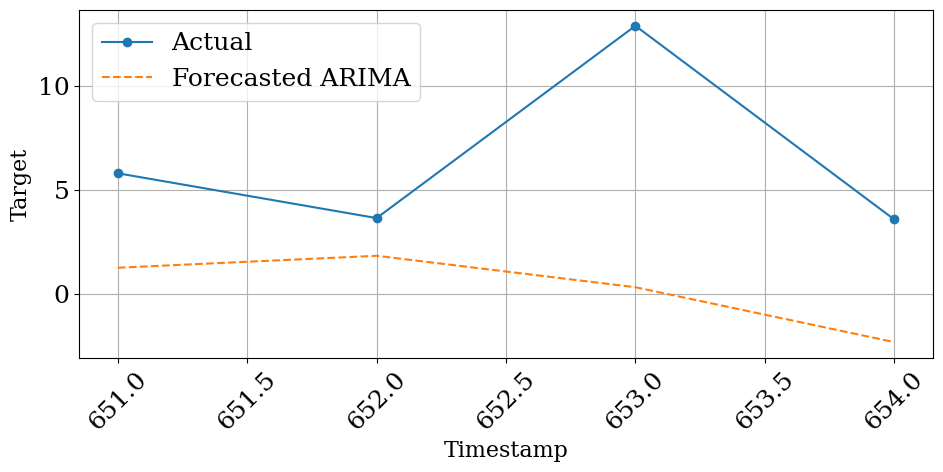

Test MAE: 6.2144
Test MAPE: 0.9774


In [123]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# Fit auto_arima with exogenous variables and seasonal period of 8
stepwise_model = auto_arima(
    y=train_data['Target'],

    seasonal=True,
    m=8,
    start_p=0, start_q=0,
    max_p=5, max_q=5,
    start_P=0, start_Q=0,
    max_P=2, max_Q=2,
    d=None, D=None,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True,
    information_criterion='aic'
)

# Forecast for test period using exogenous variables
n_periods = len(test_data)
sarima_predictions = stepwise_model.predict(n_periods=n_periods)

# Calculate evaluation metrics
sarima_mae = mean_absolute_error(test_data['Target'], sarima_predictions)
sarima_mape = mean_absolute_percentage_error(test_data['Target'], sarima_predictions)

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(test_data.index, test_data['Target'], label='Actual', marker='o')
plt.plot(test_data.index, sarima_predictions, label='Forecasted ARIMA', linestyle='--')

plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Output the MAE and MAPE values
print("Test MAE: {:.4f}".format(sarima_mae))
print("Test MAPE: {:.4f}".format(sarima_mape))


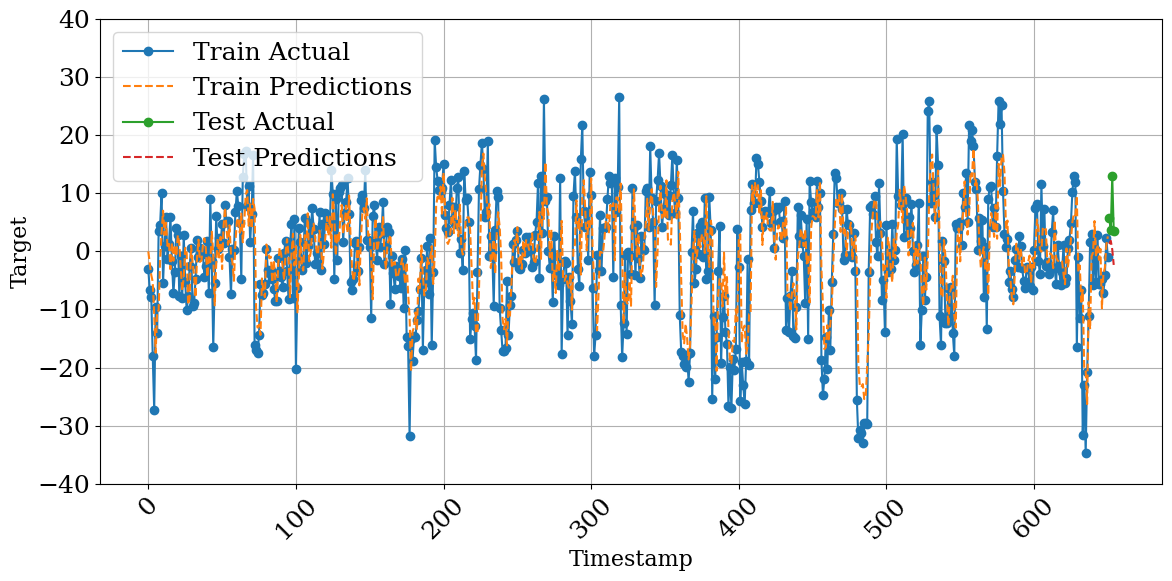

Train MAE: 5.6822
Train MAPE: 3.4137
Test MAE: 6.2144
Test MAPE: 0.9774


In [124]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error


# In-sample predictions for the training set
train_predictions = stepwise_model.predict_in_sample()

# Forecasting the values for the test set duration
test_predictions = stepwise_model.predict(n_periods=len(test_data))

# Calculate evaluation metrics for the training set
train_mae = mean_absolute_error(train_data['Target'], train_predictions)
train_mape = mean_absolute_percentage_error(train_data['Target'], train_predictions)

# Calculate evaluation metrics for the test set
test_mae = mean_absolute_error(test_data['Target'], test_predictions)
test_mape = mean_absolute_percentage_error(test_data['Target'], test_predictions)

# Plot the results: actual and predictions for both train and test data
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data['Target'], label='Train Actual', marker='o')
plt.plot(train_data.index, train_predictions, label='Train Predictions', linestyle='--')
plt.plot(test_data.index, test_data['Target'], label='Test Actual', marker='o')
plt.plot(test_data.index, test_predictions, label='Test Predictions', linestyle='--')

plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(-40, 40)
plt.show()

# Output the evaluation metrics
print("Train MAE: {:.4f}".format(train_mae))
print("Train MAPE: {:.4f}".format(train_mape))
print("Test MAE: {:.4f}".format(test_mae))
print("Test MAPE: {:.4f}".format(test_mape))


   Combined_Sum
0     49.363024
1     53.959449
2     42.383402
3     47.796304
MAE: 6.37
MAPE: 11.66%


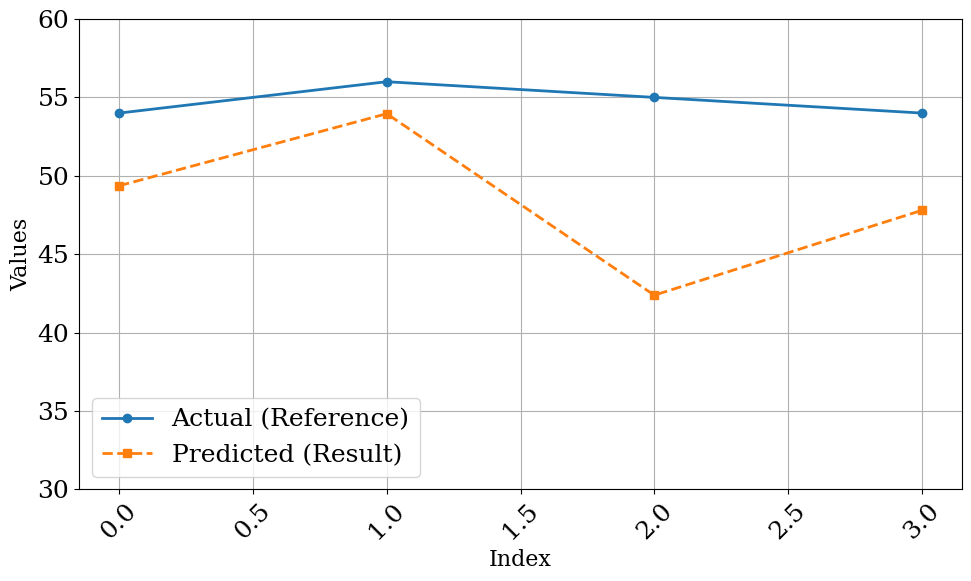

In [125]:
# Convert the DataFrames to NumPy arrays
sarimax_forecast_array = test_predictions.to_numpy().flatten()
summed_up_array = summed_up.to_numpy().flatten()

# Ensure both arrays have the same length
min_length = min(len(sarimax_forecast_array), len(summed_up_array))
sarimax_forecast_array = sarimax_forecast_array[:min_length]
summed_up_array = summed_up_array[:min_length]

# Perform element-wise summation
combined_sum_array = sarimax_forecast_array + summed_up_array

# Convert the result back to a DataFrame (optional)
result_df = pd.DataFrame(combined_sum_array, columns=['Combined_Sum'])

# Print the resulting DataFrame
print(result_df)

# Reset the index of the reference DataFrame
reference = reference.reset_index(drop=True)

# Ensure alignment of lengths
min_length = min(len(result_df), len(reference))
predicted = result_df.iloc[:min_length]['Combined_Sum']
test = reference.iloc[:min_length].squeeze()

# Calculate MAE and MAPE
mae = mean_absolute_error(test, predicted)
mape = mean_absolute_percentage_error(test, predicted)

# Print MAE and MAPE
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2%}")

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(test.index, test, label='Actual (Reference)', marker='o', linestyle='-', linewidth=2)
plt.plot(predicted.index, predicted, label='Predicted (Result)', marker='s', linestyle='--', linewidth=2)
 
plt.xlabel('Index')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(30, 60)
plt.show()

In [126]:
end_time=time.time()

In [127]:
Cost = end_time - start_time

In [128]:
main_results = update_results(main_results, 'AUTO SARIMA BY DECOMPOSITION W NO FEATURE', mae, mape,Cost)

In [129]:
main_results

,Model_Name,MAE,MAPE,Cost
0,BASE SARIMA WITHOUT DECOMPOSITION,6.541955,0.119359,18.071575
1,BASE AUTO SARIMA WITHOUT DECOMPOSITION,4.204041,0.076676,40.555002
2,SARIMA by DECOMPOSITION W NO FEATURE,4.151245,0.075817,6.884008
3,AUTO SARIMA BY DECOMPOSITION W NO FEATURE,6.374455,0.116646,79.508049


### TOPOLOGICAL DATASET

In [130]:
main_results = update_results(main_results, 'Topological Dataset','0' ,'0','0' )

In [131]:
data=datat

# MODEL 2 : SARIMA W ALL FEATURES

In [132]:
start_time=time.time()

In [133]:
train_data = data[:-4]  # Last 4 rows for testing
test_data = data[-4:]

In [134]:
selected_columns_train = train_data.drop(columns=["Target"])
selected_columns_test = test_data.drop(columns=["Target"])

In [135]:
exog_train=selected_columns_train
exog_test=selected_columns_test 

D:\Users\ar600780\AppData\Roaming\Python\Python310\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


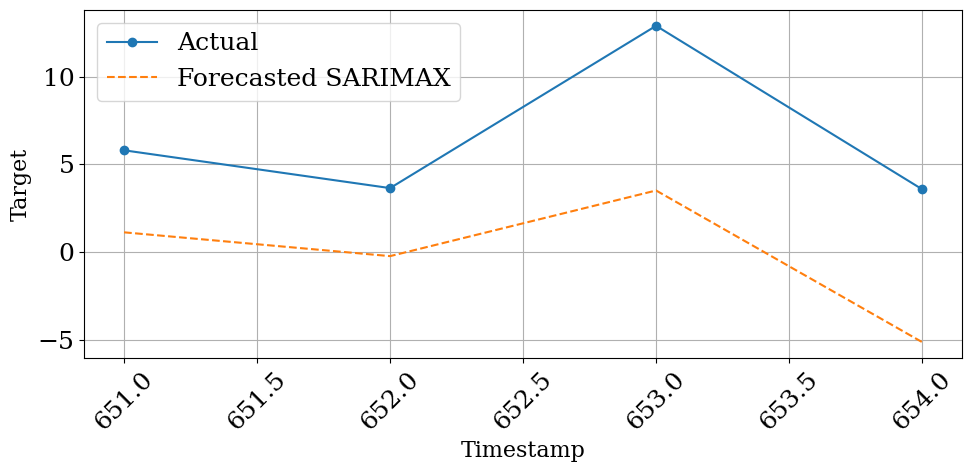

(6.668585881984248, 1.259644253923837)

In [136]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt


# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(2, 0, 0), 
                seasonal_order=(1, 0, 1, 8), 
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
sarima_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics
sarima_mse = mean_absolute_error(test_data['Target'], sarima_predictions)
sarima_mape = mean_absolute_percentage_error(test_data['Target'], sarima_predictions)

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(test_data.index, test_data['Target'], label='Actual', marker='o')
plt.plot(test_data.index, sarima_predictions, label='Forecasted SARIMAX', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Output the MSE and MAPE values
sarima_mse, sarima_mape


D:\Users\ar600780\AppData\Roaming\Python\Python310\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


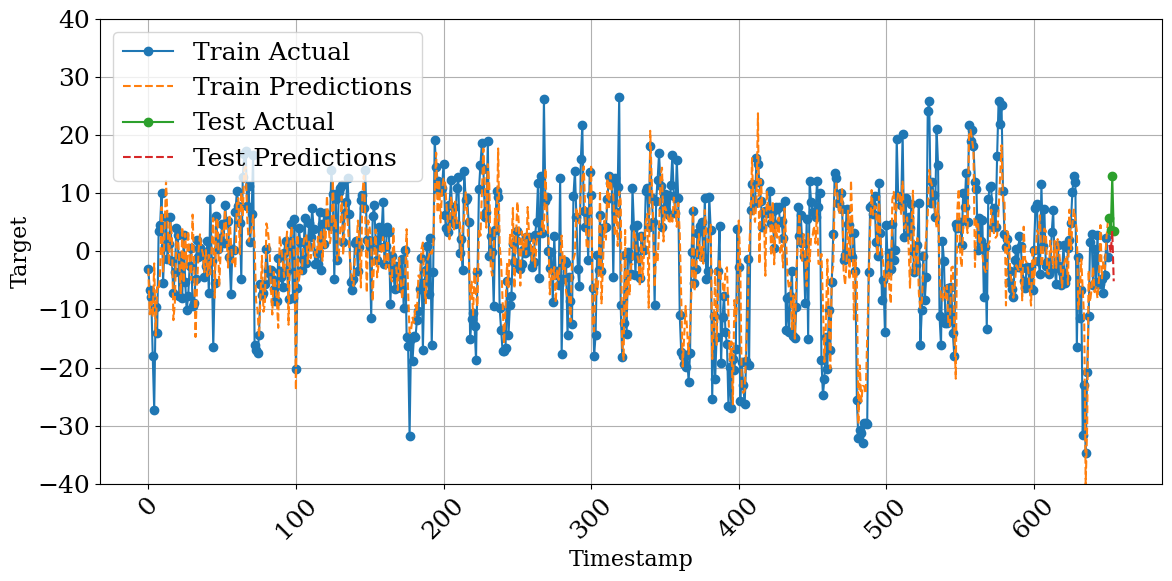

Train MAE: 5.6159
Train MAPE: 5.3481
Test MAE: 6.6686
Test MAPE: 1.2596


In [137]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(2, 0, 0), 
                seasonal_order=(1, 0, 1, 8), 
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# In-sample predictions for the training set
train_predictions = sarimax_results.predict(start=train_data.index[0], 
                                             end=train_data.index[-1], 
                                             exog=exog_train)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
test_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics for the training set
train_mae = mean_absolute_error(train_data['Target'], train_predictions)
train_mape = mean_absolute_percentage_error(train_data['Target'], train_predictions)

# Calculate evaluation metrics for the test set
test_mae = mean_absolute_error(test_data['Target'], test_predictions)
test_mape = mean_absolute_percentage_error(test_data['Target'], test_predictions)

# Plot the results: actual and predictions for both train and test data
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data['Target'], label='Train Actual', marker='o')
plt.plot(train_data.index, train_predictions, label='Train Predictions', linestyle='--')
plt.plot(test_data.index, test_data['Target'], label='Test Actual', marker='o')
plt.plot(test_data.index, test_predictions, label='Test Predictions', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(-40, 40)
plt.show()

# Output the evaluation metrics
print("Train MAE: {:.4f}".format(train_mae))
print("Train MAPE: {:.4f}".format(train_mape))
print("Test MAE: {:.4f}".format(test_mae))
print("Test MAPE: {:.4f}".format(test_mape))


   Combined_Sum
0     49.230887
1     51.894283
2     45.577279
3     44.983029
MAE: 6.83
MAPE: 12.50%


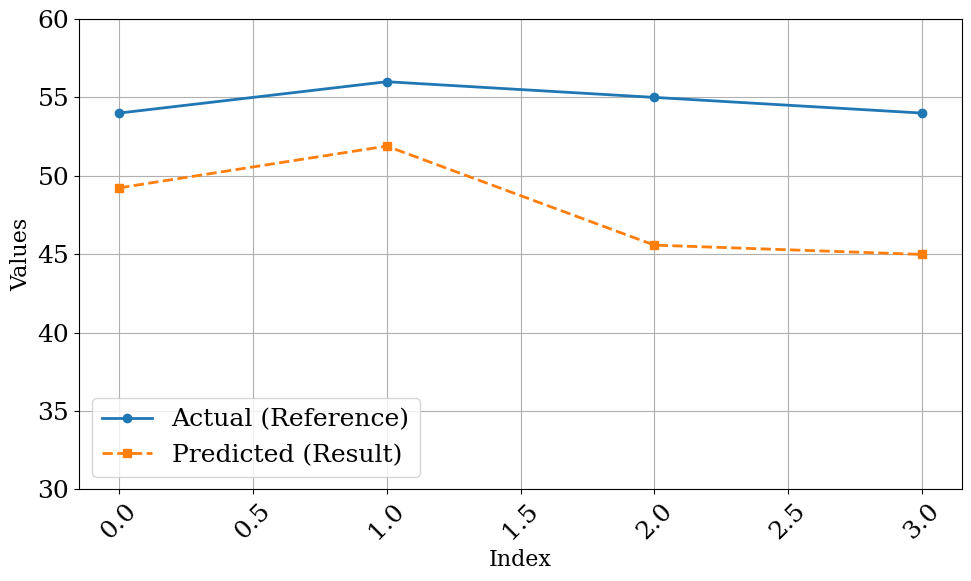

In [138]:
# Convert the DataFrames to NumPy arrays
sarimax_forecast_array = sarima_predictions.to_numpy().flatten()
summed_up_array = summed_up.to_numpy().flatten()

# Ensure both arrays have the same length
min_length = min(len(sarimax_forecast_array), len(summed_up_array))
sarimax_forecast_array = sarimax_forecast_array[:min_length]
summed_up_array = summed_up_array[:min_length]

# Perform element-wise summation
combined_sum_array = sarimax_forecast_array + summed_up_array

# Convert the result back to a DataFrame (optional)
result_df = pd.DataFrame(combined_sum_array, columns=['Combined_Sum'])

# Print the resulting DataFrame
print(result_df)

# Reset the index of the reference DataFrame
reference = reference.reset_index(drop=True)

# Ensure alignment of lengths
min_length = min(len(result_df), len(reference))
predicted = result_df.iloc[:min_length]['Combined_Sum']
test = reference.iloc[:min_length].squeeze()

# Calculate MAE and MAPE
mae = mean_absolute_error(test, predicted)
mape = mean_absolute_percentage_error(test, predicted)

# Print MAE and MAPE
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2%}")

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(test.index, test, label='Actual (Reference)', marker='o', linestyle='-', linewidth=2)
plt.plot(predicted.index, predicted, label='Predicted (Result)', marker='s', linestyle='--', linewidth=2)
 
plt.xlabel('Index')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(30, 60)
plt.show()


In [139]:
end_time=time.time()

In [140]:
Cost = end_time - start_time

In [141]:
main_results = update_results(main_results, 'SARIMA W ALL FEATUREs', mae, mape,Cost)

In [142]:
main_results

,Model_Name,MAE,MAPE,Cost
0,BASE SARIMA WITHOUT DECOMPOSITION,6.541955,0.119359,18.071575
1,BASE AUTO SARIMA WITHOUT DECOMPOSITION,4.204041,0.076676,40.555002
2,SARIMA by DECOMPOSITION W NO FEATURE,4.151245,0.075817,6.884008
3,AUTO SARIMA BY DECOMPOSITION W NO FEATURE,6.374455,0.116646,79.508049
4,Topological Dataset,0,0,0
5,SARIMA W ALL FEATUREs,6.828631,0.124984,80.456107


# MODEL 3-1 : SARIMA W RFE FEATURES

In [143]:
start_time=time.time()

In [144]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.utils import resample
import time
import warnings
import multiprocessing
from joblib import Parallel, delayed

warnings.filterwarnings("ignore")

start_time = time.time()

# Load dataset
df = data  # <-- make sure `data` is defined
target_column = "Target"
exog_columns = [col for col in df.columns if col != target_column]

# Split into training
train_df = df.iloc[:-4]
X_train = train_df[exog_columns]
y_train = train_df[target_column]

# SARIMAX p-value extractor
def get_p_values(X, y):
    try:
        model = SARIMAX(y, 
                        order=(2, 0, 0), 
                        seasonal_order=(1, 0, 1, 8), 
                        exog=X)
        result = model.fit(disp=False)
        return result.pvalues.loc[X.columns]
    except Exception as e:
        print("SARIMAX fit error:", e)
        return pd.Series([1.0] * X.shape[1], index=X.columns)

# Model AIC calculator
def compute_aic(feature_set):
    try:
        model = SARIMAX(y_train, 
                        order=(2, 0, 0), 
                        seasonal_order=(1, 0, 1, 8), 
                        exog=X_train[list(feature_set)])
        result = model.fit(disp=False)
        return (feature_set, result.aic)
    except:
        return (feature_set, np.inf)

# RFE parameters
selected_features = exog_columns.copy()
step2 = 5

# RFE Loop
while True:
    p_values = get_p_values(X_train[selected_features], y_train)

    # Features with p > 0.05
    worst_candidates = p_values[p_values > 0.05]

    # Stopping criterion
    if len(worst_candidates) < step2:
        print(f"Stopping early: Only {len(worst_candidates)} features have p > 0.05.")
        break

    # Dynamic step size
    step = min(20, len(worst_candidates), len(selected_features) // 2)

    # Worst features sorted by p-value
    worst_features = worst_candidates.sort_values(ascending=False).head(step).index

    for feature in worst_features:
        if feature in selected_features:
            selected_features.remove(feature)
            print(f"Removed Feature: {feature}, p-value: {p_values[feature]}")

print("\nInitial RFE Completed.")
print(f"Remaining Features: {len(selected_features)}")

# Optional: Stability Check via Bootstrapping
print("\nRunning stability check (bootstrap p-values)...")
bootstrap_rounds = 10
stable_features = []

boot_results = []
for i in range(bootstrap_rounds):
    X_res, y_res = resample(X_train[selected_features], y_train)
    p_vals = get_p_values(X_res, y_res)
    significant = set(p_vals[p_vals < 0.05].index)
    boot_results.append(significant)

stable_features = list(set.intersection(*boot_results))
print(f"\nStable Features Across {bootstrap_rounds} Bootstraps: {len(stable_features)}")

# Optional: AIC comparison for final selection
print("\nEvaluating AIC on stable subsets...")
feature_sets = [stable_features, selected_features]  # Compare both
num_cores = multiprocessing.cpu_count()

aic_values = Parallel(n_jobs=num_cores)(
    delayed(compute_aic)(f_set) for f_set in feature_sets
)

best_features, best_aic = sorted(aic_values, key=lambda x: x[1])[0]
print(f"\nBest AIC: {best_aic}")
print("Selected Final Features:", best_features)


Removed Feature: L2_H1, p-value: 0.986802440604932
Removed Feature: Col88_L1_H1, p-value: 0.9850085982901788
Removed Feature: Col99_L2_H1, p-value: 0.9731460503395445
Removed Feature: Col29_L1_H0, p-value: 0.9706305321954949
Removed Feature: Col98_L2_H1, p-value: 0.9705801954785852
Removed Feature: Col32_L1_H0, p-value: 0.9669977465557088
Removed Feature: silhouette_features_L1_H0_SI, p-value: 0.9663514076551641
Removed Feature: Col80_L1_H0, p-value: 0.9355277633140529
Removed Feature: Col77_L2_H1, p-value: 0.9272569386812906
Removed Feature: Col68_L2_H1, p-value: 0.9234152155566675
Removed Feature: Col64_L1_H1, p-value: 0.9229092996300976
Removed Feature: Col25_L2_H1, p-value: 0.9058614593014835
Removed Feature: Col8_L1_H0, p-value: 0.8918519347302991
Removed Feature: Col60_L2_H1, p-value: 0.8684812242417558
Removed Feature: Col79_L1_H0, p-value: 0.8659167636764982
Removed Feature: Col95_L2_H1, p-value: 0.8610626349887555
Removed Feature: Col63_L1_H1, p-value: 0.8568717915919346
Remov

In [145]:
columns_to_keep = selected_features.copy()  # Make a copy of your list
if 'Target' not in columns_to_keep:
    columns_to_keep.append('Target')

data_rfe = data[columns_to_keep]

In [146]:
data_rfe

,Col34_L2_H0,Col35_L2_H0,Col39_L1_H0,Col44_L2_H0,Col45_L2_H0,Col48_L2_H0,Col52_L1_H0,Col72_L2_H0,Target
0,0.234776,0.253082,0.298746,0.337135,0.314320,0.183440,0.065409,0.000000,-3.075369
1,0.361257,0.381637,0.340172,0.161016,0.119818,0.033789,0.004339,0.000000,-6.716898
2,0.479778,0.524165,0.547128,0.333831,0.263200,0.089354,0.015044,0.000000,-7.802650
3,0.482436,0.525782,0.547276,0.333831,0.263200,0.089354,0.015044,0.000000,-18.026339
4,0.581058,0.640407,0.725001,0.523771,0.429126,0.164053,0.032401,0.000000,-27.334787
...,...,...,...,...,...,...,...,...,...
650,0.430858,0.393743,0.292882,0.235350,0.212045,0.158584,0.266938,0.403847,-0.982344
651,0.567921,0.472935,0.239401,0.300537,0.309615,0.243242,0.130062,0.399363,5.799075
652,0.551265,0.447262,0.140127,0.018520,0.010708,0.001761,0.006170,0.399363,3.641816
653,0.551322,0.447262,0.140127,0.018520,0.010708,0.001371,0.000000,0.000000,12.900423


In [147]:
train_data = data_rfe[:-4]  # Last 4 rows for testing
test_data = data_rfe[-4:]

In [148]:
selected_columns_train = train_data.drop(columns=["Target"])
selected_columns_test = test_data.drop(columns=["Target"])

In [149]:
exog_train=selected_columns_train
exog_test=selected_columns_test 

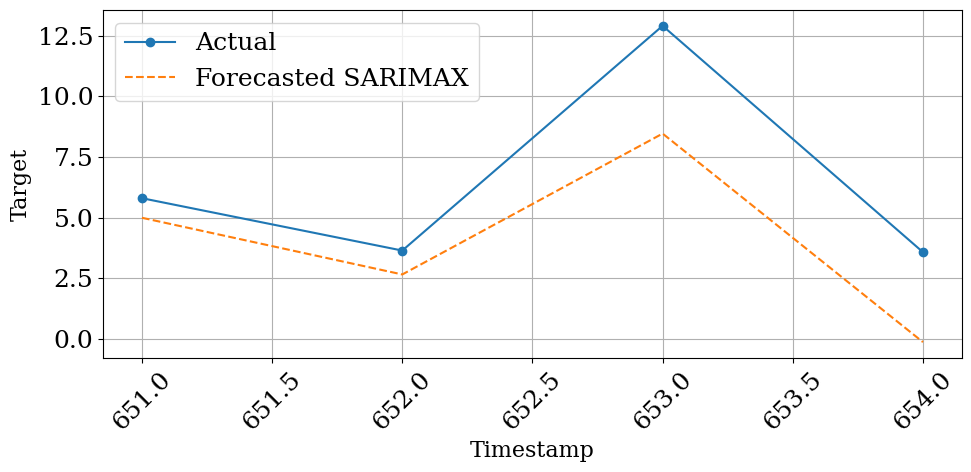

(2.483702957322883, 0.44730465699566746)

In [150]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt


# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(2, 0, 0), 
                seasonal_order=(1, 0, 1, 8), 
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
sarima_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics
sarima_mse = mean_absolute_error(test_data['Target'], sarima_predictions)
sarima_mape = mean_absolute_percentage_error(test_data['Target'], sarima_predictions)

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(test_data.index, test_data['Target'], label='Actual', marker='o')
plt.plot(test_data.index, sarima_predictions, label='Forecasted SARIMAX', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Output the MSE and MAPE values
sarima_mse, sarima_mape


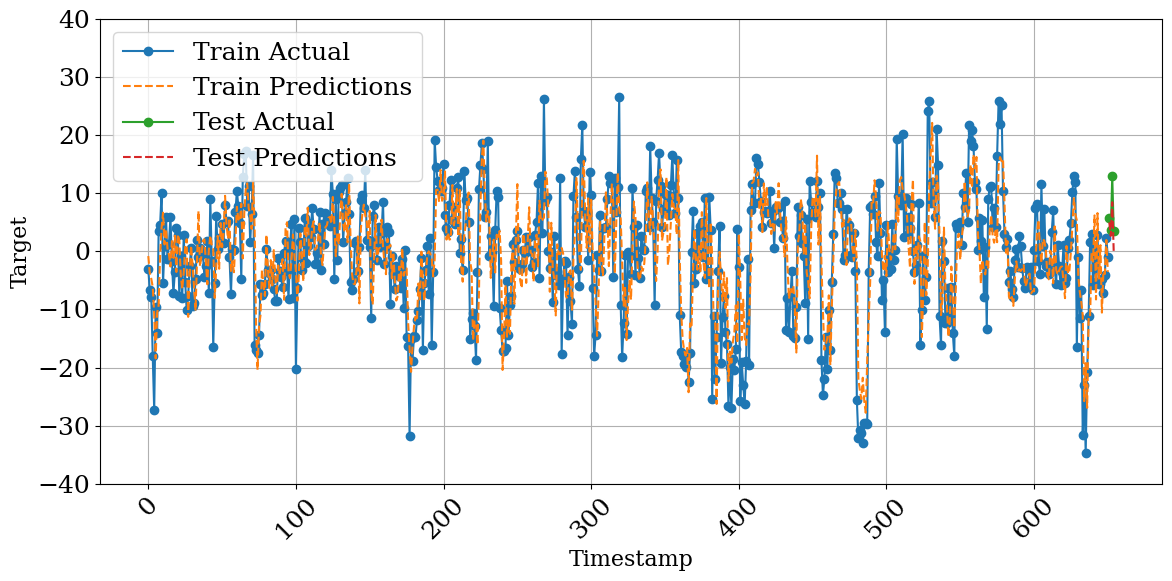

Train MAE: 5.5443
Train MAPE: 5.9500
Test MAE: 2.4837
Test MAPE: 0.4473


In [151]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(2, 0, 0), 
                seasonal_order=(1, 0, 1, 8), 
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# In-sample predictions for the training set
train_predictions = sarimax_results.predict(start=train_data.index[0], 
                                             end=train_data.index[-1], 
                                             exog=exog_train)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
test_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics for the training set
train_mae = mean_absolute_error(train_data['Target'], train_predictions)
train_mape = mean_absolute_percentage_error(train_data['Target'], train_predictions)

# Calculate evaluation metrics for the test set
test_mae = mean_absolute_error(test_data['Target'], test_predictions)
test_mape = mean_absolute_percentage_error(test_data['Target'], test_predictions)

# Plot the results: actual and predictions for both train and test data
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data['Target'], label='Train Actual', marker='o')
plt.plot(train_data.index, train_predictions, label='Train Predictions', linestyle='--')
plt.plot(test_data.index, test_data['Target'], label='Test Actual', marker='o')
plt.plot(test_data.index, test_predictions, label='Test Predictions', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(-40, 40)
plt.show()

# Output the evaluation metrics
print("Train MAE: {:.4f}".format(train_mae))
print("Train MAPE: {:.4f}".format(train_mape))
print("Test MAE: {:.4f}".format(test_mae))
print("Test MAPE: {:.4f}".format(test_mape))


   Combined_Sum
0     53.104911
1     54.790579
2     50.532094
3     49.997425
MAE: 2.64
MAPE: 4.84%


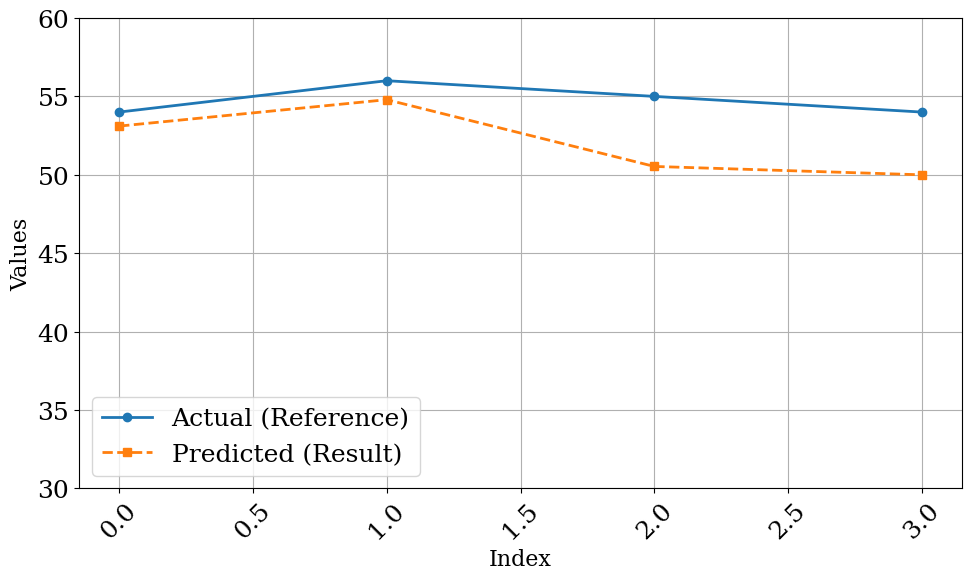

In [152]:
# Convert the DataFrames to NumPy arrays
sarimax_forecast_array = sarima_predictions.to_numpy().flatten()
summed_up_array = summed_up.to_numpy().flatten()

# Ensure both arrays have the same length
min_length = min(len(sarimax_forecast_array), len(summed_up_array))
sarimax_forecast_array = sarimax_forecast_array[:min_length]
summed_up_array = summed_up_array[:min_length]

# Perform element-wise summation
combined_sum_array = sarimax_forecast_array + summed_up_array

# Convert the result back to a DataFrame (optional)
result_df = pd.DataFrame(combined_sum_array, columns=['Combined_Sum'])

# Print the resulting DataFrame
print(result_df)

# Reset the index of the reference DataFrame
reference = reference.reset_index(drop=True)

# Ensure alignment of lengths
min_length = min(len(result_df), len(reference))
predicted = result_df.iloc[:min_length]['Combined_Sum']
test = reference.iloc[:min_length].squeeze()

# Calculate MAE and MAPE
mae = mean_absolute_error(test, predicted)
mape = mean_absolute_percentage_error(test, predicted)

# Print MAE and MAPE
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2%}")

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(test.index, test, label='Actual (Reference)', marker='o', linestyle='-', linewidth=2)
plt.plot(predicted.index, predicted, label='Predicted (Result)', marker='s', linestyle='--', linewidth=2)
 
plt.xlabel('Index')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(30, 60)
plt.show()


In [153]:
end_time=time.time()

In [154]:
Cost = end_time - start_time

In [155]:
main_results = update_results(main_results, 'SARIMA W RFE FEATUREs', mae, mape,Cost)

In [156]:
main_results

,Model_Name,MAE,MAPE,Cost
0,BASE SARIMA WITHOUT DECOMPOSITION,6.541955,0.119359,18.071575
1,BASE AUTO SARIMA WITHOUT DECOMPOSITION,4.204041,0.076676,40.555002
2,SARIMA by DECOMPOSITION W NO FEATURE,4.151245,0.075817,6.884008
3,AUTO SARIMA BY DECOMPOSITION W NO FEATURE,6.374455,0.116646,79.508049
4,Topological Dataset,0,0,0
5,SARIMA W ALL FEATUREs,6.828631,0.124984,80.456107
6,SARIMA W RFE FEATUREs,2.643748,0.048382,251.586817


# MODEL 4 : SARIMA W RFE + PSO FEATURES

In [157]:
import numpy as np 
import pandas as pd
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pyswarm import pso  # Particle Swarm Optimization
from functools import lru_cache
from collections import Counter
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
start_time=time.time()
# Suppress warnings
warnings.filterwarnings("ignore")

# ============================
# Data Preparation
# ============================

target_column = 'Target'  # Replace with actual target column
train_data = data_rfe[:-4]  # Use all but the last 4 rows for training

selected_columns_train = train_data.drop(columns=[target_column])  # Features only
exog_train = selected_columns_train.values

num_features = selected_columns_train.shape[1]  # Number of features

# ============================
# Caching for Faster Execution
# ============================

solution_cache = {}

@lru_cache(maxsize=1000)
def evaluate_solution(solution_key):
    """
    Evaluates SARIMAX performance for a given feature subset using negative BIC.
    """
    selected_features = np.array(solution_key, dtype=bool)
    
    # Penalize solutions that select no features
    if not np.any(selected_features):
        return 1e6  

    exog_selected = exog_train[:, selected_features]

    try:
        model = SARIMAX(train_data[target_column],
                        order=(2, 0, 0),
                        seasonal_order=(1, 0, 1, 8),
                        exog=exog_selected,
                        enforce_stationarity=False,
                        enforce_invertibility=False)
        results = model.fit(disp=0, maxiter=30)  # Lower maxiter for speed
        return results.bic  # Minimize BIC
    except:
        return 1e6  # Strong penalty for errors

# ============================
# Define PSO Objective Function
# ============================

def pso_objective_function(solution):
    """
    Evaluates the fitness of a feature subset for PSO.
    """
    key = tuple(np.round(solution).astype(int))  # Convert to binary feature selection
    
    if key in solution_cache:
        return solution_cache[key]

    # Evaluate solution
    fitness_val = evaluate_solution(key)
    solution_cache[key] = fitness_val  # Store in cache
    return fitness_val

# ============================
# PSO Execution
# ============================

lb = [0] * num_features  # Lower bounds (0 = feature not selected)
ub = [1] * num_features  # Upper bounds (1 = feature selected)

selected_features_runs = []
best_results = []
num_columns = data_rfe.shape[1]-1
for run in range(5):
    print(f"Starting PSO optimization, run {run+1}...")

    best_solution, best_bic = best_solution, best_bic = pso(
    pso_objective_function, 
    lb, 
    ub, 
    swarmsize=40, 
    maxiter=100, 
    omega=0.7,  # Inertia weight
    phip=1.4,   # Cognitive parameter (similar to c1)
    phig=1.8,   # Social parameter (similar to c2)
    debug=False
)


    # Convert solution to selected feature names
    selected_features_mask = np.round(best_solution).astype(int).astype(bool)
    selected_features_pso = selected_columns_train.columns[selected_features_mask].tolist()
    selected_features_runs.append(selected_features_pso)

    # Fit final model with selected features
    exog_train_final = exog_train[:, selected_features_mask]


    final_model = SARIMAX(train_data[target_column],
                          order=(2, 0, 0),
                          seasonal_order=(1, 0, 1, 8),
                          exog=exog_train_final)
    final_results = final_model.fit(disp=False)
    


    # Save best results
    best_results.append({
        "Run": run + 1,
        "BIC": best_bic,
        "Selected Features": selected_features_pso
    })

# Convert to DataFrame
results_df = pd.DataFrame(best_results)

# Identify the best run (minimum BIC)
best_run = results_df.loc[results_df[['BIC']].sum(axis=1).idxmin()]
best_run_features = best_run["Selected Features"]

# Find the most frequently chosen features (chosen in at least 3 runs)
feature_counts = Counter(feature for run_features in selected_features_runs for feature in run_features)
final_feature_selection = list(feature_counts.keys())

# If final_feature_selection is empty, assign it to best_run_features
if not final_feature_selection:
    final_feature_selection = best_run_features

# Save best run features and final feature selection in separate lists
best_run_feature_list = list(best_run_features)
final_feature_selection_list = list(final_feature_selection)

# ============================
# Display Results
# ============================

print("\nPSO Runs Results:")
print(results_df)

print("\nBest Run Summary:")
print(best_run)

print("\nFinal Feature Selection (Chosen in at least 3 runs or from best run if empty):")
print(final_feature_selection_list)

print("\nBest Run Features List:")
print(best_run_feature_list)

# ============================
# Save Results
# ============================

# Convert to DataFrame for easy export if needed
best_run_summary_df = pd.DataFrame([best_run])
final_features_df = pd.DataFrame({"Most Chosen Features": final_feature_selection_list})


Starting PSO optimization, run 1...
Stopping search: maximum iterations reached --> 100
Starting PSO optimization, run 2...
Stopping search: maximum iterations reached --> 100
Starting PSO optimization, run 3...
Stopping search: maximum iterations reached --> 100
Starting PSO optimization, run 4...
Stopping search: maximum iterations reached --> 100
Starting PSO optimization, run 5...
Stopping search: maximum iterations reached --> 100

PSO Runs Results:
   Run          BIC Selected Features
0    1  4298.207424     [Col39_L1_H0]
1    2  4298.207424     [Col39_L1_H0]
2    3  4298.207424     [Col39_L1_H0]
3    4  4298.207424     [Col39_L1_H0]
4    5  4298.244646     [Col34_L2_H0]

Best Run Summary:
Run                              1
BIC                    4298.207424
Selected Features    [Col39_L1_H0]
Name: 0, dtype: object

Final Feature Selection (Chosen in at least 3 runs or from best run if empty):
['Col39_L1_H0', 'Col34_L2_H0']

Best Run Features List:
['Col39_L1_H0']


In [158]:
# Save best run features and final feature selection in separate lists
best_run_feature_list = list(best_run_features)
final_feature_selection_list = list(final_feature_selection)

In [159]:
# Convert selected_features_pso to a standard Python list
selected_features_pso = best_run_feature_list

# Add 'Target' to the selected features list
selected_features_pso.append('Target')

In [160]:
data_pso=data_rfe[selected_features_pso]

In [161]:
# Convert selected_features_pso to a standard Python list
selected_features_pso = final_feature_selection_list

# Add 'Target' to the selected features list
selected_features_pso.append('Target')

In [162]:
data_pso_best=data_rfe[selected_features_pso]

In [163]:
train_data = data_pso[:-4]  # Last 4 rows for testing
test_data = data_pso[-4:]

In [164]:
selected_columns_train = train_data.drop(columns=["Target"])
selected_columns_test = test_data.drop(columns=["Target"])

In [165]:
exog_train=selected_columns_train
exog_test=selected_columns_test 

In [166]:
start_time=time.time()

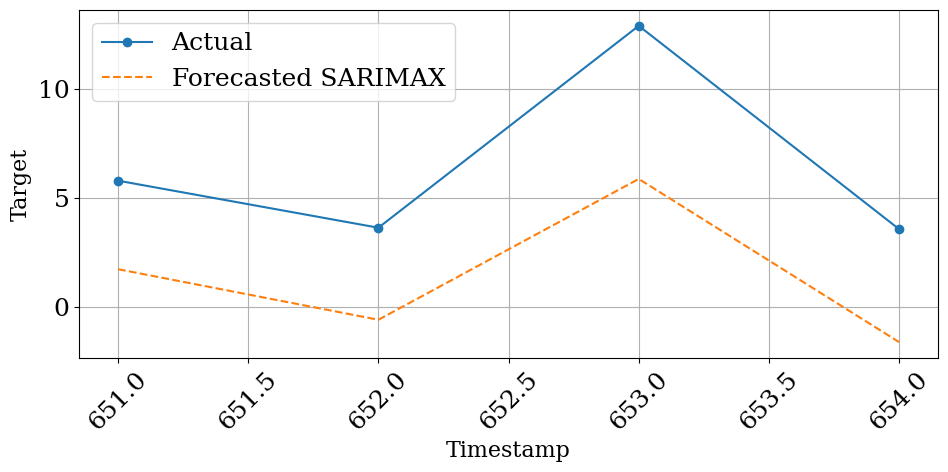

(5.119690662803558, 0.9627037621898513)

In [167]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt


# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(2, 0, 0), 
                seasonal_order=(1, 0, 1, 8), 
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
sarima_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics
sarima_mse = mean_absolute_error(test_data['Target'], sarima_predictions)
sarima_mape = mean_absolute_percentage_error(test_data['Target'], sarima_predictions)

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(test_data.index, test_data['Target'], label='Actual', marker='o')
plt.plot(test_data.index, sarima_predictions, label='Forecasted SARIMAX', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Output the MSE and MAPE values
sarima_mse, sarima_mape


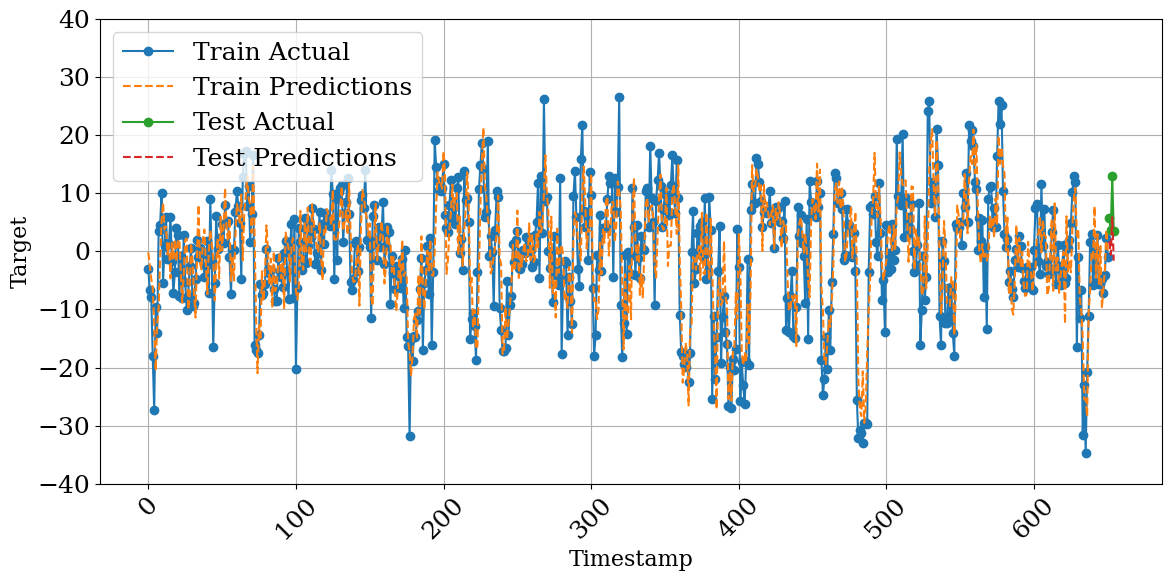

Train MAE: 5.1277
Train MAPE: 5.5934
Test MAE: 5.1197
Test MAPE: 0.9627


In [168]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(2, 0, 0), 
                seasonal_order=(1, 0, 1, 8), 
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# In-sample predictions for the training set
train_predictions = sarimax_results.predict(start=train_data.index[0], 
                                             end=train_data.index[-1], 
                                             exog=exog_train)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
test_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics for the training set
train_mae = mean_absolute_error(train_data['Target'], train_predictions)
train_mape = mean_absolute_percentage_error(train_data['Target'], train_predictions)

# Calculate evaluation metrics for the test set
test_mae = mean_absolute_error(test_data['Target'], test_predictions)
test_mape = mean_absolute_percentage_error(test_data['Target'], test_predictions)

# Plot the results: actual and predictions for both train and test data
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data['Target'], label='Train Actual', marker='o')
plt.plot(train_data.index, train_predictions, label='Train Predictions', linestyle='--')
plt.plot(test_data.index, test_data['Target'], label='Test Actual', marker='o')
plt.plot(test_data.index, test_predictions, label='Test Predictions', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(-40, 40)
plt.show()

# Output the evaluation metrics
print("Train MAE: {:.4f}".format(train_mae))
print("Train MAPE: {:.4f}".format(train_mape))
print("Test MAE: {:.4f}".format(test_mae))
print("Test MAPE: {:.4f}".format(test_mape))


   Combined_Sum
0     49.851748
1     51.554968
2     47.950739
3     48.523603
MAE: 5.28
MAPE: 9.64%


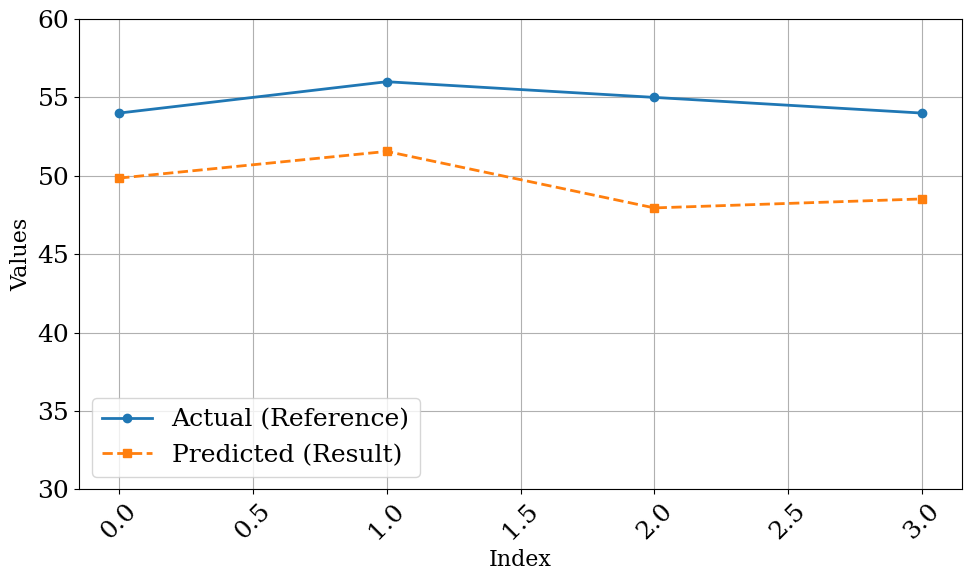

In [169]:
# Convert the DataFrames to NumPy arrays
sarimax_forecast_array = sarima_predictions.to_numpy().flatten()
summed_up_array = summed_up.to_numpy().flatten()

# Ensure both arrays have the same length
min_length = min(len(sarimax_forecast_array), len(summed_up_array))
sarimax_forecast_array = sarimax_forecast_array[:min_length]
summed_up_array = summed_up_array[:min_length]

# Perform element-wise summation
combined_sum_array = sarimax_forecast_array + summed_up_array

# Convert the result back to a DataFrame (optional)
result_df = pd.DataFrame(combined_sum_array, columns=['Combined_Sum'])

# Print the resulting DataFrame
print(result_df)

# Reset the index of the reference DataFrame
reference = reference.reset_index(drop=True)

# Ensure alignment of lengths
min_length = min(len(result_df), len(reference))
predicted = result_df.iloc[:min_length]['Combined_Sum']
test = reference.iloc[:min_length].squeeze()

# Calculate MAE and MAPE
mae = mean_absolute_error(test, predicted)
mape = mean_absolute_percentage_error(test, predicted)

# Print MAE and MAPE
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2%}")

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(test.index, test, label='Actual (Reference)', marker='o', linestyle='-', linewidth=2)
plt.plot(predicted.index, predicted, label='Predicted (Result)', marker='s', linestyle='--', linewidth=2)
 
plt.xlabel('Index')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(30, 60)
plt.show()


In [170]:
end_time=time.time()

In [171]:
Cost = end_time - start_time

In [172]:
main_results = update_results(main_results, 'SARIMA W RFE + PSO FEATUREs', mae, mape,Cost)

In [173]:
main_results

,Model_Name,MAE,MAPE,Cost
0,BASE SARIMA WITHOUT DECOMPOSITION,6.541955,0.119359,18.071575
1,BASE AUTO SARIMA WITHOUT DECOMPOSITION,4.204041,0.076676,40.555002
2,SARIMA by DECOMPOSITION W NO FEATURE,4.151245,0.075817,6.884008
3,AUTO SARIMA BY DECOMPOSITION W NO FEATURE,6.374455,0.116646,79.508049
4,Topological Dataset,0,0,0
5,SARIMA W ALL FEATUREs,6.828631,0.124984,80.456107
6,SARIMA W RFE FEATUREs,2.643748,0.048382,251.586817
7,SARIMA W RFE + PSO FEATUREs,5.279735,0.096445,5.185002


# MODEL 4 - 1: SARIMA W RFE+PSO BEST FEATURE SELECTION

In [174]:
start_time=time.time()

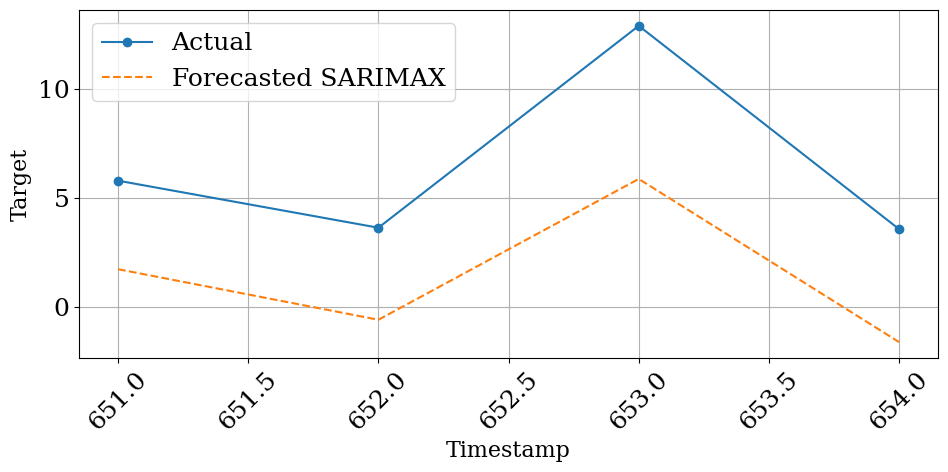

(5.119690662803558, 0.9627037621898513)

In [175]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt


# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(2, 0, 0), 
                seasonal_order=(1, 0, 1, 8), 
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
sarima_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics
sarima_mse = mean_absolute_error(test_data['Target'], sarima_predictions)
sarima_mape = mean_absolute_percentage_error(test_data['Target'], sarima_predictions)

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(test_data.index, test_data['Target'], label='Actual', marker='o')
plt.plot(test_data.index, sarima_predictions, label='Forecasted SARIMAX', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Output the MSE and MAPE values
sarima_mse, sarima_mape


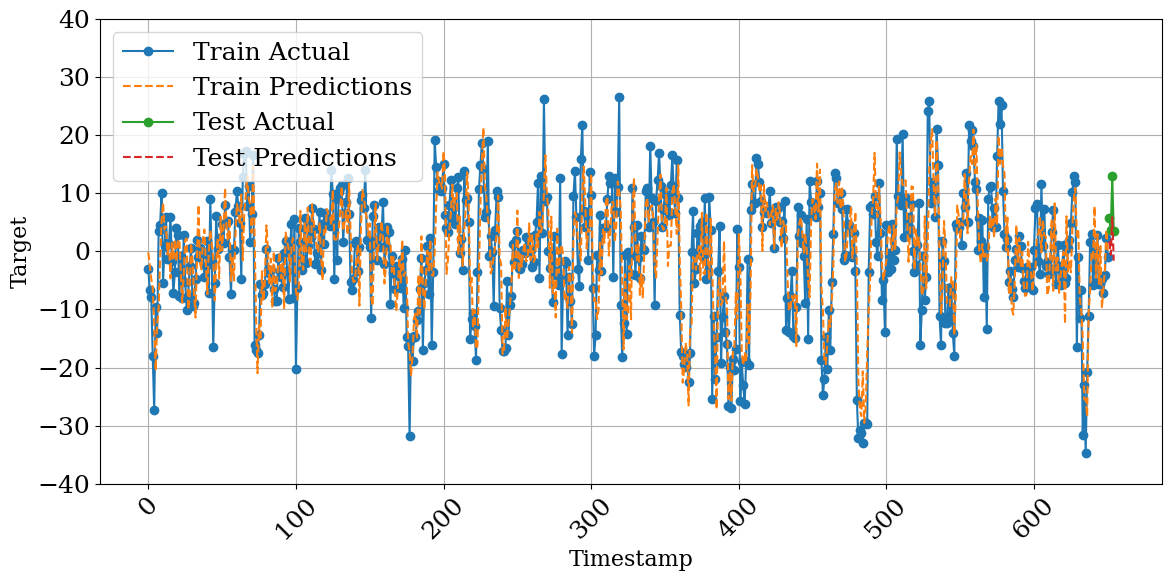

Train MAE: 5.1277
Train MAPE: 5.5934
Test MAE: 5.1197
Test MAPE: 0.9627


In [176]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(2, 0, 0), 
                seasonal_order=(1, 0, 1, 8), 
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# In-sample predictions for the training set
train_predictions = sarimax_results.predict(start=train_data.index[0], 
                                             end=train_data.index[-1], 
                                             exog=exog_train)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
test_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics for the training set
train_mae = mean_absolute_error(train_data['Target'], train_predictions)
train_mape = mean_absolute_percentage_error(train_data['Target'], train_predictions)

# Calculate evaluation metrics for the test set
test_mae = mean_absolute_error(test_data['Target'], test_predictions)
test_mape = mean_absolute_percentage_error(test_data['Target'], test_predictions)

# Plot the results: actual and predictions for both train and test data
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data['Target'], label='Train Actual', marker='o')
plt.plot(train_data.index, train_predictions, label='Train Predictions', linestyle='--')
plt.plot(test_data.index, test_data['Target'], label='Test Actual', marker='o')
plt.plot(test_data.index, test_predictions, label='Test Predictions', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(-40, 40)
plt.show()

# Output the evaluation metrics
print("Train MAE: {:.4f}".format(train_mae))
print("Train MAPE: {:.4f}".format(train_mape))
print("Test MAE: {:.4f}".format(test_mae))
print("Test MAPE: {:.4f}".format(test_mape))


   Combined_Sum
0     49.851748
1     51.554968
2     47.950739
3     48.523603
MAE: 5.28
MAPE: 9.64%


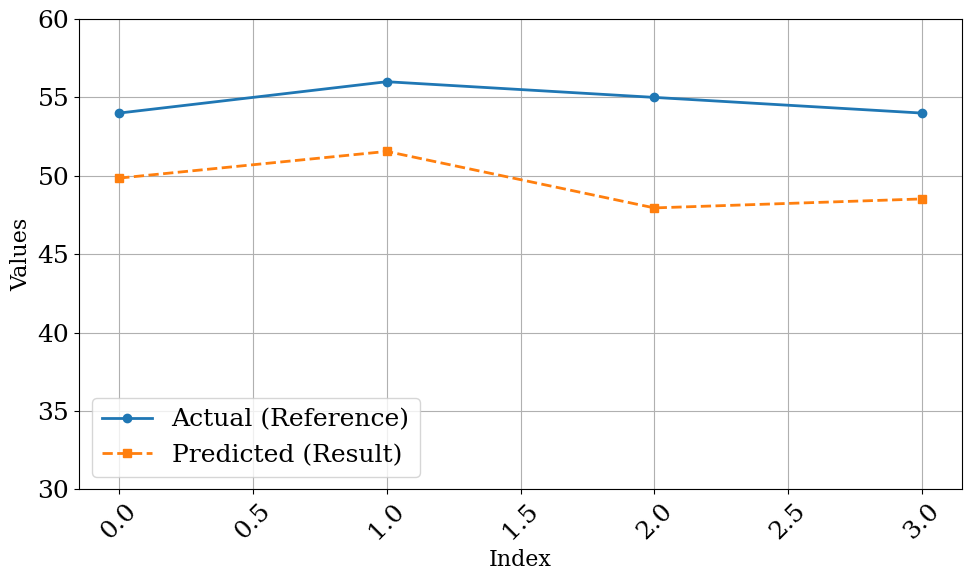

In [177]:
# Convert the DataFrames to NumPy arrays
sarimax_forecast_array = sarima_predictions.to_numpy().flatten()
summed_up_array = summed_up.to_numpy().flatten()

# Ensure both arrays have the same length
min_length = min(len(sarimax_forecast_array), len(summed_up_array))
sarimax_forecast_array = sarimax_forecast_array[:min_length]
summed_up_array = summed_up_array[:min_length]

# Perform element-wise summation
combined_sum_array = sarimax_forecast_array + summed_up_array

# Convert the result back to a DataFrame (optional)
result_df = pd.DataFrame(combined_sum_array, columns=['Combined_Sum'])

# Print the resulting DataFrame
print(result_df)

# Reset the index of the reference DataFrame
reference = reference.reset_index(drop=True)

# Ensure alignment of lengths
min_length = min(len(result_df), len(reference))
predicted = result_df.iloc[:min_length]['Combined_Sum']
test = reference.iloc[:min_length].squeeze()

# Calculate MAE and MAPE
mae = mean_absolute_error(test, predicted)
mape = mean_absolute_percentage_error(test, predicted)

# Print MAE and MAPE
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2%}")

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(test.index, test, label='Actual (Reference)', marker='o', linestyle='-', linewidth=2)
plt.plot(predicted.index, predicted, label='Predicted (Result)', marker='s', linestyle='--', linewidth=2)
 
plt.xlabel('Index')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(30, 60)
plt.show()


In [178]:
end_time=time.time()

In [179]:
Cost = end_time - start_time

In [180]:
main_results = update_results(main_results, 'SARIMA W RFE + PSO BEST FEATUREs', mae, mape,Cost)

In [181]:
main_results

,Model_Name,MAE,MAPE,Cost
0,BASE SARIMA WITHOUT DECOMPOSITION,6.541955,0.119359,18.071575
1,BASE AUTO SARIMA WITHOUT DECOMPOSITION,4.204041,0.076676,40.555002
2,SARIMA by DECOMPOSITION W NO FEATURE,4.151245,0.075817,6.884008
3,AUTO SARIMA BY DECOMPOSITION W NO FEATURE,6.374455,0.116646,79.508049
4,Topological Dataset,0,0,0
5,SARIMA W ALL FEATUREs,6.828631,0.124984,80.456107
6,SARIMA W RFE FEATUREs,2.643748,0.048382,251.586817
7,SARIMA W RFE + PSO FEATUREs,5.279735,0.096445,5.185002
8,SARIMA W RFE + PSO BEST FEATUREs,5.279735,0.096445,7.869986


# MODEL 5-1 : FEATURE SELECTION REGRESSION ANALYSIS

In [182]:
data

,entropy_0,entropy_1,amplitude_wasserstein_0,betti_L1_H0,betti_L2_H0,betti_L1_H1,betti_L2_H1,landscape_features_L1_H0_LS,landscape_features_L2_H0_LS,landscape_features_L1_H1_LS,...,Col97_L1_H1,Col98_L2_H1,Col99_L2_H1,dim_0_median_lifetime,dim_0_std_lifetime,dim_0_min_lifetime,dim_0_carlsson_f2,dim_0_carlsson_f4,dim_1_sum_death_times,Target
0,0.726004,0.000000,0.365710,0.325490,0.354875,0.000000,0.000000,0.173145,0.246289,0.000000,...,0.0,0.0,0.0,0.173090,0.352635,0.279586,0.219420,0.017568,0.000000,-3.075369
1,0.768633,0.504921,0.326804,0.301961,0.350466,0.000000,0.000000,0.121658,0.183489,0.000000,...,0.0,0.0,0.0,0.173090,0.299687,0.279586,0.151013,0.007091,0.338784,-6.716898
2,0.777353,0.504921,0.432683,0.407843,0.452532,0.000000,0.000000,0.141035,0.207710,0.000000,...,0.0,0.0,0.0,0.315155,0.343092,0.279586,0.152074,0.009775,0.338784,-7.802650
3,0.718639,0.504921,0.432302,0.396078,0.421799,0.000000,0.000000,0.141035,0.207710,0.000000,...,0.0,0.0,0.0,0.346104,0.369964,0.143370,0.141079,0.009816,0.338784,-18.026339
4,0.755217,0.000000,0.519240,0.494118,0.534713,0.000000,0.000000,0.148038,0.216279,0.000000,...,0.0,0.0,0.0,0.632132,0.381655,0.143370,0.120959,0.011042,0.000000,-27.334787
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
650,0.752778,0.000000,0.800480,0.752941,0.718696,0.000000,0.000000,0.432073,0.517005,0.000000,...,0.0,0.0,0.0,0.566185,0.570022,0.219247,0.527952,0.340725,0.000000,-0.982344
651,0.895503,0.000000,0.743475,0.749020,0.811463,0.000000,0.000000,0.432073,0.517005,0.000000,...,0.0,0.0,0.0,0.535067,0.402502,0.823432,0.639829,0.407152,0.000000,5.799075
652,0.831399,0.000000,0.649615,0.627451,0.681734,0.000000,0.000000,0.432073,0.517005,0.000000,...,0.0,0.0,0.0,0.511863,0.448824,0.446192,0.621161,0.303231,0.000000,3.641816
653,0.934680,0.000000,0.393907,0.423529,0.564681,0.000000,0.000000,0.080758,0.129454,0.000000,...,0.0,0.0,0.0,0.470647,0.163121,0.431317,0.071073,0.003284,0.000000,12.900423


In [183]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from xgboost import XGBRegressor

start_time=time.time()

# Step 1: Split the data
train_data = data[:-4]
test_data = data[-4:]

X_train = train_data.drop(columns=["Target"])
X_test = test_data.drop(columns=["Target"])
y_train = train_data["Target"]
y_test = test_data["Target"]

from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

In [184]:
from sklearn.ensemble import RandomForestRegressor
import numpy as np

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Get top k important features
importances = pd.Series(model.feature_importances_, index=X_train.columns)
selected_features = importances.sort_values(ascending=False).head(50).index  # choose top 20 or tune

X_train = X_train[selected_features]
X_test = X_test[selected_features]


In [185]:
X_train

,Col6_L1_H0,dim_0_min_lifetime,L1_H0,Col8_L1_H0,Col65_L1_H0,Col7_L1_H0,Col27_L1_H0,Col18_L2_H0,Col9_L1_H0,Col31_L2_H0,...,Col56_L2_H0,Col25_L2_H0,Col35_L2_H0,Col23_L2_H0,betti_L1_H0,Col19_L1_H0,landscape_features_L1_H1_LS,Col50_L1_H0,Col22_L1_H0,Col24_L2_H0
0,0.901709,0.279586,0.758587,0.643855,0.000000,0.747701,0.121911,0.468072,0.618429,0.153364,...,0.014576,0.158252,0.253082,0.194167,0.325490,0.421903,0.0,0.115217,0.255358,0.174960
1,0.901709,0.279586,0.758587,0.643855,0.000000,0.747701,0.145681,0.468175,0.618429,0.229737,...,0.000290,0.169527,0.381637,0.198126,0.301961,0.422132,0.0,0.012778,0.257400,0.181768
2,0.861795,0.279586,0.812473,0.505588,0.000000,0.644887,0.153850,0.390026,0.470304,0.278107,...,0.001549,0.166584,0.524165,0.180727,0.407843,0.359898,0.0,0.038579,0.231774,0.172415
3,0.681734,0.143370,0.694740,0.361209,0.000000,0.471547,0.174923,0.349313,0.349676,0.286213,...,0.001549,0.191917,0.525782,0.196621,0.396078,0.331028,0.0,0.038579,0.237645,0.194540
4,0.650758,0.143370,0.723835,0.259818,0.000000,0.398105,0.193436,0.232129,0.235203,0.339818,...,0.004019,0.189083,0.640407,0.162155,0.494118,0.229937,0.0,0.076734,0.187602,0.177221
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
646,0.721205,0.219247,0.827582,0.217793,0.002223,0.410888,0.602427,0.095598,0.159803,0.589342,...,0.212019,0.546017,0.422041,0.343395,0.607843,0.124349,0.0,0.535106,0.268644,0.449888
647,0.721475,0.219247,0.827196,0.219173,0.018003,0.411628,0.623566,0.168646,0.162011,0.475728,...,0.418601,0.655290,0.290499,0.498982,0.596078,0.217509,0.0,0.534914,0.415733,0.587983
648,0.721475,0.219247,0.827214,0.219092,0.000731,0.411628,0.615960,0.161259,0.161934,0.514984,...,0.092453,0.632262,0.406805,0.472783,0.556863,0.207034,0.0,0.312400,0.393343,0.562138
649,0.721276,0.219247,0.827472,0.218066,0.532360,0.411071,0.778245,0.132395,0.160334,0.711338,...,0.059584,0.735896,0.465213,0.499555,0.600000,0.176490,0.0,0.002244,0.391468,0.624795


In [186]:
import warnings
warnings.filterwarnings("ignore")  # Suppress all warnings

from sklearn.linear_model import Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, make_scorer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import pandas as pd
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
# Optional: scale for SVR and other sensitive models
scaler = StandardScaler()


tscv = TimeSeriesSplit(n_splits=5)

# Step 1: Define models and their hyperparameter grids
models = {
    "Lasso": (Lasso(), {
        "alpha": [0.001, 0.01, 0.1, 1, 10]
    }),
    "ElasticNet": (ElasticNet(), {
        "alpha": [0.001, 0.01, 0.1, 1, 10],
        "l1_ratio": [0.1, 0.5, 0.9]
    }),
    "RandomForest": (RandomForestRegressor(), {
        "n_estimators": [100, 200],
        "max_depth": [None, 10, 20]
    }),
    "XGBoost": (XGBRegressor(verbosity=0), {
        "n_estimators": [100, 200],
        "learning_rate": [0.01, 0.1],
        "max_depth": [3, 6]
    }),
    
    "CatBoost": (CatBoostRegressor(verbose=0), {
        "iterations": [100, 200],
        "learning_rate": [0.01, 0.1],
        "depth": [3, 6]
    }),
    "GradientBoosting": (GradientBoostingRegressor(), {
        "n_estimators": [100, 200],
        "learning_rate": [0.01, 0.1],
        "max_depth": [3, 6]
    }),
    "SVR": (Pipeline([
        ('scaler', StandardScaler()),
        ('svr', SVR())
    ]), {
        "svr__C": [0.1, 1, 10],
        "svr__epsilon": [0.01, 0.1]
    })
}

results = []

# Step 2: Run grid search and evaluate
for name, (model, param_grid) in models.items():
    print(f"🔍 Tuning {name}...")

    grid = GridSearchCV(model, param_grid, cv=tscv, scoring=make_scorer(mean_absolute_error, greater_is_better=False), n_jobs=-1)
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    preds = best_model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    mape = mean_absolute_percentage_error(y_test, preds)

    results.append({
        "Model": name,
        "MAE": mae,
        "MAPE": mape,
        "ModelObject": best_model,
        "BestParams": grid.best_params_
    })

# Step 3: Choose the best model based on MAE, then MAPE
results_df = pd.DataFrame(results).sort_values(by=["MAE", "MAPE"])
best = results_df.iloc[0]
best_model = best["ModelObject"]

print("✅ Best Model:", best["Model"])
print("🔹 MAE:", best["MAE"])
print("🔹 MAPE:", best["MAPE"])
print("🎯 Best Params:", best["BestParams"])


🔍 Tuning Lasso...
🔍 Tuning ElasticNet...
🔍 Tuning RandomForest...
🔍 Tuning XGBoost...
🔍 Tuning CatBoost...
🔍 Tuning GradientBoosting...
🔍 Tuning SVR...
✅ Best Model: SVR
🔹 MAE: 5.622899090311273
🔹 MAPE: 0.8352455232751304
🎯 Best Params: {'svr__C': 0.1, 'svr__epsilon': 0.01}


<Figure size 1400x600 with 0 Axes>

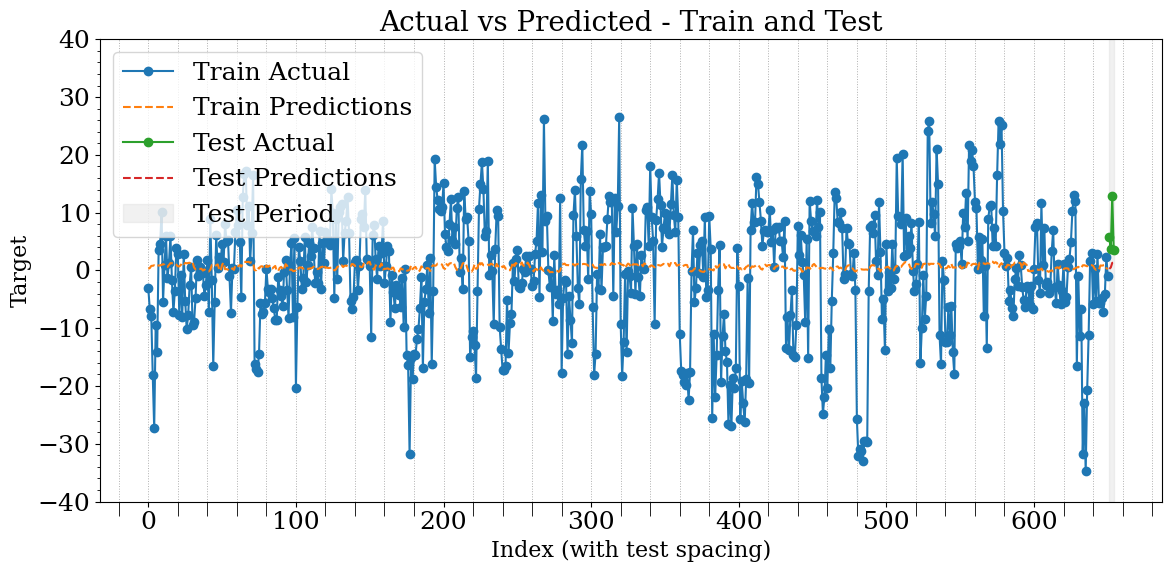

Train MAE: 7.9875
Train MAPE: 1.3076
Test MAE: 5.6229
Test MAPE: 0.8352


In [187]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# Train the best ML model on the training data

best_model.fit(X_train, y_train)

# In-sample predictions for the training set
train_predictions = best_model.predict(X_train)

# Forecasting for the test set
test_predictions = best_model.predict(X_test)

# Calculate evaluation metrics for the training set
train_mae = mean_absolute_error(y_train, train_predictions)
train_mape = mean_absolute_percentage_error(y_train, train_predictions)

# Calculate evaluation metrics for the test set
test_mae = mean_absolute_error(y_test, test_predictions)
test_mape = mean_absolute_percentage_error(y_test, test_predictions)


plt.figure(figsize=(14, 6))

# Convert index to a numeric range for controlled spacing
train_x = np.arange(len(train_data))
test_x = np.arange(len(test_data))  + len(train_data)  # 5x spacing and offset after train

# Plot actual and predicted values
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data['Target'], label='Train Actual', marker='o')
plt.plot(train_data.index, train_predictions, label='Train Predictions', linestyle='--')
plt.plot(test_data.index, test_data['Target'], label='Test Actual', marker='o')
plt.plot(test_data.index, test_predictions, label='Test Predictions', linestyle='--')

# Highlight the test period
plt.axvspan(test_x[0], test_x[-1], color='lightgray', alpha=0.3, label='Test Period')

# Make gridlines denser
plt.minorticks_on()
plt.grid(which='both', axis='x', linestyle=':', linewidth=0.7)
plt.tick_params(axis='x', which='minor', length=10)

# Add labels and legend
plt.xlabel('Index (with test spacing)')
plt.ylabel('Target')
plt.title('Actual vs Predicted - Train and Test')
plt.legend(loc='upper left')  # 👈 Changed legend position here
plt.tight_layout()
plt.ylim(-40, 40)
plt.show()

# Output the evaluation metrics
print("Train MAE: {:.4f}".format(train_mae))
print("Train MAPE: {:.4f}".format(train_mape))
print("Test MAE: {:.4f}".format(test_mae))
print("Test MAPE: {:.4f}".format(test_mape))


   Combined_Sum
0     48.389983
1     52.642987
2     43.390838
3     51.444418
MAE: 5.78
MAPE: 10.56%


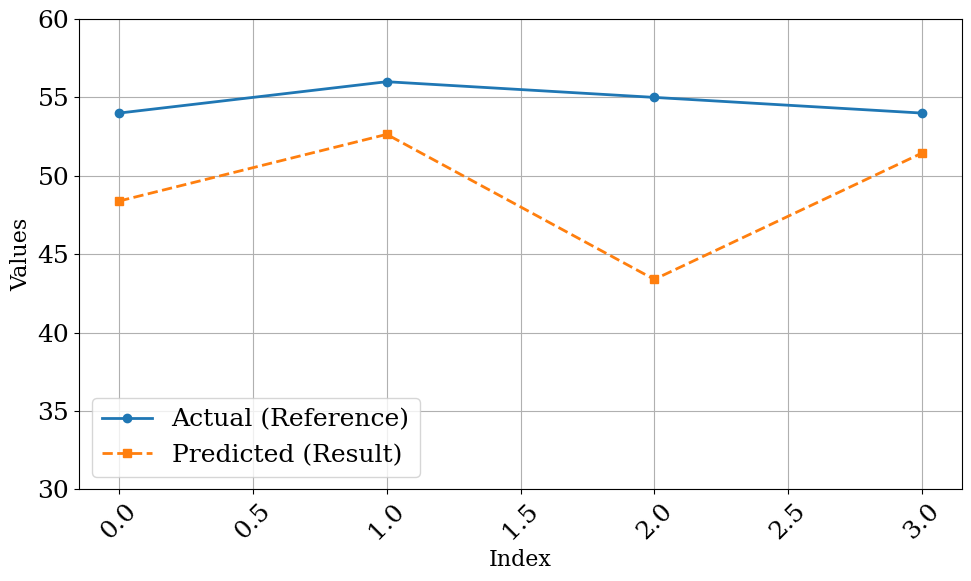

In [188]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# Fit the best model on the training data (exogenous features)
best_model.fit(X_train, y_train)

# Make predictions on the test set
predictions = best_model.predict(X_test)

# Convert the DataFrames to NumPy arrays
predictions_array = predictions.flatten()
summed_up_array = summed_up.to_numpy().flatten()

# Ensure both arrays have the same length
min_length = min(len(predictions_array), len(summed_up_array))
predictions_array = predictions_array[:min_length]
summed_up_array = summed_up_array[:min_length]

# Perform element-wise summation
combined_sum_array = predictions_array + summed_up_array

# Convert the result back to a DataFrame (optional)
result_df = pd.DataFrame(combined_sum_array, columns=['Combined_Sum'])

# Print the resulting DataFrame
print(result_df)

# Reset the index of the reference DataFrame
reference = reference.reset_index(drop=True)

# Ensure alignment of lengths
min_length = min(len(result_df), len(reference))
predicted = result_df.iloc[:min_length]['Combined_Sum']
test = reference.iloc[:min_length].squeeze()

# Calculate MAE and MAPE
mae = mean_absolute_error(test, predicted)
mape = mean_absolute_percentage_error(test, predicted)

# Print MAE and MAPE
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2%}")

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(test.index, test, label='Actual (Reference)', marker='o', linestyle='-', linewidth=2)
plt.plot(predicted.index, predicted, label='Predicted (Result)', marker='s', linestyle='--', linewidth=2)

plt.xlabel('Index')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(30, 60)
plt.show()




In [189]:
end_time=time.time()

In [190]:
Cost=end_time-start_time

In [191]:
main_results = update_results(main_results, 'Regression Model W SELECTED FEATURES', mae, mape, Cost)

In [192]:
main_results

,Model_Name,MAE,MAPE,Cost
0,BASE SARIMA WITHOUT DECOMPOSITION,6.541955,0.119359,18.071575
1,BASE AUTO SARIMA WITHOUT DECOMPOSITION,4.204041,0.076676,40.555002
2,SARIMA by DECOMPOSITION W NO FEATURE,4.151245,0.075817,6.884008
3,AUTO SARIMA BY DECOMPOSITION W NO FEATURE,6.374455,0.116646,79.508049
4,Topological Dataset,0,0,0
5,SARIMA W ALL FEATUREs,6.828631,0.124984,80.456107
6,SARIMA W RFE FEATUREs,2.643748,0.048382,251.586817
7,SARIMA W RFE + PSO FEATUREs,5.279735,0.096445,5.185002
8,SARIMA W RFE + PSO BEST FEATUREs,5.279735,0.096445,7.869986
9,Regression Model W SELECTED FEATURES,5.782944,0.105559,168.565213


# MODEL 5 : ALL FEATURES REGRESSION ANALYSIS

In [193]:
data

,entropy_0,entropy_1,amplitude_wasserstein_0,betti_L1_H0,betti_L2_H0,betti_L1_H1,betti_L2_H1,landscape_features_L1_H0_LS,landscape_features_L2_H0_LS,landscape_features_L1_H1_LS,...,Col97_L1_H1,Col98_L2_H1,Col99_L2_H1,dim_0_median_lifetime,dim_0_std_lifetime,dim_0_min_lifetime,dim_0_carlsson_f2,dim_0_carlsson_f4,dim_1_sum_death_times,Target
0,0.726004,0.000000,0.365710,0.325490,0.354875,0.000000,0.000000,0.173145,0.246289,0.000000,...,0.0,0.0,0.0,0.173090,0.352635,0.279586,0.219420,0.017568,0.000000,-3.075369
1,0.768633,0.504921,0.326804,0.301961,0.350466,0.000000,0.000000,0.121658,0.183489,0.000000,...,0.0,0.0,0.0,0.173090,0.299687,0.279586,0.151013,0.007091,0.338784,-6.716898
2,0.777353,0.504921,0.432683,0.407843,0.452532,0.000000,0.000000,0.141035,0.207710,0.000000,...,0.0,0.0,0.0,0.315155,0.343092,0.279586,0.152074,0.009775,0.338784,-7.802650
3,0.718639,0.504921,0.432302,0.396078,0.421799,0.000000,0.000000,0.141035,0.207710,0.000000,...,0.0,0.0,0.0,0.346104,0.369964,0.143370,0.141079,0.009816,0.338784,-18.026339
4,0.755217,0.000000,0.519240,0.494118,0.534713,0.000000,0.000000,0.148038,0.216279,0.000000,...,0.0,0.0,0.0,0.632132,0.381655,0.143370,0.120959,0.011042,0.000000,-27.334787
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
650,0.752778,0.000000,0.800480,0.752941,0.718696,0.000000,0.000000,0.432073,0.517005,0.000000,...,0.0,0.0,0.0,0.566185,0.570022,0.219247,0.527952,0.340725,0.000000,-0.982344
651,0.895503,0.000000,0.743475,0.749020,0.811463,0.000000,0.000000,0.432073,0.517005,0.000000,...,0.0,0.0,0.0,0.535067,0.402502,0.823432,0.639829,0.407152,0.000000,5.799075
652,0.831399,0.000000,0.649615,0.627451,0.681734,0.000000,0.000000,0.432073,0.517005,0.000000,...,0.0,0.0,0.0,0.511863,0.448824,0.446192,0.621161,0.303231,0.000000,3.641816
653,0.934680,0.000000,0.393907,0.423529,0.564681,0.000000,0.000000,0.080758,0.129454,0.000000,...,0.0,0.0,0.0,0.470647,0.163121,0.431317,0.071073,0.003284,0.000000,12.900423


In [194]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from xgboost import XGBRegressor

start_time=time.time()

# Step 1: Split the data
train_data = data[:-4]
test_data = data[-4:]

X_train = train_data.drop(columns=["Target"])
X_test = test_data.drop(columns=["Target"])
y_train = train_data["Target"]
y_test = test_data["Target"]

In [195]:
import warnings
warnings.filterwarnings("ignore")  # Suppress all warnings

from sklearn.linear_model import Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, make_scorer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import pandas as pd
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
# Optional: scale for SVR and other sensitive models
scaler = StandardScaler()


tscv = TimeSeriesSplit(n_splits=5)

# Step 1: Define models and their hyperparameter grids
models = {
    "Lasso": (Lasso(), {
        "alpha": [0.001, 0.01, 0.1, 1, 10]
    }),
    "ElasticNet": (ElasticNet(), {
        "alpha": [0.001, 0.01, 0.1, 1, 10],
        "l1_ratio": [0.1, 0.5, 0.9]
    }),
    "RandomForest": (RandomForestRegressor(), {
        "n_estimators": [100, 200],
        "max_depth": [None, 10, 20]
    }),
    "XGBoost": (XGBRegressor(verbosity=0), {
        "n_estimators": [100, 200],
        "learning_rate": [0.01, 0.1],
        "max_depth": [3, 6]
    }),
    
    "CatBoost": (CatBoostRegressor(verbose=0), {
        "iterations": [100, 200],
        "learning_rate": [0.01, 0.1],
        "depth": [3, 6]
    }),
    "GradientBoosting": (GradientBoostingRegressor(), {
        "n_estimators": [100, 200],
        "learning_rate": [0.01, 0.1],
        "max_depth": [3, 6]
    }),
    "SVR": (Pipeline([
        ('scaler', StandardScaler()),
        ('svr', SVR())
    ]), {
        "svr__C": [0.1, 1, 10],
        "svr__epsilon": [0.01, 0.1]
    })
}

results = []

# Step 2: Run grid search and evaluate
for name, (model, param_grid) in models.items():
    print(f"🔍 Tuning {name}...")

    grid = GridSearchCV(model, param_grid, cv=tscv, scoring=make_scorer(mean_absolute_error, greater_is_better=False), n_jobs=-1)
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    preds = best_model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    mape = mean_absolute_percentage_error(y_test, preds)

    results.append({
        "Model": name,
        "MAE": mae,
        "MAPE": mape,
        "ModelObject": best_model,
        "BestParams": grid.best_params_
    })

# Step 3: Choose the best model based on MAE, then MAPE
results_df = pd.DataFrame(results).sort_values(by=["MAE", "MAPE"])
best = results_df.iloc[0]
best_model = best["ModelObject"]

print("✅ Best Model:", best["Model"])
print("🔹 MAE:", best["MAE"])
print("🔹 MAPE:", best["MAPE"])
print("🎯 Best Params:", best["BestParams"])


🔍 Tuning Lasso...
🔍 Tuning ElasticNet...
🔍 Tuning RandomForest...
🔍 Tuning XGBoost...
🔍 Tuning CatBoost...
🔍 Tuning GradientBoosting...
🔍 Tuning SVR...
✅ Best Model: SVR
🔹 MAE: 5.696331254480855
🔹 MAPE: 0.8484980603853747
🎯 Best Params: {'svr__C': 0.1, 'svr__epsilon': 0.01}


<Figure size 1400x600 with 0 Axes>

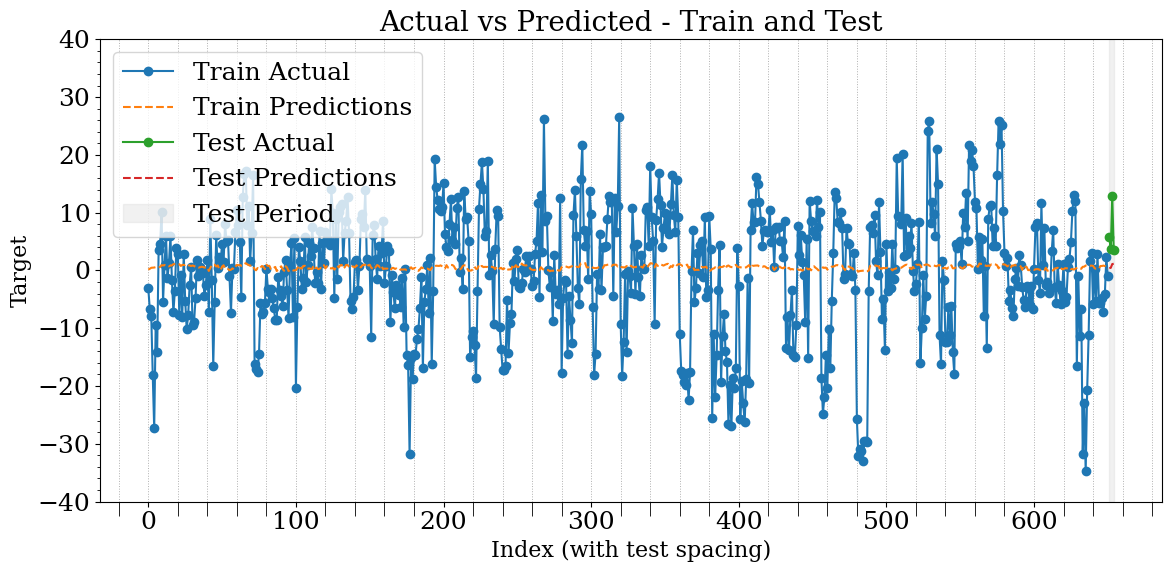

Train MAE: 8.0085
Train MAPE: 1.2332
Test MAE: 5.6963
Test MAPE: 0.8485


In [196]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# Train the best ML model on the training data

best_model.fit(X_train, y_train)

# In-sample predictions for the training set
train_predictions = best_model.predict(X_train)

# Forecasting for the test set
test_predictions = best_model.predict(X_test)

# Calculate evaluation metrics for the training set
train_mae = mean_absolute_error(y_train, train_predictions)
train_mape = mean_absolute_percentage_error(y_train, train_predictions)

# Calculate evaluation metrics for the test set
test_mae = mean_absolute_error(y_test, test_predictions)
test_mape = mean_absolute_percentage_error(y_test, test_predictions)


plt.figure(figsize=(14, 6))

# Convert index to a numeric range for controlled spacing
train_x = np.arange(len(train_data))
test_x = np.arange(len(test_data))  + len(train_data)  # 5x spacing and offset after train

# Plot actual and predicted values
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data['Target'], label='Train Actual', marker='o')
plt.plot(train_data.index, train_predictions, label='Train Predictions', linestyle='--')
plt.plot(test_data.index, test_data['Target'], label='Test Actual', marker='o')
plt.plot(test_data.index, test_predictions, label='Test Predictions', linestyle='--')

# Highlight the test period
plt.axvspan(test_x[0], test_x[-1], color='lightgray', alpha=0.3, label='Test Period')

# Make gridlines denser
plt.minorticks_on()
plt.grid(which='both', axis='x', linestyle=':', linewidth=0.7)
plt.tick_params(axis='x', which='minor', length=10)

# Add labels and legend
plt.xlabel('Index (with test spacing)')
plt.ylabel('Target')
plt.title('Actual vs Predicted - Train and Test')
plt.legend(loc='upper left')  # 👈 Changed legend position here
plt.tight_layout()
plt.ylim(-40, 40)
plt.show()

# Output the evaluation metrics
print("Train MAE: {:.4f}".format(train_mae))
print("Train MAPE: {:.4f}".format(train_mape))
print("Test MAE: {:.4f}".format(test_mae))
print("Test MAPE: {:.4f}".format(test_mape))


   Combined_Sum
0     48.518372
1     52.591000
2     43.179977
3     51.285147
MAE: 5.86
MAPE: 10.69%


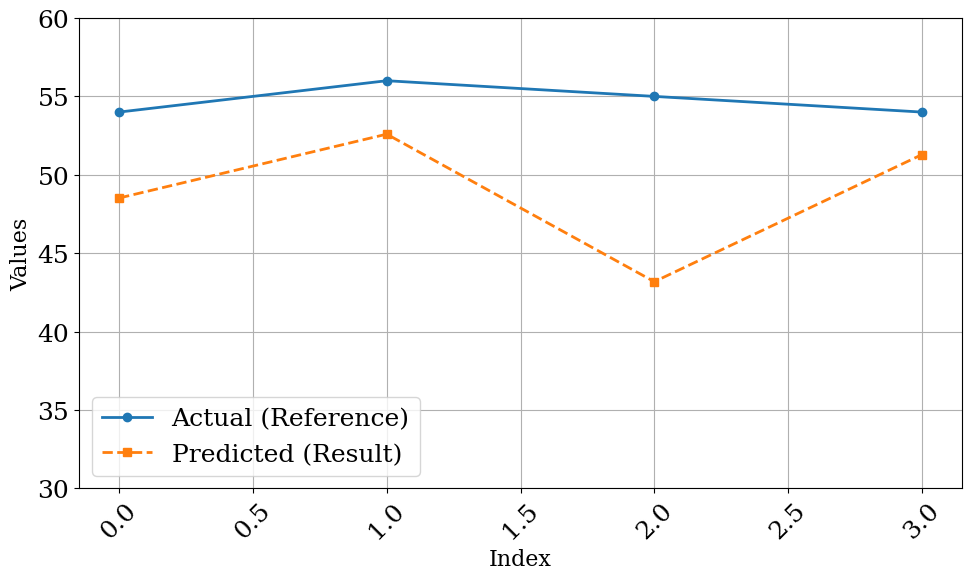

In [197]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# Fit the best model on the training data (exogenous features)
best_model.fit(X_train, y_train)

# Make predictions on the test set
predictions = best_model.predict(X_test)

# Convert the DataFrames to NumPy arrays
predictions_array = predictions.flatten()
summed_up_array = summed_up.to_numpy().flatten()

# Ensure both arrays have the same length
min_length = min(len(predictions_array), len(summed_up_array))
predictions_array = predictions_array[:min_length]
summed_up_array = summed_up_array[:min_length]

# Perform element-wise summation
combined_sum_array = predictions_array + summed_up_array

# Convert the result back to a DataFrame (optional)
result_df = pd.DataFrame(combined_sum_array, columns=['Combined_Sum'])

# Print the resulting DataFrame
print(result_df)

# Reset the index of the reference DataFrame
reference = reference.reset_index(drop=True)

# Ensure alignment of lengths
min_length = min(len(result_df), len(reference))
predicted = result_df.iloc[:min_length]['Combined_Sum']
test = reference.iloc[:min_length].squeeze()

# Calculate MAE and MAPE
mae = mean_absolute_error(test, predicted)
mape = mean_absolute_percentage_error(test, predicted)

# Print MAE and MAPE
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2%}")

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(test.index, test, label='Actual (Reference)', marker='o', linestyle='-', linewidth=2)
plt.plot(predicted.index, predicted, label='Predicted (Result)', marker='s', linestyle='--', linewidth=2)

plt.xlabel('Index')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(30, 60)
plt.show()




In [198]:
end_time=time.time()

In [199]:
Cost=end_time-start_time

In [200]:
main_results = update_results(main_results, 'Regression Model All', mae, mape, Cost)

In [201]:
main_results

,Model_Name,MAE,MAPE,Cost
0,BASE SARIMA WITHOUT DECOMPOSITION,6.541955,0.119359,18.071575
1,BASE AUTO SARIMA WITHOUT DECOMPOSITION,4.204041,0.076676,40.555002
2,SARIMA by DECOMPOSITION W NO FEATURE,4.151245,0.075817,6.884008
3,AUTO SARIMA BY DECOMPOSITION W NO FEATURE,6.374455,0.116646,79.508049
4,Topological Dataset,0,0,0
5,SARIMA W ALL FEATUREs,6.828631,0.124984,80.456107
6,SARIMA W RFE FEATUREs,2.643748,0.048382,251.586817
7,SARIMA W RFE + PSO FEATUREs,5.279735,0.096445,5.185002
8,SARIMA W RFE + PSO BEST FEATUREs,5.279735,0.096445,7.869986
9,Regression Model W SELECTED FEATURES,5.782944,0.105559,168.565213


# MODEL 6 HYBRID MODEL REGRESSION AND SARIMA

In [202]:
start_time=time.time()

In [203]:
# Step 4: Apply best model to the entire dataset
X_all = data.drop(columns=["Target"])
y_all = data["Target"]
preds_all = best_model.predict(X_all)

In [204]:
# Step 5: Create the difference DataFrame
diff_df = pd.DataFrame({
    "Actual": y_all.values,
    "Predicted": preds_all,
    "Difference": y_all.values - preds_all
}, index=data.index)

In [205]:
# Step 1: Create a new column 'Target' from the residuals
diff_df['Target'] = diff_df['Difference']

# Step 2: Split the data into train and test
y_train = diff_df[:-4]
y_test = diff_df[-4:]

In [206]:
from statsmodels.tsa.stattools import kpss

# Applying the KPSS test to the training data to test for stationarity
kpss_test = kpss(y_train['Target'], regression='c')

# Unpacking the KPSS test results
kpss_statistic, p_value, lags, critical_values = kpss_test

# Displaying the KPSS test results
kpss_test_result = {
    'KPSS Statistic': kpss_statistic,
    'p-value': p_value,
    'Lags Used': lags,
    'Critical Values': critical_values,
    'Conclusion': 'Stationary' if p_value > 0.05 else 'Not stationary'
}

kpss_test_result


{'KPSS Statistic': 0.04477619543116452,
 'p-value': 0.1,
 'Lags Used': 14,
 'Critical Values': {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739},
 'Conclusion': 'Stationary'}

In [207]:
from pmdarima.arima import auto_arima, OCSBTest, CHTest

# time series after first differencing
# OCSB test that returns the recommended order of seasonal differencing:
n_ocsb = OCSBTest(m=12).estimate_seasonal_differencing_term(y_train['Target'])

# CH test that returns the recommended order of seasonal differencing:
n_ch = CHTest(m=12).estimate_seasonal_differencing_term(y_train['Target'])

# seasonal differencing recommendation:
print("time series -")
n_seasdiffs = {"recommended order of seasonal differencing":"", "OCSB recommendation":n_ocsb, "nCH recommendation":n_ch}
[print(key, ":", value) for key,value in n_seasdiffs.items()]

time series -
recommended order of seasonal differencing : 
OCSB recommendation : 0
nCH recommendation : 0


[None, None, None]

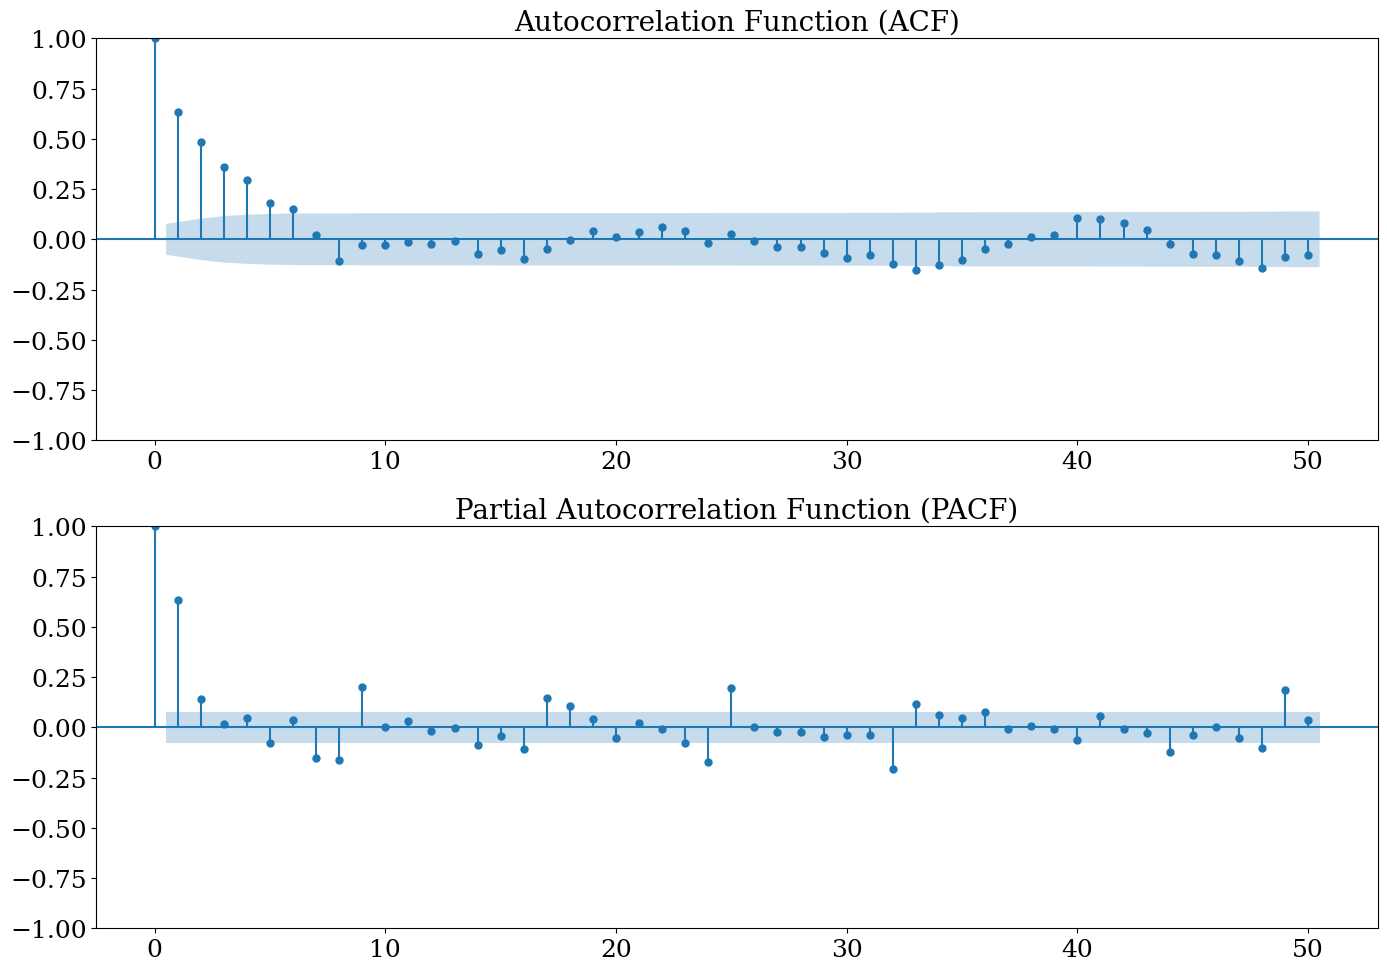

In [208]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot ACF and PACF for the cleaned training data
plt.figure(figsize=(14, 10))

# ACF plot
plt.subplot(2, 1, 1)
plot_acf(y_train['Target'], lags=50, ax=plt.gca())
plt.title("Autocorrelation Function (ACF)")

# PACF plot
plt.subplot(2, 1, 2)
plot_pacf(y_train['Target'], lags=50, ax=plt.gca(), method='ywm')
plt.title("Partial Autocorrelation Function (PACF)")

# Save the figure as an SVG file
plt.savefig("acf_h1.svg", format="svg", dpi=900, bbox_inches='tight', facecolor='white')
plt.tight_layout()
plt.show()

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[8] intercept   : AIC=4901.072, Time=0.03 sec
 ARIMA(1,0,0)(1,0,0)[8] intercept   : AIC=4534.374, Time=0.53 sec
 ARIMA(0,0,1)(0,0,1)[8] intercept   : AIC=4677.548, Time=0.40 sec
 ARIMA(0,0,0)(0,0,0)[8]             : AIC=4904.016, Time=0.02 sec
 ARIMA(1,0,0)(0,0,0)[8] intercept   : AIC=4571.325, Time=0.08 sec
 ARIMA(1,0,0)(2,0,0)[8] intercept   : AIC=4510.390, Time=2.74 sec
 ARIMA(1,0,0)(2,0,1)[8] intercept   : AIC=inf, Time=4.45 sec
 ARIMA(1,0,0)(1,0,1)[8] intercept   : AIC=inf, Time=3.41 sec
 ARIMA(0,0,0)(2,0,0)[8] intercept   : AIC=4889.048, Time=3.34 sec
 ARIMA(2,0,0)(2,0,0)[8] intercept   : AIC=4485.185, Time=8.74 sec
 ARIMA(2,0,0)(1,0,0)[8] intercept   : AIC=4514.476, Time=1.67 sec
 ARIMA(2,0,0)(2,0,1)[8] intercept   : AIC=inf, Time=2.55 sec
 ARIMA(2,0,0)(1,0,1)[8] intercept   : AIC=inf, Time=1.22 sec
 ARIMA(3,0,0)(2,0,0)[8] intercept   : AIC=4485.276, Time=4.56 sec
 ARIMA(2,0,1)(2,0,0)[8] intercept   : AIC=4483.254, T

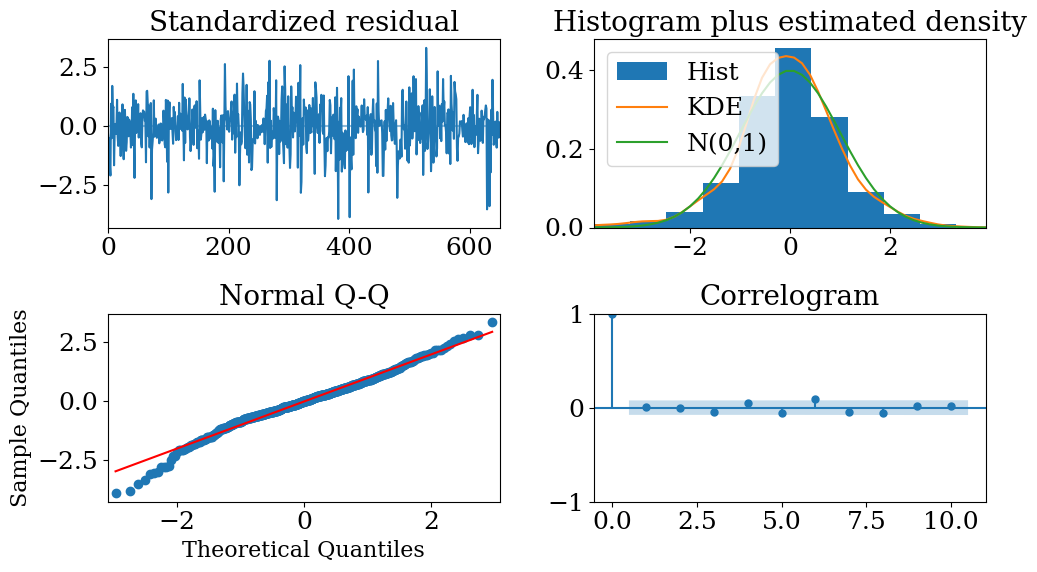

In [209]:
from pmdarima import auto_arima
import matplotlib.pyplot as plt

# Extract the time series from your training data
y_series = y_train['Target']

# Fit the seasonal ARIMA model
stepwise_model = auto_arima(
    y_series,
    start_p=0, start_q=0,
    max_p=5, max_q=5,
    seasonal=True,
    m=8,  # seasonal period
    start_P=0, start_Q=0,
    max_P=2, max_Q=2,
    d=None, D=None,           # let auto_arima figure out differencing
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True,
    information_criterion='aic'
)

# Print summary of the best model
print(stepwise_model.summary())

# Plot diagnostics
stepwise_model.plot_diagnostics(figsize=(10, 6))
plt.tight_layout()
plt.show()


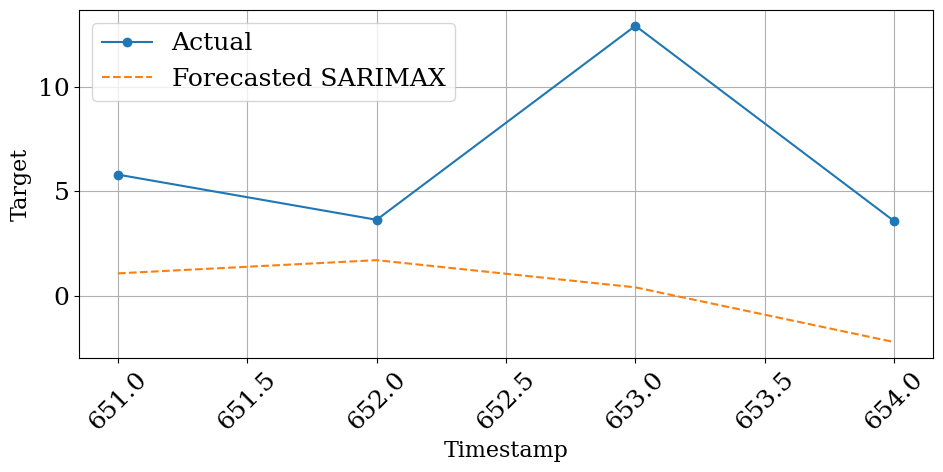

(6.223922594858248, 0.980823710834531)

In [210]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt


n_periods = len(test_data)
sarima_predictions = stepwise_model.predict(n_periods=n_periods)

# Calculate evaluation metrics
sarima_mse = mean_absolute_error(test_data['Target'], sarima_predictions)
sarima_mape = mean_absolute_percentage_error(test_data['Target'], sarima_predictions)

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(test_data.index, test_data['Target'], label='Actual', marker='o')
plt.plot(test_data.index, sarima_predictions, label='Forecasted SARIMAX', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Output the MSE and MAPE values
sarima_mse, sarima_mape


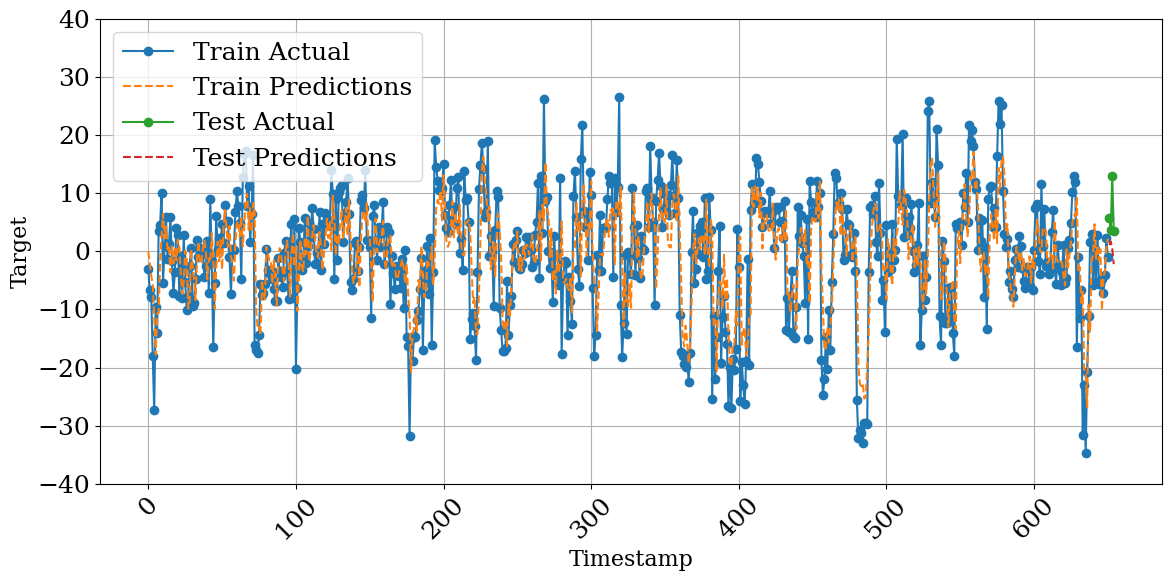

Train MAE: 5.6986
Train MAPE: 3.3252
Test MAE: 6.2239
Test MAPE: 0.9808


In [211]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# In-sample predictions for the training set
train_predictions = stepwise_model.predict_in_sample()

# Forecasting the values for the test set
test_predictions = stepwise_model.predict(n_periods=len(test_data))

# Calculate evaluation metrics for the training set
train_mae = mean_absolute_error(train_data['Target'], train_predictions)
train_mape = mean_absolute_percentage_error(train_data['Target'], train_predictions)

# Calculate evaluation metrics for the test set
test_mae = mean_absolute_error(test_data['Target'], test_predictions)
test_mape = mean_absolute_percentage_error(test_data['Target'], test_predictions)

# Plot the results: actual and predictions for both train and test data
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data['Target'], label='Train Actual', marker='o')
plt.plot(train_data.index, train_predictions, label='Train Predictions', linestyle='--')
plt.plot(test_data.index, test_data['Target'], label='Test Actual', marker='o')
plt.plot(test_data.index, test_predictions, label='Test Predictions', linestyle='--')

plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(-40, 40)
plt.show()

# Output the evaluation metrics
print("Train MAE: {:.4f}".format(train_mae))
print("Train MAPE: {:.4f}".format(train_mape))
print("Test MAE: {:.4f}".format(test_mae))
print("Test MAPE: {:.4f}".format(test_mape))


In [212]:
test_predictions

651    1.085188
652    1.715203
653    0.417149
654   -2.195178
dtype: float64

In [213]:
# Combine them into one residual prediction series
residual_prediction = pd.concat([train_predictions, test_predictions])

In [214]:
residual_prediction

0       0.000000
1      -2.055672
2      -4.239453
3      -5.517214
4     -11.171773
         ...    
650     2.186160
651     1.085188
652     1.715203
653     0.417149
654    -2.195178
Length: 655, dtype: float64

In [215]:
# Step 2: Add SARIMA-predicted residuals to regression predictions
final_predictions = preds_all + residual_prediction

In [216]:
# Step 3: Create final DataFrame
final_df = pd.DataFrame({
    "Regression_Prediction": preds_all,
    "SARIMA_Residual_Prediction": residual_prediction,
    "Final_Prediction": final_predictions,
    "Actual": data["Target"],
    "Difference_Final": data["Target"] - final_predictions
})

# View sample
print(final_df.head())


   Regression_Prediction  SARIMA_Residual_Prediction  Final_Prediction  \
0               0.151487                    0.000000          0.151487   
1               0.292273                   -2.055672         -1.763398   
2               0.463372                   -4.239453         -3.776080   
3               0.483343                   -5.517214         -5.033871   
4               0.507873                  -11.171773        -10.663900   

      Actual  Difference_Final  
0  -3.075369         -3.226856  
1  -6.716898         -4.953500  
2  -7.802650         -4.026569  
3 -18.026339        -12.992468  
4 -27.334787        -16.670887  


In [217]:
sarimax_forecast_array = final_df["Final_Prediction"].iloc[-4:].values
print("📦 sarimax_forecast_array:")
print(sarimax_forecast_array)


📦 sarimax_forecast_array:
[ 1.49166389  2.17331225  1.52575906 -1.03564392]


   Combined_Sum
0     49.197085
1     53.848094
2     42.488516
3     47.930436
MAE: 6.38
MAPE: 11.68%


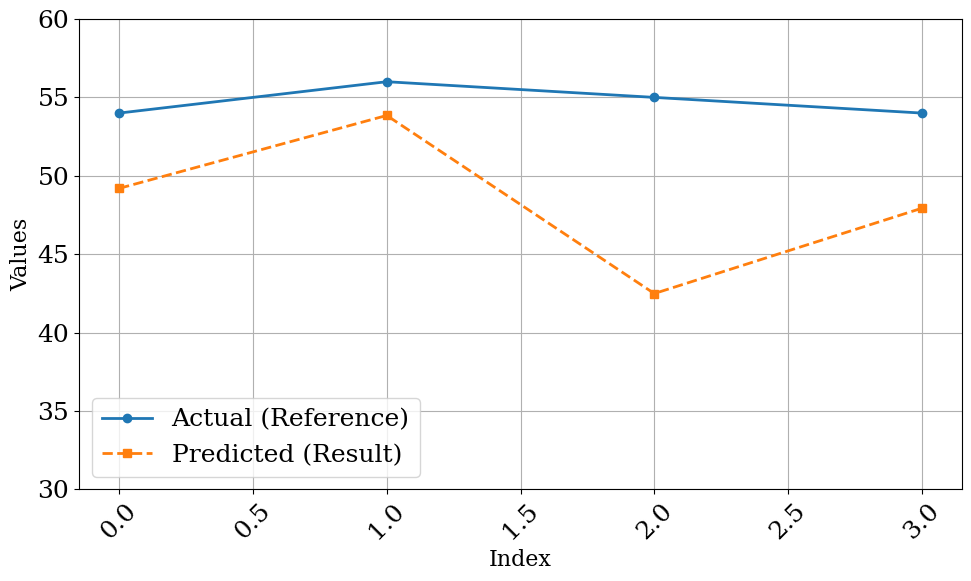

In [218]:
# Convert the DataFrames to NumPy arrays
sarimax_forecast_array = sarima_predictions.to_numpy().flatten()
summed_up_array = summed_up.to_numpy().flatten()

# Ensure both arrays have the same length
min_length = min(len(sarimax_forecast_array), len(summed_up_array))
sarimax_forecast_array = sarimax_forecast_array[:min_length]
summed_up_array = summed_up_array[:min_length]

# Perform element-wise summation
combined_sum_array = sarimax_forecast_array + summed_up_array

# Convert the result back to a DataFrame (optional)
result_df = pd.DataFrame(combined_sum_array, columns=['Combined_Sum'])

# Print the resulting DataFrame
print(result_df)

# Reset the index of the reference DataFrame
reference = reference.reset_index(drop=True)

# Ensure alignment of lengths
min_length = min(len(result_df), len(reference))
predicted = result_df.iloc[:min_length]['Combined_Sum']
test = reference.iloc[:min_length].squeeze()

# Calculate MAE and MAPE
mae = mean_absolute_error(test, predicted)
mape = mean_absolute_percentage_error(test, predicted)

# Print MAE and MAPE
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2%}")

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(test.index, test, label='Actual (Reference)', marker='o', linestyle='-', linewidth=2)
plt.plot(predicted.index, predicted, label='Predicted (Result)', marker='s', linestyle='--', linewidth=2)
 
plt.xlabel('Index')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(30, 60)
plt.show()


In [219]:
end_time=time.time()

In [220]:
Cost=end_time-start_time

In [221]:
main_results = update_results(main_results, 'Hybrid Model', mae, mape, Cost)

In [222]:
main_results

,Model_Name,MAE,MAPE,Cost
0,BASE SARIMA WITHOUT DECOMPOSITION,6.541955,0.119359,18.071575
1,BASE AUTO SARIMA WITHOUT DECOMPOSITION,4.204041,0.076676,40.555002
2,SARIMA by DECOMPOSITION W NO FEATURE,4.151245,0.075817,6.884008
3,AUTO SARIMA BY DECOMPOSITION W NO FEATURE,6.374455,0.116646,79.508049
4,Topological Dataset,0,0,0
5,SARIMA W ALL FEATUREs,6.828631,0.124984,80.456107
6,SARIMA W RFE FEATUREs,2.643748,0.048382,251.586817
7,SARIMA W RFE + PSO FEATUREs,5.279735,0.096445,5.185002
8,SARIMA W RFE + PSO BEST FEATUREs,5.279735,0.096445,7.869986
9,Regression Model W SELECTED FEATURES,5.782944,0.105559,168.565213


# STATISTICAL DATASET

In [223]:
main_results = update_results(main_results, 'Topological Dataset','0' ,'0','0' )

In [224]:
data=datas

# MODEL 2 : SARIMA W ALL FEATURES

In [225]:
start_time=time.time()

In [226]:
train_data = data[:-4]  # Last 4 rows for testing
test_data = data[-4:]

In [227]:
selected_columns_train = train_data.drop(columns=["Target"])
selected_columns_test = test_data.drop(columns=["Target"])

In [228]:
exog_train=selected_columns_train
exog_test=selected_columns_test 

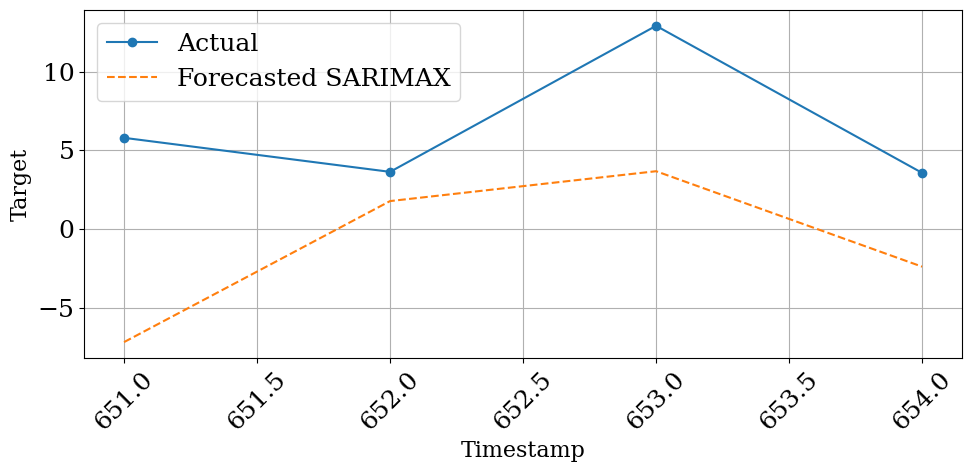

(7.491497020234585, 1.2796582069108946)

In [229]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt


# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(2, 0, 0), 
                seasonal_order=(1, 0, 1, 8), 
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
sarima_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics
sarima_mse = mean_absolute_error(test_data['Target'], sarima_predictions)
sarima_mape = mean_absolute_percentage_error(test_data['Target'], sarima_predictions)

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(test_data.index, test_data['Target'], label='Actual', marker='o')
plt.plot(test_data.index, sarima_predictions, label='Forecasted SARIMAX', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Output the MSE and MAPE values
sarima_mse, sarima_mape


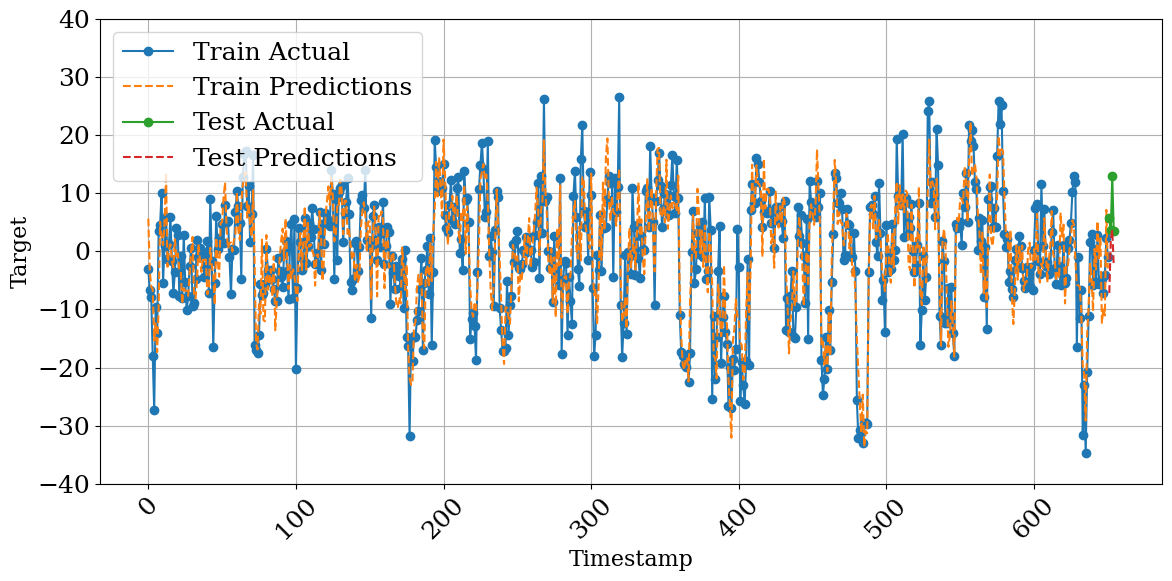

Train MAE: 4.2158
Train MAPE: 1.9157
Test MAE: 7.4915
Test MAPE: 1.2797


In [230]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(2, 0, 0), 
                seasonal_order=(1, 0, 1, 8), 
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# In-sample predictions for the training set
train_predictions = sarimax_results.predict(start=train_data.index[0], 
                                             end=train_data.index[-1], 
                                             exog=exog_train)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
test_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics for the training set
train_mae = mean_absolute_error(train_data['Target'], train_predictions)
train_mape = mean_absolute_percentage_error(train_data['Target'], train_predictions)

# Calculate evaluation metrics for the test set
test_mae = mean_absolute_error(test_data['Target'], test_predictions)
test_mape = mean_absolute_percentage_error(test_data['Target'], test_predictions)

# Plot the results: actual and predictions for both train and test data
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data['Target'], label='Train Actual', marker='o')
plt.plot(train_data.index, train_predictions, label='Train Predictions', linestyle='--')
plt.plot(test_data.index, test_data['Target'], label='Test Actual', marker='o')
plt.plot(test_data.index, test_predictions, label='Test Predictions', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(-40, 40)
plt.show()

# Output the evaluation metrics
print("Train MAE: {:.4f}".format(train_mae))
print("Train MAPE: {:.4f}".format(train_mape))
print("Test MAE: {:.4f}".format(test_mae))
print("Test MAPE: {:.4f}".format(test_mape))


   Combined_Sum
0     40.961331
1     53.922090
2     45.753743
3     47.756669
MAE: 7.65
MAPE: 14.06%


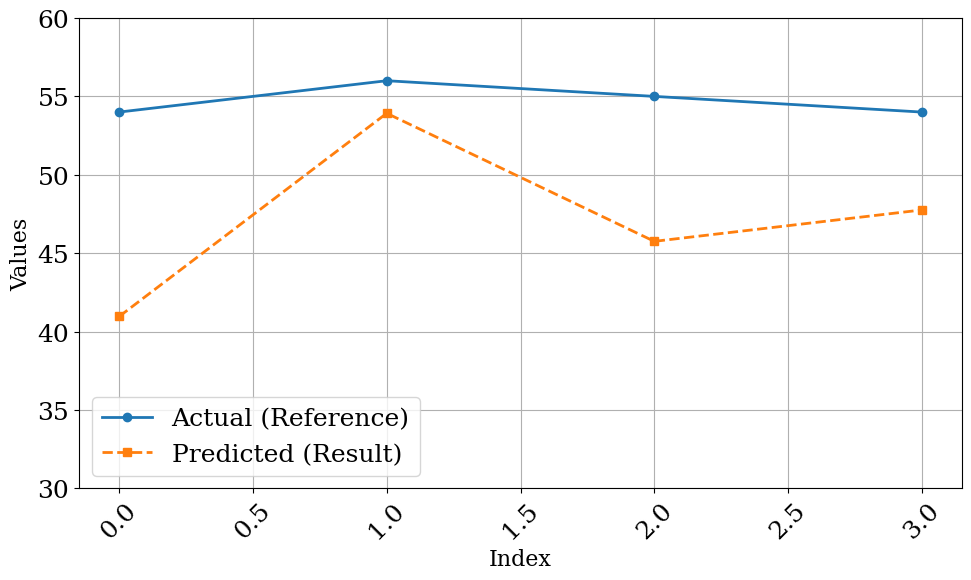

In [231]:
# Convert the DataFrames to NumPy arrays
sarimax_forecast_array = sarima_predictions.to_numpy().flatten()
summed_up_array = summed_up.to_numpy().flatten()

# Ensure both arrays have the same length
min_length = min(len(sarimax_forecast_array), len(summed_up_array))
sarimax_forecast_array = sarimax_forecast_array[:min_length]
summed_up_array = summed_up_array[:min_length]

# Perform element-wise summation
combined_sum_array = sarimax_forecast_array + summed_up_array

# Convert the result back to a DataFrame (optional)
result_df = pd.DataFrame(combined_sum_array, columns=['Combined_Sum'])

# Print the resulting DataFrame
print(result_df)

# Reset the index of the reference DataFrame
reference = reference.reset_index(drop=True)

# Ensure alignment of lengths
min_length = min(len(result_df), len(reference))
predicted = result_df.iloc[:min_length]['Combined_Sum']
test = reference.iloc[:min_length].squeeze()

# Calculate MAE and MAPE
mae = mean_absolute_error(test, predicted)
mape = mean_absolute_percentage_error(test, predicted)

# Print MAE and MAPE
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2%}")

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(test.index, test, label='Actual (Reference)', marker='o', linestyle='-', linewidth=2)
plt.plot(predicted.index, predicted, label='Predicted (Result)', marker='s', linestyle='--', linewidth=2)
 
plt.xlabel('Index')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(30, 60)
plt.show()


In [232]:
end_time=time.time()

In [233]:
Cost = end_time - start_time

In [234]:
main_results = update_results(main_results, 'SARIMA W ALL FEATUREs', mae, mape,Cost)

In [235]:
main_results

,Model_Name,MAE,MAPE,Cost
0,BASE SARIMA WITHOUT DECOMPOSITION,6.541955,0.119359,18.071575
1,BASE AUTO SARIMA WITHOUT DECOMPOSITION,4.204041,0.076676,40.555002
2,SARIMA by DECOMPOSITION W NO FEATURE,4.151245,0.075817,6.884008
3,AUTO SARIMA BY DECOMPOSITION W NO FEATURE,6.374455,0.116646,79.508049
4,Topological Dataset,0,0,0
5,SARIMA W ALL FEATUREs,6.828631,0.124984,80.456107
6,SARIMA W RFE FEATUREs,2.643748,0.048382,251.586817
7,SARIMA W RFE + PSO FEATUREs,5.279735,0.096445,5.185002
8,SARIMA W RFE + PSO BEST FEATUREs,5.279735,0.096445,7.869986
9,Regression Model W SELECTED FEATURES,5.782944,0.105559,168.565213


# MODEL 3-1 : SARIMA W RFE FEATURES

In [236]:
start_time=time.time()

In [237]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.utils import resample
import time
import warnings
import multiprocessing
from joblib import Parallel, delayed

warnings.filterwarnings("ignore")

start_time = time.time()

# Load dataset
df = data  # <-- make sure `data` is defined
target_column = "Target"
exog_columns = [col for col in df.columns if col != target_column]

# Split into training
train_df = df.iloc[:-4]
X_train = train_df[exog_columns]
y_train = train_df[target_column]

# SARIMAX p-value extractor
def get_p_values(X, y):
    try:
        model = SARIMAX(y, 
                        order=(2, 0, 0), 
                        seasonal_order=(1, 0, 1, 8), 
                        exog=X)
        result = model.fit(disp=False)
        return result.pvalues.loc[X.columns]
    except Exception as e:
        print("SARIMAX fit error:", e)
        return pd.Series([1.0] * X.shape[1], index=X.columns)

# Model AIC calculator
def compute_aic(feature_set):
    try:
        model = SARIMAX(y_train, 
                        order=(2, 0, 0), 
                        seasonal_order=(1, 0, 1, 8), 
                        exog=X_train[list(feature_set)])
        result = model.fit(disp=False)
        return (feature_set, result.aic)
    except:
        return (feature_set, np.inf)

# RFE parameters
selected_features = exog_columns.copy()
step2 = 5

# RFE Loop
while True:
    p_values = get_p_values(X_train[selected_features], y_train)

    # Features with p > 0.05
    worst_candidates = p_values[p_values > 0.05]

    # Stopping criterion
    if len(worst_candidates) < step2:
        print(f"Stopping early: Only {len(worst_candidates)} features have p > 0.05.")
        break

    # Dynamic step size
    step = min(20, len(worst_candidates), len(selected_features) // 2)

    # Worst features sorted by p-value
    worst_features = worst_candidates.sort_values(ascending=False).head(step).index

    for feature in worst_features:
        if feature in selected_features:
            selected_features.remove(feature)
            print(f"Removed Feature: {feature}, p-value: {p_values[feature]}")

print("\nInitial RFE Completed.")
print(f"Remaining Features: {len(selected_features)}")

# Optional: Stability Check via Bootstrapping
print("\nRunning stability check (bootstrap p-values)...")
bootstrap_rounds = 10
stable_features = []

boot_results = []
for i in range(bootstrap_rounds):
    X_res, y_res = resample(X_train[selected_features], y_train)
    p_vals = get_p_values(X_res, y_res)
    significant = set(p_vals[p_vals < 0.05].index)
    boot_results.append(significant)

stable_features = list(set.intersection(*boot_results))
print(f"\nStable Features Across {bootstrap_rounds} Bootstraps: {len(stable_features)}")

# Optional: AIC comparison for final selection
print("\nEvaluating AIC on stable subsets...")
feature_sets = [stable_features, selected_features]  # Compare both
num_cores = multiprocessing.cpu_count()

aic_values = Parallel(n_jobs=num_cores)(
    delayed(compute_aic)(f_set) for f_set in feature_sets
)

best_features, best_aic = sorted(aic_values, key=lambda x: x[1])[0]
print(f"\nBest AIC: {best_aic}")
print("Selected Final Features:", best_features)


Removed Feature: Operation__linear_trend__attr_"pvalue", p-value: 0.9968372204086946
Removed Feature: Operation__fourier_entropy__bins_5, p-value: 0.9937057141176366
Removed Feature: Operation__agg_linear_trend__attr_"rvalue"__chunk_len_10__f_agg_"var", p-value: 0.9923963676080118
Removed Feature: Operation__kurtosis, p-value: 0.9900054649997663
Removed Feature: Operation__fft_coefficient__attr_"real"__coeff_7, p-value: 0.9894364071773606
Removed Feature: Operation__index_mass_quantile__q_0.4, p-value: 0.9891466137356615
Removed Feature: Operation__fft_coefficient__attr_"imag"__coeff_9, p-value: 0.979352040868782
Removed Feature: Operation__ar_coefficient__coeff_5__k_10, p-value: 0.9602933784748916
Removed Feature: Operation__fft_coefficient__attr_"abs"__coeff_7, p-value: 0.958541139060342
Removed Feature: Operation__autocorrelation__lag_5, p-value: 0.9581039750254318
Removed Feature: Operation__spkt_welch_density__coeff_5, p-value: 0.9569824315528597
Removed Feature: Operation__fft_co

Removed Feature: Operation__fft_coefficient__attr_"abs"__coeff_10, p-value: 0.776491899202733
Removed Feature: Operation__longest_strike_below_mean, p-value: 0.7480265886015209
Removed Feature: Operation__approximate_entropy__m_2__r_0.3, p-value: 0.7017042592217608
Removed Feature: Operation__change_quantiles__f_agg_"var"__isabs_True__qh_0.6__ql_0.4, p-value: 0.6551052284994889
Removed Feature: Operation__change_quantiles__f_agg_"var"__isabs_False__qh_0.8__ql_0.6, p-value: 0.6252324277015999
Removed Feature: Operation__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.6, p-value: 0.5860984432526739
Removed Feature: Operation__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.2, p-value: 0.5831724495066044
Removed Feature: Operation__fft_coefficient__attr_"abs"__coeff_3, p-value: 0.5417344772544346
Removed Feature: Operation__ar_coefficient__coeff_8__k_10, p-value: 0.5326390570312145
Removed Feature: Operation__linear_trend__attr_"rvalue", p-value: 0.5187866708156998
Remove

Removed Feature: Operation__symmetry_looking__r_0.1, p-value: 0.30433302804434137
Removed Feature: Operation__agg_linear_trend__attr_"stderr"__chunk_len_10__f_agg_"max", p-value: 0.18539495797418792
Removed Feature: Operation__fft_coefficient__attr_"imag"__coeff_5, p-value: 0.14777098296163513
Removed Feature: Operation__fft_coefficient__attr_"angle"__coeff_0, p-value: 0.11427087355382029
Removed Feature: Operation__agg_linear_trend__attr_"slope"__chunk_len_5__f_agg_"var", p-value: 0.09015061778185086
Removed Feature: Operation__partial_autocorrelation__lag_2, p-value: 0.08941413940143218
Removed Feature: Operation__fft_coefficient__attr_"abs"__coeff_0, p-value: 0.08450452492287502
Removed Feature: Operation__energy_ratio_by_chunks__num_segments_10__segment_focus_1, p-value: 0.08076736014418229
Removed Feature: Operation__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.6, p-value: 0.07953556798960054
Removed Feature: Operation__fft_coefficient__attr_"imag"__coeff_6, p-value: 0

In [238]:
columns_to_keep = selected_features.copy()  # Make a copy of your list
if 'Target' not in columns_to_keep:
    columns_to_keep.append('Target')

data_rfe = data[columns_to_keep]

In [239]:
data_rfe

,Operation__median,Operation__standard_deviation,Operation__count_above_mean,Operation__first_location_of_maximum,Operation__maximum,Operation__quantile__q_0.9,Operation__autocorrelation__lag_1,"Operation__agg_autocorrelation__f_agg_""mean""__maxlag_40","Operation__agg_autocorrelation__f_agg_""median""__maxlag_40",Operation__number_peaks__n_1,...,"Operation__agg_linear_trend__attr_""intercept""__chunk_len_5__f_agg_""var""","Operation__agg_linear_trend__attr_""slope""__chunk_len_10__f_agg_""min""","Operation__agg_linear_trend__attr_""stderr""__chunk_len_5__f_agg_""min""","Operation__agg_linear_trend__attr_""stderr""__chunk_len_5__f_agg_""var""","Operation__agg_linear_trend__attr_""stderr""__chunk_len_10__f_agg_""min""","Operation__agg_linear_trend__attr_""stderr""__chunk_len_10__f_agg_""mean""","Operation__agg_linear_trend__attr_""stderr""__chunk_len_10__f_agg_""var""",Operation__number_crossing_m__m_1,Operation__energy_ratio_by_chunks__num_segments_10__segment_focus_9,Target
0,0.810038,0.329555,0.583333,0.130435,0.589920,0.667222,0.829801,0.643037,0.786532,0.333333,...,0.191991,0.403286,0.398732,0.275458,0.525132,0.342108,0.147108,0.307692,0.059986,-3.075369
1,0.795416,0.336719,0.500000,0.086957,0.589920,0.667222,0.788591,0.573085,0.602223,0.500000,...,0.218345,0.357888,0.440026,0.087934,0.469960,0.290813,0.119479,0.384615,0.068753,-6.716898
2,0.753105,0.352097,0.416667,0.043478,0.589920,0.667222,0.775236,0.462194,0.513661,0.500000,...,0.227720,0.403172,0.464104,0.151270,0.319809,0.165226,0.099811,0.384615,0.045095,-7.802650
3,0.719803,0.356604,0.500000,0.000000,0.589920,0.667222,0.753231,0.385383,0.550401,0.333333,...,0.179681,0.388477,0.436722,0.161480,0.304471,0.109663,0.069054,0.384615,0.091448,-18.026339
4,0.709948,0.387950,0.500000,0.000000,0.537914,0.604919,0.699473,0.278644,0.593038,0.333333,...,0.211017,0.250106,0.429725,0.220216,0.160044,0.068097,0.129804,0.384615,0.319479,-27.334787
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
650,0.451215,0.631480,0.666667,0.043478,0.484474,0.444779,0.691911,0.769816,0.765369,0.666667,...,0.780628,0.799625,0.469306,0.137824,0.005183,0.049910,0.428424,0.461538,0.007216,-0.982344
651,0.451215,0.598794,0.750000,0.000000,0.484474,0.235753,0.649238,0.765554,0.705681,0.666667,...,0.737673,0.799625,0.470405,0.179390,0.275989,0.137417,0.480890,0.538462,0.002103,5.799075
652,0.451215,0.566994,0.750000,0.000000,0.444554,0.235753,0.591953,0.721968,0.690059,0.666667,...,0.535315,0.842394,0.504195,0.146297,0.344335,0.137102,0.354920,0.615385,0.012561,3.641816
653,0.451215,0.531805,0.833333,0.956522,0.209760,0.235753,0.728160,0.466748,0.610532,0.833333,...,0.736017,0.883098,0.373248,0.329319,0.301850,0.104263,0.249148,0.538462,0.017609,12.900423


In [240]:
train_data = data_rfe[:-4]  # Last 4 rows for testing
test_data = data_rfe[-4:]

In [241]:
selected_columns_train = train_data.drop(columns=["Target"])
selected_columns_test = test_data.drop(columns=["Target"])

In [242]:
exog_train=selected_columns_train
exog_test=selected_columns_test 

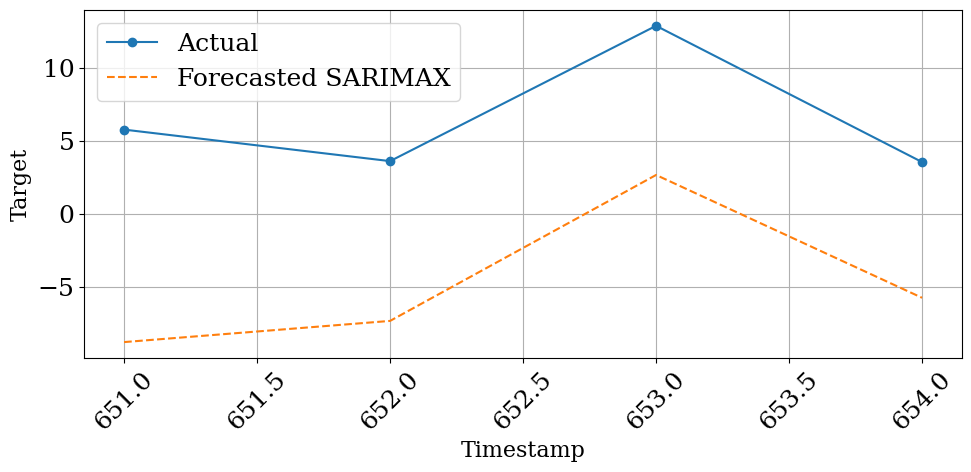

(11.241610767164403, 2.2242689619925162)

In [243]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt


# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(2, 0, 0), 
                seasonal_order=(1, 0, 1, 8), 
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
sarima_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics
sarima_mse = mean_absolute_error(test_data['Target'], sarima_predictions)
sarima_mape = mean_absolute_percentage_error(test_data['Target'], sarima_predictions)

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(test_data.index, test_data['Target'], label='Actual', marker='o')
plt.plot(test_data.index, sarima_predictions, label='Forecasted SARIMAX', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Output the MSE and MAPE values
sarima_mse, sarima_mape


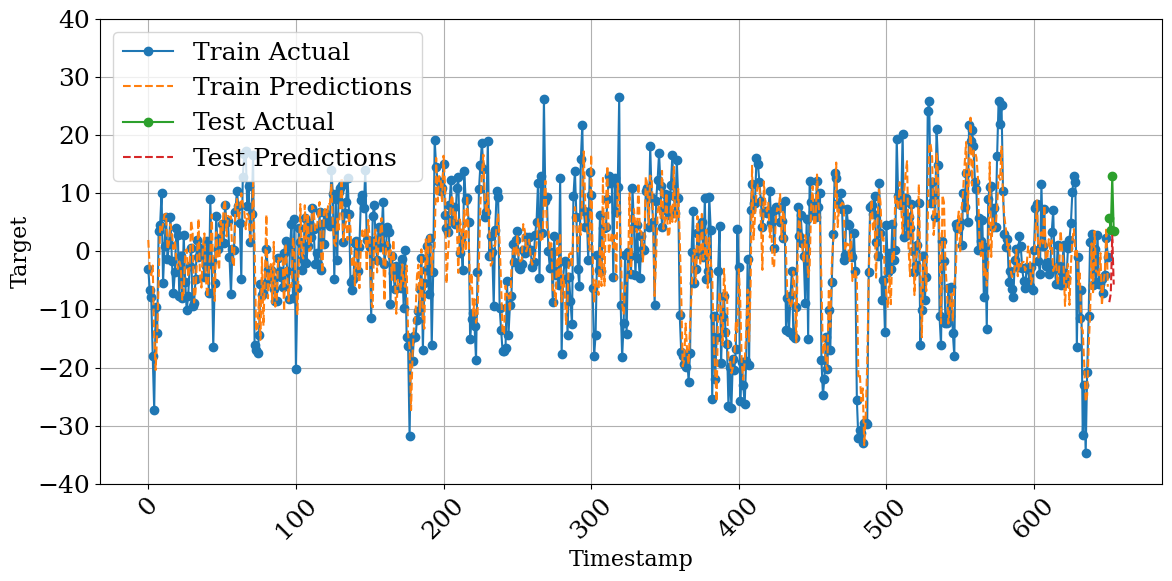

Train MAE: 5.1483
Train MAPE: 3.6105
Test MAE: 11.2416
Test MAPE: 2.2243


In [244]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(2, 0, 0), 
                seasonal_order=(1, 0, 1, 8), 
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# In-sample predictions for the training set
train_predictions = sarimax_results.predict(start=train_data.index[0], 
                                             end=train_data.index[-1], 
                                             exog=exog_train)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
test_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics for the training set
train_mae = mean_absolute_error(train_data['Target'], train_predictions)
train_mape = mean_absolute_percentage_error(train_data['Target'], train_predictions)

# Calculate evaluation metrics for the test set
test_mae = mean_absolute_error(test_data['Target'], test_predictions)
test_mape = mean_absolute_percentage_error(test_data['Target'], test_predictions)

# Plot the results: actual and predictions for both train and test data
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data['Target'], label='Train Actual', marker='o')
plt.plot(train_data.index, train_predictions, label='Train Predictions', linestyle='--')
plt.plot(test_data.index, test_data['Target'], label='Test Actual', marker='o')
plt.plot(test_data.index, test_predictions, label='Test Predictions', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(-40, 40)
plt.show()

# Output the evaluation metrics
print("Train MAE: {:.4f}".format(train_mae))
print("Train MAPE: {:.4f}".format(train_mape))
print("Test MAE: {:.4f}".format(test_mae))
print("Test MAPE: {:.4f}".format(test_mape))


   Combined_Sum
0     39.371397
1     44.841508
2     44.765302
3     44.415170
MAE: 11.40
MAPE: 20.84%


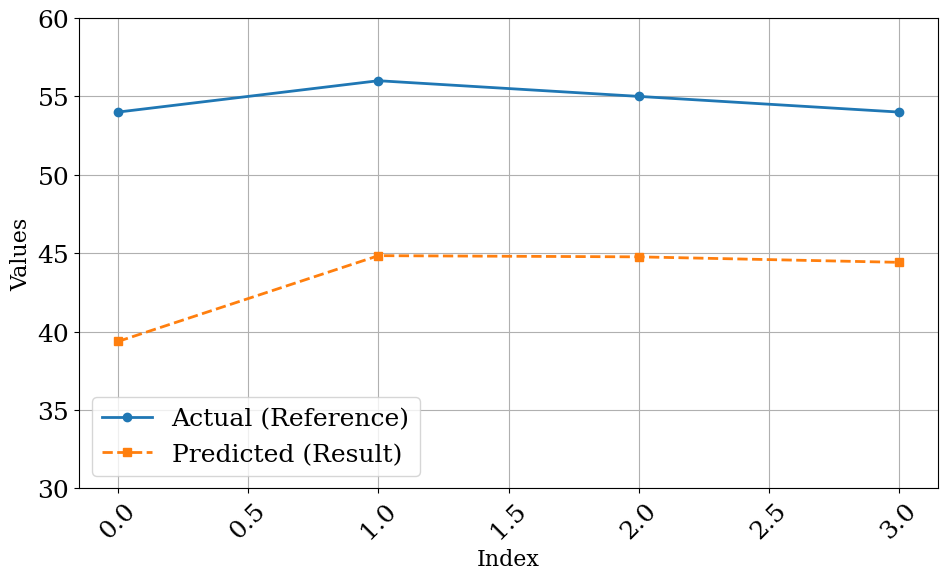

In [245]:
# Convert the DataFrames to NumPy arrays
sarimax_forecast_array = sarima_predictions.to_numpy().flatten()
summed_up_array = summed_up.to_numpy().flatten()

# Ensure both arrays have the same length
min_length = min(len(sarimax_forecast_array), len(summed_up_array))
sarimax_forecast_array = sarimax_forecast_array[:min_length]
summed_up_array = summed_up_array[:min_length]

# Perform element-wise summation
combined_sum_array = sarimax_forecast_array + summed_up_array

# Convert the result back to a DataFrame (optional)
result_df = pd.DataFrame(combined_sum_array, columns=['Combined_Sum'])

# Print the resulting DataFrame
print(result_df)

# Reset the index of the reference DataFrame
reference = reference.reset_index(drop=True)

# Ensure alignment of lengths
min_length = min(len(result_df), len(reference))
predicted = result_df.iloc[:min_length]['Combined_Sum']
test = reference.iloc[:min_length].squeeze()

# Calculate MAE and MAPE
mae = mean_absolute_error(test, predicted)
mape = mean_absolute_percentage_error(test, predicted)

# Print MAE and MAPE
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2%}")

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(test.index, test, label='Actual (Reference)', marker='o', linestyle='-', linewidth=2)
plt.plot(predicted.index, predicted, label='Predicted (Result)', marker='s', linestyle='--', linewidth=2)
 
plt.xlabel('Index')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(30, 60)
plt.show()


In [246]:
end_time=time.time()

In [247]:
Cost = end_time - start_time

In [248]:
main_results = update_results(main_results, 'SARIMA W RFE FEATUREs', mae, mape,Cost)

In [249]:
main_results

,Model_Name,MAE,MAPE,Cost
0,BASE SARIMA WITHOUT DECOMPOSITION,6.541955,0.119359,18.071575
1,BASE AUTO SARIMA WITHOUT DECOMPOSITION,4.204041,0.076676,40.555002
2,SARIMA by DECOMPOSITION W NO FEATURE,4.151245,0.075817,6.884008
3,AUTO SARIMA BY DECOMPOSITION W NO FEATURE,6.374455,0.116646,79.508049
4,Topological Dataset,0,0,0
5,SARIMA W ALL FEATUREs,6.828631,0.124984,80.456107
6,SARIMA W RFE FEATUREs,2.643748,0.048382,251.586817
7,SARIMA W RFE + PSO FEATUREs,5.279735,0.096445,5.185002
8,SARIMA W RFE + PSO BEST FEATUREs,5.279735,0.096445,7.869986
9,Regression Model W SELECTED FEATURES,5.782944,0.105559,168.565213


# MODEL 4 : SARIMA W RFE + PSO FEATURES

In [250]:
import numpy as np 
import pandas as pd
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pyswarm import pso  # Particle Swarm Optimization
from functools import lru_cache
from collections import Counter
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
start_time=time.time()
# Suppress warnings
warnings.filterwarnings("ignore")

# ============================
# Data Preparation
# ============================

target_column = 'Target'  # Replace with actual target column
train_data = data_rfe[:-4]  # Use all but the last 4 rows for training

selected_columns_train = train_data.drop(columns=[target_column])  # Features only
exog_train = selected_columns_train.values

num_features = selected_columns_train.shape[1]  # Number of features

# ============================
# Caching for Faster Execution
# ============================

solution_cache = {}

@lru_cache(maxsize=1000)
def evaluate_solution(solution_key):
    """
    Evaluates SARIMAX performance for a given feature subset using negative BIC.
    """
    selected_features = np.array(solution_key, dtype=bool)
    
    # Penalize solutions that select no features
    if not np.any(selected_features):
        return 1e6  

    exog_selected = exog_train[:, selected_features]

    try:
        model = SARIMAX(train_data[target_column],
                        order=(2, 0, 0),
                        seasonal_order=(1, 0, 1, 8),
                        exog=exog_selected,
                        enforce_stationarity=False,
                        enforce_invertibility=False)
        results = model.fit(disp=0, maxiter=30)  # Lower maxiter for speed
        return results.bic  # Minimize BIC
    except:
        return 1e6  # Strong penalty for errors

# ============================
# Define PSO Objective Function
# ============================

def pso_objective_function(solution):
    """
    Evaluates the fitness of a feature subset for PSO.
    """
    key = tuple(np.round(solution).astype(int))  # Convert to binary feature selection
    
    if key in solution_cache:
        return solution_cache[key]

    # Evaluate solution
    fitness_val = evaluate_solution(key)
    solution_cache[key] = fitness_val  # Store in cache
    return fitness_val

# ============================
# PSO Execution
# ============================

lb = [0] * num_features  # Lower bounds (0 = feature not selected)
ub = [1] * num_features  # Upper bounds (1 = feature selected)

selected_features_runs = []
best_results = []
num_columns = data_rfe.shape[1]-1
for run in range(5):
    print(f"Starting PSO optimization, run {run+1}...")

    best_solution, best_bic = best_solution, best_bic = pso(
    pso_objective_function, 
    lb, 
    ub, 
    swarmsize=40, 
    maxiter=100, 
    omega=0.7,  # Inertia weight
    phip=1.4,   # Cognitive parameter (similar to c1)
    phig=1.8,   # Social parameter (similar to c2)
    debug=False
)


    # Convert solution to selected feature names
    selected_features_mask = np.round(best_solution).astype(int).astype(bool)
    selected_features_pso = selected_columns_train.columns[selected_features_mask].tolist()
    selected_features_runs.append(selected_features_pso)

    # Fit final model with selected features
    exog_train_final = exog_train[:, selected_features_mask]


    final_model = SARIMAX(train_data[target_column],
                          order=(2, 0, 0),
                          seasonal_order=(1, 0, 1, 8),
                          exog=exog_train_final)
    final_results = final_model.fit(disp=False)
    


    # Save best results
    best_results.append({
        "Run": run + 1,
        "BIC": best_bic,
        "Selected Features": selected_features_pso
    })

# Convert to DataFrame
results_df = pd.DataFrame(best_results)

# Identify the best run (minimum BIC)
best_run = results_df.loc[results_df[['BIC']].sum(axis=1).idxmin()]
best_run_features = best_run["Selected Features"]

# Find the most frequently chosen features (chosen in at least 3 runs)
feature_counts = Counter(feature for run_features in selected_features_runs for feature in run_features)
final_feature_selection = list(feature_counts.keys())

# If final_feature_selection is empty, assign it to best_run_features
if not final_feature_selection:
    final_feature_selection = best_run_features

# Save best run features and final feature selection in separate lists
best_run_feature_list = list(best_run_features)
final_feature_selection_list = list(final_feature_selection)

# ============================
# Display Results
# ============================

print("\nPSO Runs Results:")
print(results_df)

print("\nBest Run Summary:")
print(best_run)

print("\nFinal Feature Selection (Chosen in at least 3 runs or from best run if empty):")
print(final_feature_selection_list)

print("\nBest Run Features List:")
print(best_run_feature_list)

# ============================
# Save Results
# ============================

# Convert to DataFrame for easy export if needed
best_run_summary_df = pd.DataFrame([best_run])
final_features_df = pd.DataFrame({"Most Chosen Features": final_feature_selection_list})


Starting PSO optimization, run 1...
Stopping search: maximum iterations reached --> 100
Starting PSO optimization, run 2...
Stopping search: maximum iterations reached --> 100
Starting PSO optimization, run 3...
Stopping search: maximum iterations reached --> 100
Starting PSO optimization, run 4...
Stopping search: maximum iterations reached --> 100
Starting PSO optimization, run 5...
Stopping search: maximum iterations reached --> 100

PSO Runs Results:
   Run          BIC                                  Selected Features
0    1  4363.448540  [Operation__standard_deviation, Operation__fir...
1    2  4361.542811  [Operation__standard_deviation, Operation__fir...
2    3  4333.252001  [Operation__standard_deviation, Operation__qua...
3    4  4326.424974  [Operation__first_location_of_maximum, Operati...
4    5  4350.335438  [Operation__first_location_of_maximum, Operati...

Best Run Summary:
Run                                                                  4
BIC                      

In [251]:
# Save best run features and final feature selection in separate lists
best_run_feature_list = list(best_run_features)
final_feature_selection_list = list(final_feature_selection)

In [252]:
# Convert selected_features_pso to a standard Python list
selected_features_pso = best_run_feature_list

# Add 'Target' to the selected features list
selected_features_pso.append('Target')

In [253]:
data_pso=data_rfe[selected_features_pso]

In [254]:
# Convert selected_features_pso to a standard Python list
selected_features_pso = final_feature_selection_list

# Add 'Target' to the selected features list
selected_features_pso.append('Target')

In [255]:
data_pso_best=data_rfe[selected_features_pso]

In [256]:
train_data = data_pso[:-4]  # Last 4 rows for testing
test_data = data_pso[-4:]

In [257]:
selected_columns_train = train_data.drop(columns=["Target"])
selected_columns_test = test_data.drop(columns=["Target"])

In [258]:
exog_train=selected_columns_train
exog_test=selected_columns_test 

In [259]:
start_time=time.time()

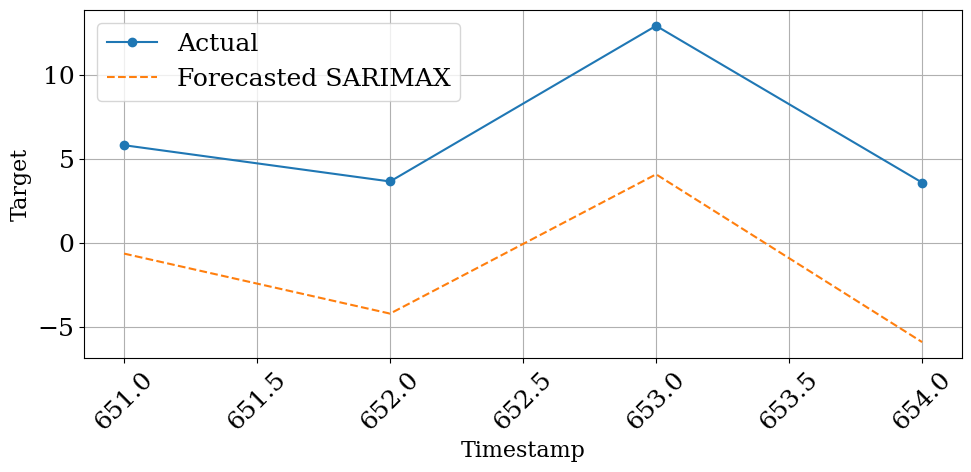

(8.156393258575644, 1.6517299843887743)

In [260]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt


# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(2, 0, 0), 
                seasonal_order=(1, 0, 1, 8), 
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
sarima_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics
sarima_mse = mean_absolute_error(test_data['Target'], sarima_predictions)
sarima_mape = mean_absolute_percentage_error(test_data['Target'], sarima_predictions)

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(test_data.index, test_data['Target'], label='Actual', marker='o')
plt.plot(test_data.index, sarima_predictions, label='Forecasted SARIMAX', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Output the MSE and MAPE values
sarima_mse, sarima_mape


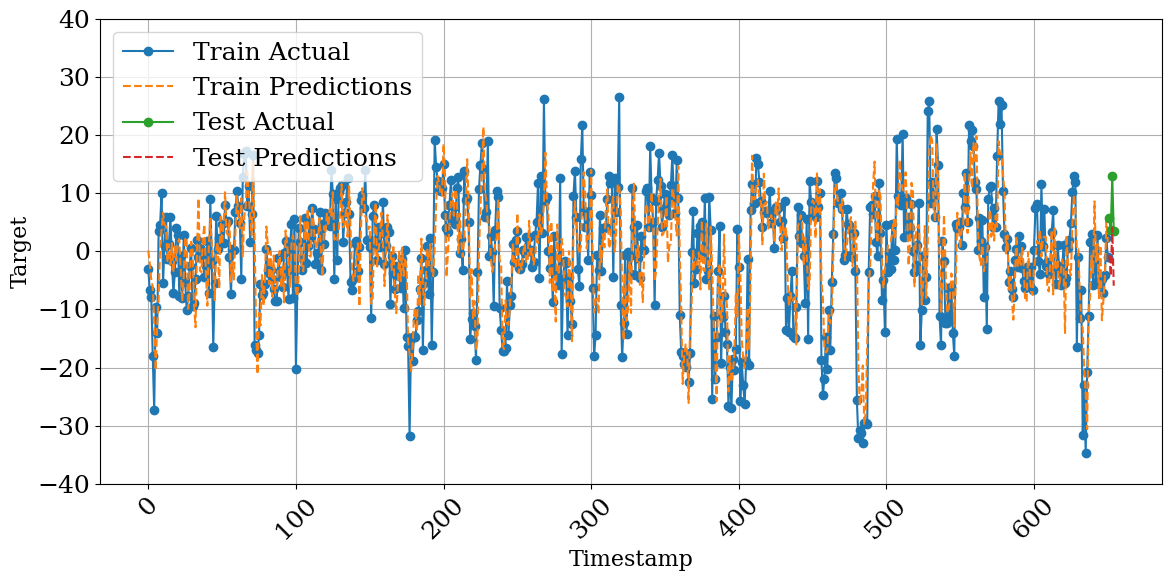

Train MAE: 5.0289
Train MAPE: 5.1714
Test MAE: 8.1564
Test MAPE: 1.6517


In [261]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(2, 0, 0), 
                seasonal_order=(1, 0, 1, 8), 
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# In-sample predictions for the training set
train_predictions = sarimax_results.predict(start=train_data.index[0], 
                                             end=train_data.index[-1], 
                                             exog=exog_train)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
test_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics for the training set
train_mae = mean_absolute_error(train_data['Target'], train_predictions)
train_mape = mean_absolute_percentage_error(train_data['Target'], train_predictions)

# Calculate evaluation metrics for the test set
test_mae = mean_absolute_error(test_data['Target'], test_predictions)
test_mape = mean_absolute_percentage_error(test_data['Target'], test_predictions)

# Plot the results: actual and predictions for both train and test data
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data['Target'], label='Train Actual', marker='o')
plt.plot(train_data.index, train_predictions, label='Train Predictions', linestyle='--')
plt.plot(test_data.index, test_data['Target'], label='Test Actual', marker='o')
plt.plot(test_data.index, test_predictions, label='Test Predictions', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(-40, 40)
plt.show()

# Output the evaluation metrics
print("Train MAE: {:.4f}".format(train_mae))
print("Train MAPE: {:.4f}".format(train_mape))
print("Test MAE: {:.4f}".format(test_mae))
print("Test MAPE: {:.4f}".format(test_mape))


   Combined_Sum
0     47.464438
1     47.915831
2     46.139525
3     44.214454
MAE: 8.32
MAPE: 15.19%


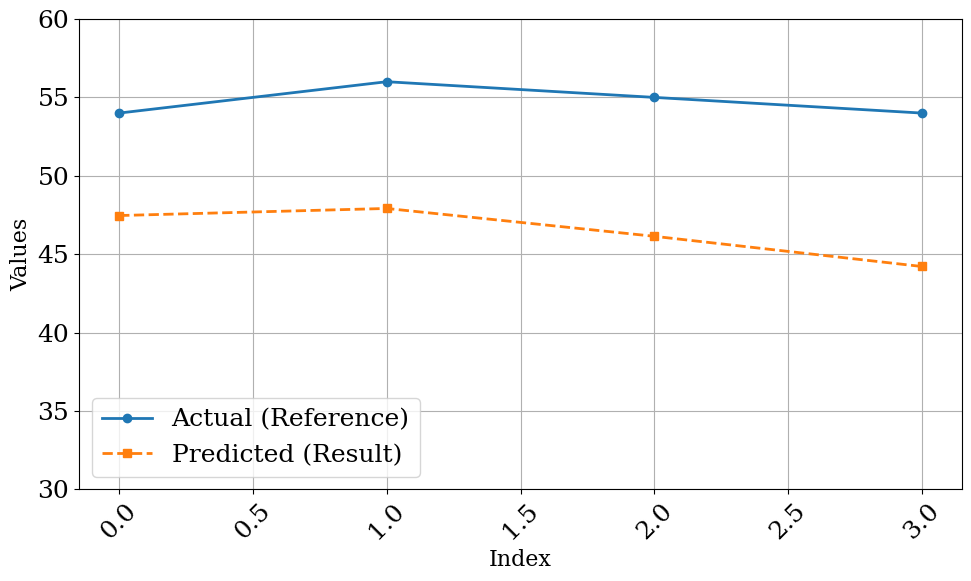

In [262]:
# Convert the DataFrames to NumPy arrays
sarimax_forecast_array = sarima_predictions.to_numpy().flatten()
summed_up_array = summed_up.to_numpy().flatten()

# Ensure both arrays have the same length
min_length = min(len(sarimax_forecast_array), len(summed_up_array))
sarimax_forecast_array = sarimax_forecast_array[:min_length]
summed_up_array = summed_up_array[:min_length]

# Perform element-wise summation
combined_sum_array = sarimax_forecast_array + summed_up_array

# Convert the result back to a DataFrame (optional)
result_df = pd.DataFrame(combined_sum_array, columns=['Combined_Sum'])

# Print the resulting DataFrame
print(result_df)

# Reset the index of the reference DataFrame
reference = reference.reset_index(drop=True)

# Ensure alignment of lengths
min_length = min(len(result_df), len(reference))
predicted = result_df.iloc[:min_length]['Combined_Sum']
test = reference.iloc[:min_length].squeeze()

# Calculate MAE and MAPE
mae = mean_absolute_error(test, predicted)
mape = mean_absolute_percentage_error(test, predicted)

# Print MAE and MAPE
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2%}")

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(test.index, test, label='Actual (Reference)', marker='o', linestyle='-', linewidth=2)
plt.plot(predicted.index, predicted, label='Predicted (Result)', marker='s', linestyle='--', linewidth=2)
 
plt.xlabel('Index')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(30, 60)
plt.show()


In [263]:
end_time=time.time()

In [264]:
Cost = end_time - start_time

In [265]:
main_results = update_results(main_results, 'SARIMA W RFE + PSO FEATUREs', mae, mape,Cost)

In [266]:
main_results

,Model_Name,MAE,MAPE,Cost
0,BASE SARIMA WITHOUT DECOMPOSITION,6.541955,0.119359,18.071575
1,BASE AUTO SARIMA WITHOUT DECOMPOSITION,4.204041,0.076676,40.555002
2,SARIMA by DECOMPOSITION W NO FEATURE,4.151245,0.075817,6.884008
3,AUTO SARIMA BY DECOMPOSITION W NO FEATURE,6.374455,0.116646,79.508049
4,Topological Dataset,0,0,0
5,SARIMA W ALL FEATUREs,6.828631,0.124984,80.456107
6,SARIMA W RFE FEATUREs,2.643748,0.048382,251.586817
7,SARIMA W RFE + PSO FEATUREs,5.279735,0.096445,5.185002
8,SARIMA W RFE + PSO BEST FEATUREs,5.279735,0.096445,7.869986
9,Regression Model W SELECTED FEATURES,5.782944,0.105559,168.565213


# MODEL 4 - 1: SARIMA W RFE+PSO BEST FEATURE SELECTION

In [267]:
start_time=time.time()

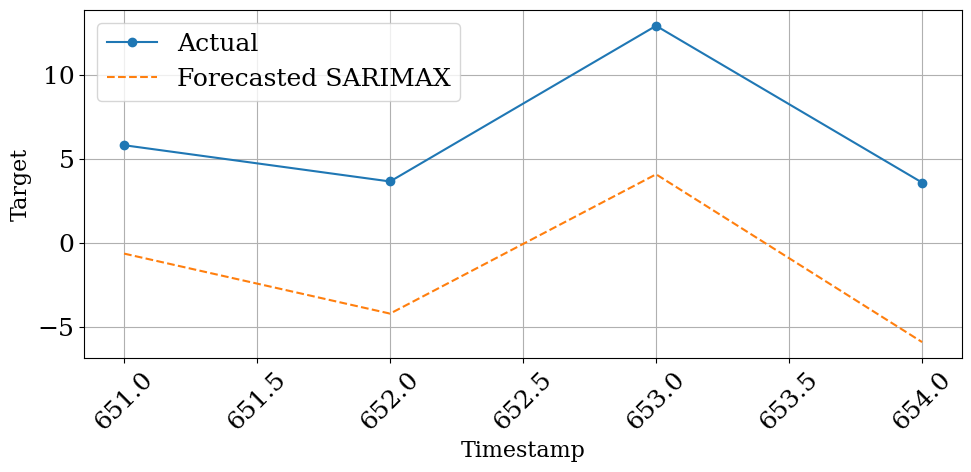

(8.156393258575644, 1.6517299843887743)

In [268]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt


# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(2, 0, 0), 
                seasonal_order=(1, 0, 1, 8), 
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
sarima_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics
sarima_mse = mean_absolute_error(test_data['Target'], sarima_predictions)
sarima_mape = mean_absolute_percentage_error(test_data['Target'], sarima_predictions)

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(test_data.index, test_data['Target'], label='Actual', marker='o')
plt.plot(test_data.index, sarima_predictions, label='Forecasted SARIMAX', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Output the MSE and MAPE values
sarima_mse, sarima_mape


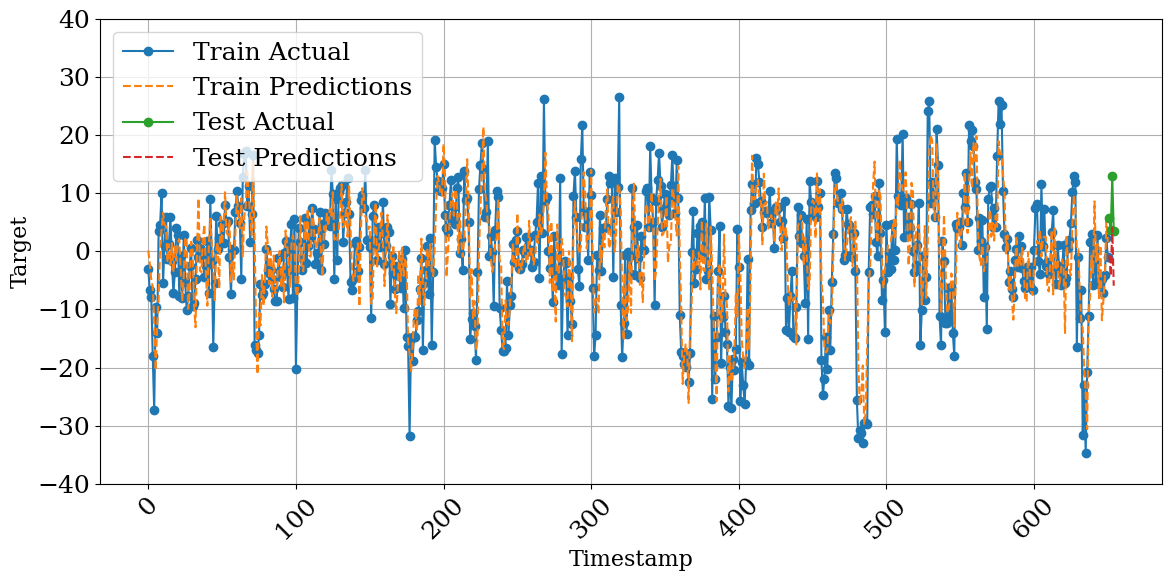

Train MAE: 5.0289
Train MAPE: 5.1714
Test MAE: 8.1564
Test MAPE: 1.6517


In [269]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(2, 0, 0), 
                seasonal_order=(1, 0, 1, 8), 
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# In-sample predictions for the training set
train_predictions = sarimax_results.predict(start=train_data.index[0], 
                                             end=train_data.index[-1], 
                                             exog=exog_train)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
test_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics for the training set
train_mae = mean_absolute_error(train_data['Target'], train_predictions)
train_mape = mean_absolute_percentage_error(train_data['Target'], train_predictions)

# Calculate evaluation metrics for the test set
test_mae = mean_absolute_error(test_data['Target'], test_predictions)
test_mape = mean_absolute_percentage_error(test_data['Target'], test_predictions)

# Plot the results: actual and predictions for both train and test data
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data['Target'], label='Train Actual', marker='o')
plt.plot(train_data.index, train_predictions, label='Train Predictions', linestyle='--')
plt.plot(test_data.index, test_data['Target'], label='Test Actual', marker='o')
plt.plot(test_data.index, test_predictions, label='Test Predictions', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(-40, 40)
plt.show()

# Output the evaluation metrics
print("Train MAE: {:.4f}".format(train_mae))
print("Train MAPE: {:.4f}".format(train_mape))
print("Test MAE: {:.4f}".format(test_mae))
print("Test MAPE: {:.4f}".format(test_mape))


   Combined_Sum
0     47.464438
1     47.915831
2     46.139525
3     44.214454
MAE: 8.32
MAPE: 15.19%


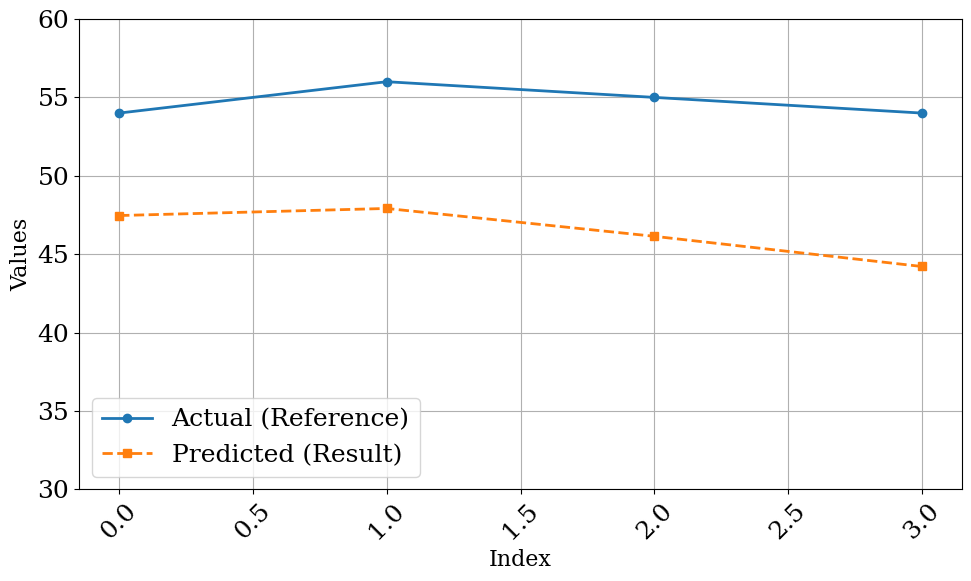

In [270]:
# Convert the DataFrames to NumPy arrays
sarimax_forecast_array = sarima_predictions.to_numpy().flatten()
summed_up_array = summed_up.to_numpy().flatten()

# Ensure both arrays have the same length
min_length = min(len(sarimax_forecast_array), len(summed_up_array))
sarimax_forecast_array = sarimax_forecast_array[:min_length]
summed_up_array = summed_up_array[:min_length]

# Perform element-wise summation
combined_sum_array = sarimax_forecast_array + summed_up_array

# Convert the result back to a DataFrame (optional)
result_df = pd.DataFrame(combined_sum_array, columns=['Combined_Sum'])

# Print the resulting DataFrame
print(result_df)

# Reset the index of the reference DataFrame
reference = reference.reset_index(drop=True)

# Ensure alignment of lengths
min_length = min(len(result_df), len(reference))
predicted = result_df.iloc[:min_length]['Combined_Sum']
test = reference.iloc[:min_length].squeeze()

# Calculate MAE and MAPE
mae = mean_absolute_error(test, predicted)
mape = mean_absolute_percentage_error(test, predicted)

# Print MAE and MAPE
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2%}")

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(test.index, test, label='Actual (Reference)', marker='o', linestyle='-', linewidth=2)
plt.plot(predicted.index, predicted, label='Predicted (Result)', marker='s', linestyle='--', linewidth=2)
 
plt.xlabel('Index')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(30, 60)
plt.show()


In [271]:
end_time=time.time()

In [272]:
Cost = end_time - start_time

In [273]:
main_results = update_results(main_results, 'SARIMA W RFE + PSO BEST FEATUREs', mae, mape,Cost)

In [274]:
main_results

,Model_Name,MAE,MAPE,Cost
0,BASE SARIMA WITHOUT DECOMPOSITION,6.541955,0.119359,18.071575
1,BASE AUTO SARIMA WITHOUT DECOMPOSITION,4.204041,0.076676,40.555002
2,SARIMA by DECOMPOSITION W NO FEATURE,4.151245,0.075817,6.884008
3,AUTO SARIMA BY DECOMPOSITION W NO FEATURE,6.374455,0.116646,79.508049
4,Topological Dataset,0,0,0
5,SARIMA W ALL FEATUREs,6.828631,0.124984,80.456107
6,SARIMA W RFE FEATUREs,2.643748,0.048382,251.586817
7,SARIMA W RFE + PSO FEATUREs,5.279735,0.096445,5.185002
8,SARIMA W RFE + PSO BEST FEATUREs,5.279735,0.096445,7.869986
9,Regression Model W SELECTED FEATURES,5.782944,0.105559,168.565213


# MODEL 5-1 : FEATURE SELECTION REGRESSION ANALYSIS

In [275]:
data

,Operation__abs_energy,Operation__mean_change,Operation__mean_second_derivative_central,Operation__median,Operation__standard_deviation,Operation__variation_coefficient,Operation__skewness,Operation__kurtosis,Operation__absolute_sum_of_changes,Operation__longest_strike_below_mean,...,Operation__energy_ratio_by_chunks__num_segments_10__segment_focus_3,Operation__energy_ratio_by_chunks__num_segments_10__segment_focus_9,Operation__ratio_beyond_r_sigma__r_0.5,Operation__count_below__t_0,Operation__fourier_entropy__bins_2,Operation__fourier_entropy__bins_3,Operation__fourier_entropy__bins_5,Operation__fourier_entropy__bins_100,Operation__permutation_entropy__dimension_4__tau_1,Target
0,0.184569,0.439970,0.618677,0.810038,0.329555,0.564462,0.357671,0.224677,0.247333,0.466667,...,0.028036,0.059986,0.357143,0.260870,0.000000,0.322247,0.395892,0.632177,0.393219,-3.075369
1,0.179562,0.303531,0.302599,0.795416,0.336719,0.564865,0.391174,0.194530,0.310401,0.466667,...,0.024357,0.068753,0.428571,0.304348,0.377411,0.322247,0.504556,0.782189,0.427124,-6.716898
2,0.177981,0.217588,0.412465,0.753105,0.352097,0.565675,0.430504,0.155050,0.307570,0.466667,...,0.028615,0.045095,0.500000,0.347826,0.377411,0.192461,0.504556,0.782189,0.516953,-7.802650
3,0.168026,0.160165,0.521801,0.719803,0.356604,0.567339,0.466188,0.134340,0.290276,0.333333,...,0.010817,0.091448,0.500000,0.391304,0.377411,0.506185,0.540017,0.891094,0.461029,-18.026339
4,0.177851,0.062338,0.469035,0.709948,0.387950,0.579397,0.436328,0.132618,0.340882,0.266667,...,0.271158,0.319479,0.357143,0.434783,0.377411,0.506185,0.576236,1.000000,0.388734,-27.334787
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
650,0.514205,0.332422,0.566143,0.451215,0.631480,0.558354,0.398384,0.174876,0.762873,0.333333,...,0.643931,0.007216,0.357143,0.695652,0.377411,0.506185,0.504556,0.632177,0.516953,-0.982344
651,0.500419,0.266202,0.487829,0.451215,0.598794,0.558668,0.382126,0.194666,0.765934,0.200000,...,0.207609,0.002103,0.357143,0.739130,0.377411,0.506185,0.504556,0.564378,0.516953,5.799075
652,0.482568,0.352743,0.997981,0.451215,0.566994,0.558880,0.343164,0.204121,0.798685,0.200000,...,0.051464,0.012561,0.428571,0.739130,0.377411,0.506185,0.504556,0.564378,0.427124,3.641816
653,0.465495,0.643842,0.275834,0.451215,0.531805,0.559099,0.294640,0.215960,0.648099,0.200000,...,0.017154,0.017609,0.428571,0.739130,0.377411,0.192461,0.423764,0.523272,0.516953,12.900423


In [276]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from xgboost import XGBRegressor

start_time=time.time()

# Step 1: Split the data
train_data = data[:-4]
test_data = data[-4:]

X_train = train_data.drop(columns=["Target"])
X_test = test_data.drop(columns=["Target"])
y_train = train_data["Target"]
y_test = test_data["Target"]

from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

In [277]:
from sklearn.ensemble import RandomForestRegressor
import numpy as np

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Get top k important features
importances = pd.Series(model.feature_importances_, index=X_train.columns)
selected_features = importances.sort_values(ascending=False).head(50).index  # choose top 20 or tune

X_train = X_train[selected_features]
X_test = X_test[selected_features]


In [278]:
X_train

,Operation__mean_change,Operation__energy_ratio_by_chunks__num_segments_10__segment_focus_9,Operation__median,"Operation__agg_linear_trend__attr_""rvalue""__chunk_len_10__f_agg_""mean""","Operation__fft_coefficient__attr_""real""__coeff_6","Operation__cwt_coefficients__coeff_1__w_5__widths_(2, 5, 10, 20)",Operation__max_langevin_fixed_point__m_3__r_30,"Operation__fft_coefficient__attr_""real""__coeff_3","Operation__fft_coefficient__attr_""imag""__coeff_3","Operation__change_quantiles__f_agg_""mean""__isabs_False__qh_1.0__ql_0.4",...,"Operation__change_quantiles__f_agg_""mean""__isabs_False__qh_0.4__ql_0.0",Operation__absolute_sum_of_changes,"Operation__agg_autocorrelation__f_agg_""var""__maxlag_40",Operation__ar_coefficient__coeff_8__k_10,Operation__ar_coefficient__coeff_6__k_10,Operation__ar_coefficient__coeff_2__k_10,Operation__ar_coefficient__coeff_3__k_10,"Operation__fft_coefficient__attr_""real""__coeff_5","Operation__change_quantiles__f_agg_""mean""__isabs_False__qh_0.8__ql_0.0",Operation__partial_autocorrelation__lag_5
0,0.439970,0.059986,0.810038,0.329270,0.419954,0.745629,0.034424,0.311753,0.409549,0.461418,...,0.476342,0.247333,0.083937,0.374652,0.526416,0.519117,0.420231,0.389909,0.507806,0.622472
1,0.303531,0.068753,0.795416,0.250414,0.558630,0.795243,0.069827,0.388497,0.262979,0.470309,...,0.332547,0.310401,0.058927,0.351560,0.488580,0.572916,0.377550,0.291911,0.368410,0.627042
2,0.217588,0.045095,0.753105,0.089361,0.702225,0.833496,0.063708,0.541748,0.185664,0.398640,...,0.300552,0.307570,0.113792,0.369349,0.500404,0.568748,0.369755,0.513628,0.335794,0.629562
3,0.160165,0.091448,0.719803,0.038301,0.603657,0.861712,0.077485,0.686360,0.198966,0.359277,...,0.356652,0.290276,0.227313,0.338465,0.487710,0.516815,0.382313,0.744125,0.356023,0.619593
4,0.062338,0.319479,0.709948,0.007089,0.508792,0.857140,0.033864,0.700081,0.229413,0.379874,...,0.286264,0.340882,0.498246,0.366253,0.417846,0.563613,0.379065,0.650824,0.278682,0.642923
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
646,0.408653,0.022421,0.470399,0.344210,0.543930,0.762263,0.018695,0.651770,0.385059,0.655849,...,0.476479,0.775596,0.057237,0.362649,0.473337,0.630189,0.226144,0.605863,0.752191,0.626600
647,0.361606,0.019165,0.465626,0.353119,0.822803,0.872675,0.017006,0.701752,0.494006,0.609153,...,0.476479,0.751259,0.057607,0.457423,0.441446,0.693189,0.373785,0.649285,0.704125,0.626729
648,0.320318,0.025539,0.451215,0.254801,0.487738,0.932448,0.014952,0.606071,0.566937,0.493700,...,0.476479,0.756611,0.057137,0.419060,0.379415,1.000000,0.000000,0.434515,0.661942,0.627760
649,0.322790,0.022976,0.451215,0.424523,0.278267,0.947461,0.014146,0.487113,0.569192,0.468298,...,0.476479,0.757890,0.052299,0.397616,0.504385,0.661822,0.271825,0.327414,0.684319,0.640503


In [279]:
import warnings
warnings.filterwarnings("ignore")  # Suppress all warnings

from sklearn.linear_model import Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, make_scorer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import pandas as pd
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
# Optional: scale for SVR and other sensitive models
scaler = StandardScaler()


tscv = TimeSeriesSplit(n_splits=5)

# Step 1: Define models and their hyperparameter grids
models = {
    "Lasso": (Lasso(), {
        "alpha": [0.001, 0.01, 0.1, 1, 10]
    }),
    "ElasticNet": (ElasticNet(), {
        "alpha": [0.001, 0.01, 0.1, 1, 10],
        "l1_ratio": [0.1, 0.5, 0.9]
    }),
    "RandomForest": (RandomForestRegressor(), {
        "n_estimators": [100, 200],
        "max_depth": [None, 10, 20]
    }),
    "XGBoost": (XGBRegressor(verbosity=0), {
        "n_estimators": [100, 200],
        "learning_rate": [0.01, 0.1],
        "max_depth": [3, 6]
    }),
    
    "CatBoost": (CatBoostRegressor(verbose=0), {
        "iterations": [100, 200],
        "learning_rate": [0.01, 0.1],
        "depth": [3, 6]
    }),
    "GradientBoosting": (GradientBoostingRegressor(), {
        "n_estimators": [100, 200],
        "learning_rate": [0.01, 0.1],
        "max_depth": [3, 6]
    }),
    "SVR": (Pipeline([
        ('scaler', StandardScaler()),
        ('svr', SVR())
    ]), {
        "svr__C": [0.1, 1, 10],
        "svr__epsilon": [0.01, 0.1]
    })
}

results = []

# Step 2: Run grid search and evaluate
for name, (model, param_grid) in models.items():
    print(f"🔍 Tuning {name}...")

    grid = GridSearchCV(model, param_grid, cv=tscv, scoring=make_scorer(mean_absolute_error, greater_is_better=False), n_jobs=-1)
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    preds = best_model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    mape = mean_absolute_percentage_error(y_test, preds)

    results.append({
        "Model": name,
        "MAE": mae,
        "MAPE": mape,
        "ModelObject": best_model,
        "BestParams": grid.best_params_
    })

# Step 3: Choose the best model based on MAE, then MAPE
results_df = pd.DataFrame(results).sort_values(by=["MAE", "MAPE"])
best = results_df.iloc[0]
best_model = best["ModelObject"]

print("✅ Best Model:", best["Model"])
print("🔹 MAE:", best["MAE"])
print("🔹 MAPE:", best["MAPE"])
print("🎯 Best Params:", best["BestParams"])


🔍 Tuning Lasso...
🔍 Tuning ElasticNet...
🔍 Tuning RandomForest...
🔍 Tuning XGBoost...
🔍 Tuning CatBoost...
🔍 Tuning GradientBoosting...
🔍 Tuning SVR...
✅ Best Model: GradientBoosting
🔹 MAE: 5.236803891758987
🔹 MAPE: 0.8126919263141769
🎯 Best Params: {'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 200}


<Figure size 1400x600 with 0 Axes>

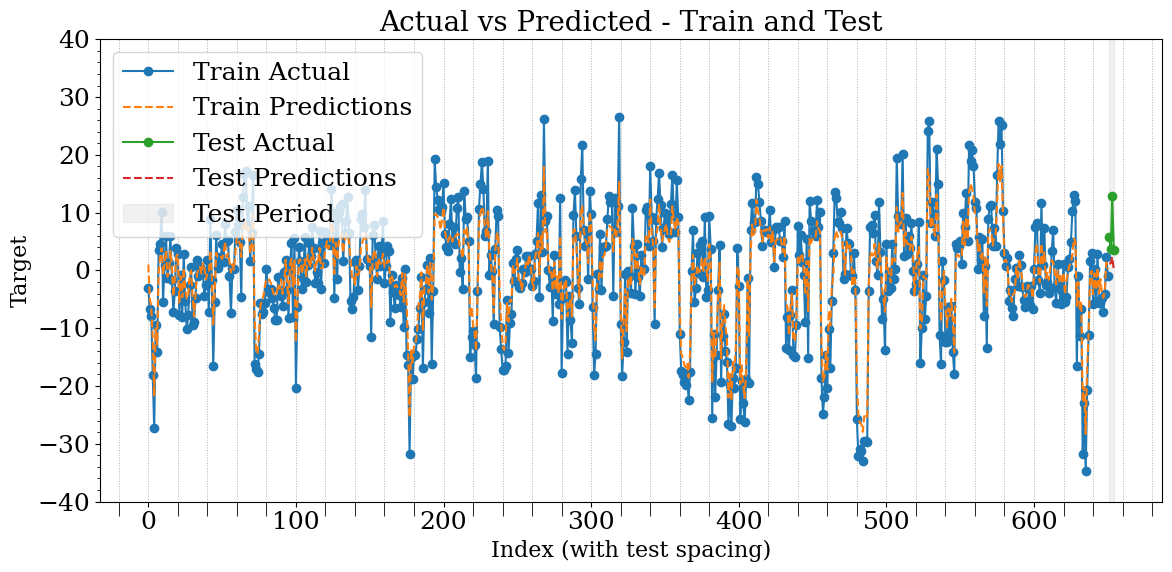

Train MAE: 2.9233
Train MAPE: 1.9907
Test MAE: 5.2465
Test MAPE: 0.8046


In [280]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# Train the best ML model on the training data

best_model.fit(X_train, y_train)

# In-sample predictions for the training set
train_predictions = best_model.predict(X_train)

# Forecasting for the test set
test_predictions = best_model.predict(X_test)

# Calculate evaluation metrics for the training set
train_mae = mean_absolute_error(y_train, train_predictions)
train_mape = mean_absolute_percentage_error(y_train, train_predictions)

# Calculate evaluation metrics for the test set
test_mae = mean_absolute_error(y_test, test_predictions)
test_mape = mean_absolute_percentage_error(y_test, test_predictions)


plt.figure(figsize=(14, 6))

# Convert index to a numeric range for controlled spacing
train_x = np.arange(len(train_data))
test_x = np.arange(len(test_data))  + len(train_data)  # 5x spacing and offset after train

# Plot actual and predicted values
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data['Target'], label='Train Actual', marker='o')
plt.plot(train_data.index, train_predictions, label='Train Predictions', linestyle='--')
plt.plot(test_data.index, test_data['Target'], label='Test Actual', marker='o')
plt.plot(test_data.index, test_predictions, label='Test Predictions', linestyle='--')

# Highlight the test period
plt.axvspan(test_x[0], test_x[-1], color='lightgray', alpha=0.3, label='Test Period')

# Make gridlines denser
plt.minorticks_on()
plt.grid(which='both', axis='x', linestyle=':', linewidth=0.7)
plt.tick_params(axis='x', which='minor', length=10)

# Add labels and legend
plt.xlabel('Index (with test spacing)')
plt.ylabel('Target')
plt.title('Actual vs Predicted - Train and Test')
plt.legend(loc='upper left')  # 👈 Changed legend position here
plt.tight_layout()
plt.ylim(-40, 40)
plt.show()

# Output the evaluation metrics
print("Train MAE: {:.4f}".format(train_mae))
print("Train MAPE: {:.4f}".format(train_mape))
print("Test MAE: {:.4f}".format(test_mae))
print("Test MAPE: {:.4f}".format(test_mape))


   Combined_Sum
0     48.689943
1     53.155983
2     44.077767
3     50.542508
MAE: 5.63
MAPE: 10.29%


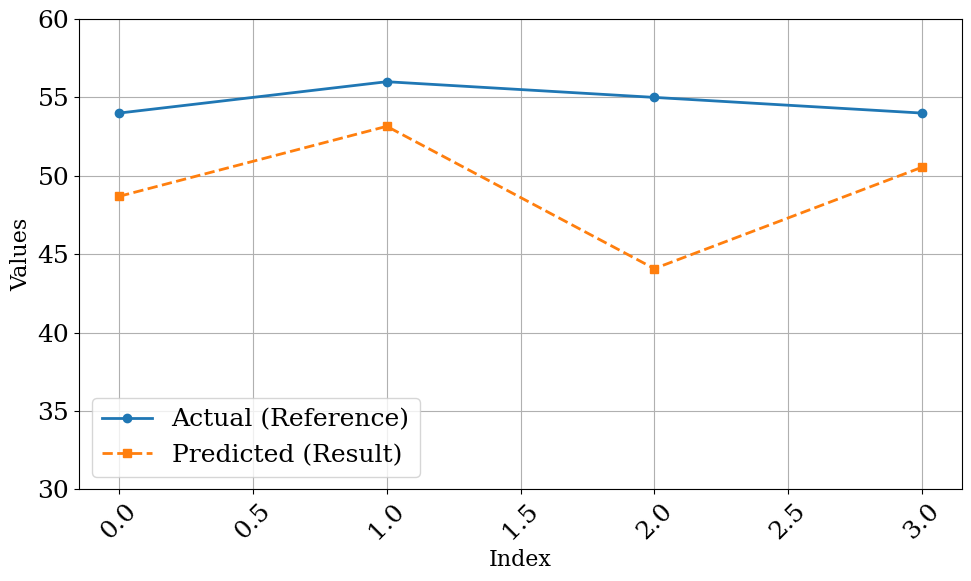

In [281]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# Fit the best model on the training data (exogenous features)
best_model.fit(X_train, y_train)

# Make predictions on the test set
predictions = best_model.predict(X_test)

# Convert the DataFrames to NumPy arrays
predictions_array = predictions.flatten()
summed_up_array = summed_up.to_numpy().flatten()

# Ensure both arrays have the same length
min_length = min(len(predictions_array), len(summed_up_array))
predictions_array = predictions_array[:min_length]
summed_up_array = summed_up_array[:min_length]

# Perform element-wise summation
combined_sum_array = predictions_array + summed_up_array

# Convert the result back to a DataFrame (optional)
result_df = pd.DataFrame(combined_sum_array, columns=['Combined_Sum'])

# Print the resulting DataFrame
print(result_df)

# Reset the index of the reference DataFrame
reference = reference.reset_index(drop=True)

# Ensure alignment of lengths
min_length = min(len(result_df), len(reference))
predicted = result_df.iloc[:min_length]['Combined_Sum']
test = reference.iloc[:min_length].squeeze()

# Calculate MAE and MAPE
mae = mean_absolute_error(test, predicted)
mape = mean_absolute_percentage_error(test, predicted)

# Print MAE and MAPE
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2%}")

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(test.index, test, label='Actual (Reference)', marker='o', linestyle='-', linewidth=2)
plt.plot(predicted.index, predicted, label='Predicted (Result)', marker='s', linestyle='--', linewidth=2)

plt.xlabel('Index')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(30, 60)
plt.show()




In [282]:
end_time=time.time()

In [283]:
Cost=end_time-start_time

In [284]:
main_results = update_results(main_results, 'Regression Model W SELECTED FEATURES', mae, mape, Cost)

In [285]:
main_results

,Model_Name,MAE,MAPE,Cost
0,BASE SARIMA WITHOUT DECOMPOSITION,6.541955,0.119359,18.071575
1,BASE AUTO SARIMA WITHOUT DECOMPOSITION,4.204041,0.076676,40.555002
2,SARIMA by DECOMPOSITION W NO FEATURE,4.151245,0.075817,6.884008
3,AUTO SARIMA BY DECOMPOSITION W NO FEATURE,6.374455,0.116646,79.508049
4,Topological Dataset,0,0,0
5,SARIMA W ALL FEATUREs,6.828631,0.124984,80.456107
6,SARIMA W RFE FEATUREs,2.643748,0.048382,251.586817
7,SARIMA W RFE + PSO FEATUREs,5.279735,0.096445,5.185002
8,SARIMA W RFE + PSO BEST FEATUREs,5.279735,0.096445,7.869986
9,Regression Model W SELECTED FEATURES,5.782944,0.105559,168.565213


# MODEL 5 : ALL FEATURES REGRESSION ANALYSIS

In [286]:
data

,Operation__abs_energy,Operation__mean_change,Operation__mean_second_derivative_central,Operation__median,Operation__standard_deviation,Operation__variation_coefficient,Operation__skewness,Operation__kurtosis,Operation__absolute_sum_of_changes,Operation__longest_strike_below_mean,...,Operation__energy_ratio_by_chunks__num_segments_10__segment_focus_3,Operation__energy_ratio_by_chunks__num_segments_10__segment_focus_9,Operation__ratio_beyond_r_sigma__r_0.5,Operation__count_below__t_0,Operation__fourier_entropy__bins_2,Operation__fourier_entropy__bins_3,Operation__fourier_entropy__bins_5,Operation__fourier_entropy__bins_100,Operation__permutation_entropy__dimension_4__tau_1,Target
0,0.184569,0.439970,0.618677,0.810038,0.329555,0.564462,0.357671,0.224677,0.247333,0.466667,...,0.028036,0.059986,0.357143,0.260870,0.000000,0.322247,0.395892,0.632177,0.393219,-3.075369
1,0.179562,0.303531,0.302599,0.795416,0.336719,0.564865,0.391174,0.194530,0.310401,0.466667,...,0.024357,0.068753,0.428571,0.304348,0.377411,0.322247,0.504556,0.782189,0.427124,-6.716898
2,0.177981,0.217588,0.412465,0.753105,0.352097,0.565675,0.430504,0.155050,0.307570,0.466667,...,0.028615,0.045095,0.500000,0.347826,0.377411,0.192461,0.504556,0.782189,0.516953,-7.802650
3,0.168026,0.160165,0.521801,0.719803,0.356604,0.567339,0.466188,0.134340,0.290276,0.333333,...,0.010817,0.091448,0.500000,0.391304,0.377411,0.506185,0.540017,0.891094,0.461029,-18.026339
4,0.177851,0.062338,0.469035,0.709948,0.387950,0.579397,0.436328,0.132618,0.340882,0.266667,...,0.271158,0.319479,0.357143,0.434783,0.377411,0.506185,0.576236,1.000000,0.388734,-27.334787
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
650,0.514205,0.332422,0.566143,0.451215,0.631480,0.558354,0.398384,0.174876,0.762873,0.333333,...,0.643931,0.007216,0.357143,0.695652,0.377411,0.506185,0.504556,0.632177,0.516953,-0.982344
651,0.500419,0.266202,0.487829,0.451215,0.598794,0.558668,0.382126,0.194666,0.765934,0.200000,...,0.207609,0.002103,0.357143,0.739130,0.377411,0.506185,0.504556,0.564378,0.516953,5.799075
652,0.482568,0.352743,0.997981,0.451215,0.566994,0.558880,0.343164,0.204121,0.798685,0.200000,...,0.051464,0.012561,0.428571,0.739130,0.377411,0.506185,0.504556,0.564378,0.427124,3.641816
653,0.465495,0.643842,0.275834,0.451215,0.531805,0.559099,0.294640,0.215960,0.648099,0.200000,...,0.017154,0.017609,0.428571,0.739130,0.377411,0.192461,0.423764,0.523272,0.516953,12.900423


In [287]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from xgboost import XGBRegressor

start_time=time.time()

# Step 1: Split the data
train_data = data[:-4]
test_data = data[-4:]

X_train = train_data.drop(columns=["Target"])
X_test = test_data.drop(columns=["Target"])
y_train = train_data["Target"]
y_test = test_data["Target"]

In [288]:
import warnings
warnings.filterwarnings("ignore")  # Suppress all warnings

from sklearn.linear_model import Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, make_scorer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import pandas as pd
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
# Optional: scale for SVR and other sensitive models
scaler = StandardScaler()


tscv = TimeSeriesSplit(n_splits=5)

# Step 1: Define models and their hyperparameter grids
models = {
    "Lasso": (Lasso(), {
        "alpha": [0.001, 0.01, 0.1, 1, 10]
    }),
    "ElasticNet": (ElasticNet(), {
        "alpha": [0.001, 0.01, 0.1, 1, 10],
        "l1_ratio": [0.1, 0.5, 0.9]
    }),
    "RandomForest": (RandomForestRegressor(), {
        "n_estimators": [100, 200],
        "max_depth": [None, 10, 20]
    }),
    "XGBoost": (XGBRegressor(verbosity=0), {
        "n_estimators": [100, 200],
        "learning_rate": [0.01, 0.1],
        "max_depth": [3, 6]
    }),
    
    "CatBoost": (CatBoostRegressor(verbose=0), {
        "iterations": [100, 200],
        "learning_rate": [0.01, 0.1],
        "depth": [3, 6]
    }),
    "GradientBoosting": (GradientBoostingRegressor(), {
        "n_estimators": [100, 200],
        "learning_rate": [0.01, 0.1],
        "max_depth": [3, 6]
    }),
    "SVR": (Pipeline([
        ('scaler', StandardScaler()),
        ('svr', SVR())
    ]), {
        "svr__C": [0.1, 1, 10],
        "svr__epsilon": [0.01, 0.1]
    })
}

results = []

# Step 2: Run grid search and evaluate
for name, (model, param_grid) in models.items():
    print(f"🔍 Tuning {name}...")

    grid = GridSearchCV(model, param_grid, cv=tscv, scoring=make_scorer(mean_absolute_error, greater_is_better=False), n_jobs=-1)
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    preds = best_model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    mape = mean_absolute_percentage_error(y_test, preds)

    results.append({
        "Model": name,
        "MAE": mae,
        "MAPE": mape,
        "ModelObject": best_model,
        "BestParams": grid.best_params_
    })

# Step 3: Choose the best model based on MAE, then MAPE
results_df = pd.DataFrame(results).sort_values(by=["MAE", "MAPE"])
best = results_df.iloc[0]
best_model = best["ModelObject"]

print("✅ Best Model:", best["Model"])
print("🔹 MAE:", best["MAE"])
print("🔹 MAPE:", best["MAPE"])
print("🎯 Best Params:", best["BestParams"])


🔍 Tuning Lasso...
🔍 Tuning ElasticNet...
🔍 Tuning RandomForest...
🔍 Tuning XGBoost...
🔍 Tuning CatBoost...
🔍 Tuning GradientBoosting...
🔍 Tuning SVR...
✅ Best Model: SVR
🔹 MAE: 5.1285183325864985
🔹 MAPE: 0.8276908976282233
🎯 Best Params: {'svr__C': 10, 'svr__epsilon': 0.1}


<Figure size 1400x600 with 0 Axes>

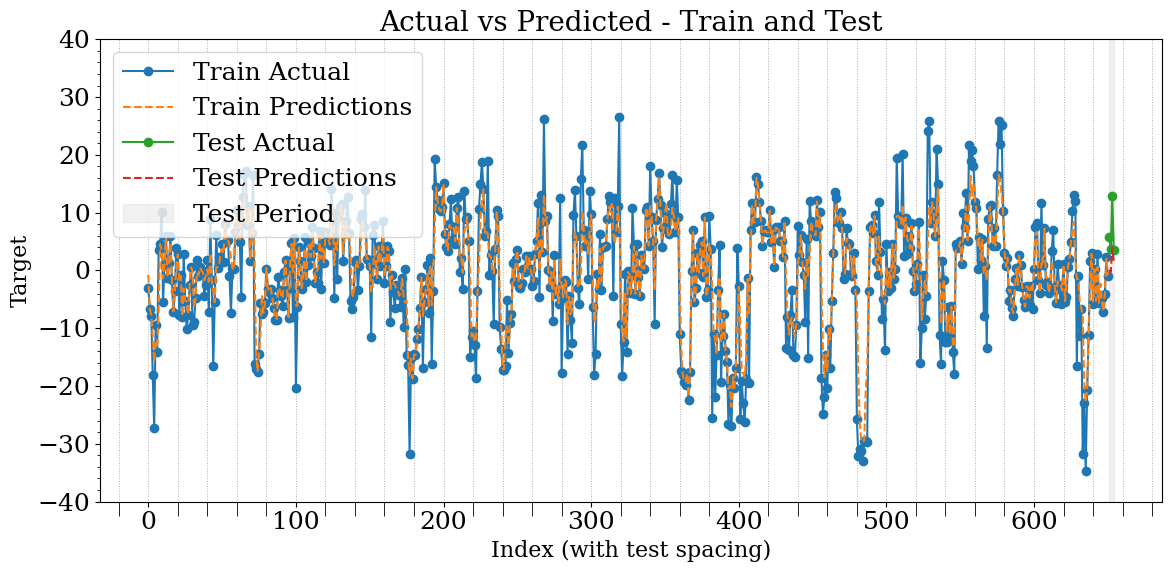

Train MAE: 2.3871
Train MAPE: 0.9572
Test MAE: 5.1285
Test MAPE: 0.8277


In [289]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# Train the best ML model on the training data

best_model.fit(X_train, y_train)

# In-sample predictions for the training set
train_predictions = best_model.predict(X_train)

# Forecasting for the test set
test_predictions = best_model.predict(X_test)

# Calculate evaluation metrics for the training set
train_mae = mean_absolute_error(y_train, train_predictions)
train_mape = mean_absolute_percentage_error(y_train, train_predictions)

# Calculate evaluation metrics for the test set
test_mae = mean_absolute_error(y_test, test_predictions)
test_mape = mean_absolute_percentage_error(y_test, test_predictions)


plt.figure(figsize=(14, 6))

# Convert index to a numeric range for controlled spacing
train_x = np.arange(len(train_data))
test_x = np.arange(len(test_data))  + len(train_data)  # 5x spacing and offset after train

# Plot actual and predicted values
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data['Target'], label='Train Actual', marker='o')
plt.plot(train_data.index, train_predictions, label='Train Predictions', linestyle='--')
plt.plot(test_data.index, test_data['Target'], label='Test Actual', marker='o')
plt.plot(test_data.index, test_predictions, label='Test Predictions', linestyle='--')

# Highlight the test period
plt.axvspan(test_x[0], test_x[-1], color='lightgray', alpha=0.3, label='Test Period')

# Make gridlines denser
plt.minorticks_on()
plt.grid(which='both', axis='x', linestyle=':', linewidth=0.7)
plt.tick_params(axis='x', which='minor', length=10)

# Add labels and legend
plt.xlabel('Index (with test spacing)')
plt.ylabel('Target')
plt.title('Actual vs Predicted - Train and Test')
plt.legend(loc='upper left')  # 👈 Changed legend position here
plt.tight_layout()
plt.ylim(-40, 40)
plt.show()

# Output the evaluation metrics
print("Train MAE: {:.4f}".format(train_mae))
print("Train MAPE: {:.4f}".format(train_mape))
print("Test MAE: {:.4f}".format(test_mae))
print("Test MAPE: {:.4f}".format(test_mape))


   Combined_Sum
0     48.245532
1     51.873510
2     46.073046
3     51.653659
MAE: 5.29
MAPE: 9.65%


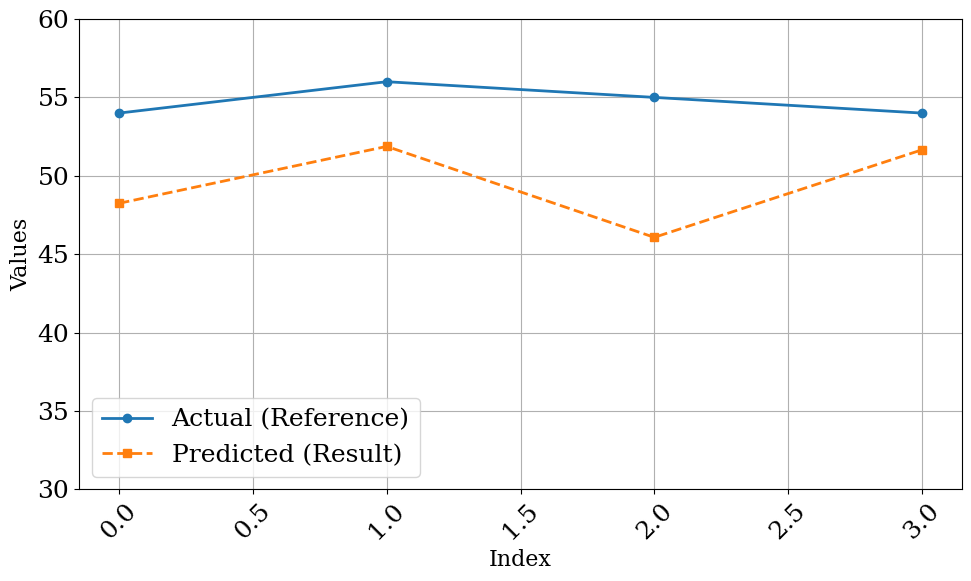

In [290]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# Fit the best model on the training data (exogenous features)
best_model.fit(X_train, y_train)

# Make predictions on the test set
predictions = best_model.predict(X_test)

# Convert the DataFrames to NumPy arrays
predictions_array = predictions.flatten()
summed_up_array = summed_up.to_numpy().flatten()

# Ensure both arrays have the same length
min_length = min(len(predictions_array), len(summed_up_array))
predictions_array = predictions_array[:min_length]
summed_up_array = summed_up_array[:min_length]

# Perform element-wise summation
combined_sum_array = predictions_array + summed_up_array

# Convert the result back to a DataFrame (optional)
result_df = pd.DataFrame(combined_sum_array, columns=['Combined_Sum'])

# Print the resulting DataFrame
print(result_df)

# Reset the index of the reference DataFrame
reference = reference.reset_index(drop=True)

# Ensure alignment of lengths
min_length = min(len(result_df), len(reference))
predicted = result_df.iloc[:min_length]['Combined_Sum']
test = reference.iloc[:min_length].squeeze()

# Calculate MAE and MAPE
mae = mean_absolute_error(test, predicted)
mape = mean_absolute_percentage_error(test, predicted)

# Print MAE and MAPE
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2%}")

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(test.index, test, label='Actual (Reference)', marker='o', linestyle='-', linewidth=2)
plt.plot(predicted.index, predicted, label='Predicted (Result)', marker='s', linestyle='--', linewidth=2)

plt.xlabel('Index')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(30, 60)
plt.show()




In [291]:
end_time=time.time()

In [292]:
Cost=end_time-start_time

In [293]:
main_results = update_results(main_results, 'Regression Model All', mae, mape, Cost)

In [294]:
main_results

,Model_Name,MAE,MAPE,Cost
0,BASE SARIMA WITHOUT DECOMPOSITION,6.541955,0.119359,18.071575
1,BASE AUTO SARIMA WITHOUT DECOMPOSITION,4.204041,0.076676,40.555002
2,SARIMA by DECOMPOSITION W NO FEATURE,4.151245,0.075817,6.884008
3,AUTO SARIMA BY DECOMPOSITION W NO FEATURE,6.374455,0.116646,79.508049
4,Topological Dataset,0,0,0
5,SARIMA W ALL FEATUREs,6.828631,0.124984,80.456107
6,SARIMA W RFE FEATUREs,2.643748,0.048382,251.586817
7,SARIMA W RFE + PSO FEATUREs,5.279735,0.096445,5.185002
8,SARIMA W RFE + PSO BEST FEATUREs,5.279735,0.096445,7.869986
9,Regression Model W SELECTED FEATURES,5.782944,0.105559,168.565213


# MODEL 6 HYBRID MODEL REGRESSION AND SARIMA

In [295]:
start_time=time.time()

In [296]:
# Step 4: Apply best model to the entire dataset
X_all = data.drop(columns=["Target"])
y_all = data["Target"]
preds_all = best_model.predict(X_all)

In [297]:
# Step 5: Create the difference DataFrame
diff_df = pd.DataFrame({
    "Actual": y_all.values,
    "Predicted": preds_all,
    "Difference": y_all.values - preds_all
}, index=data.index)

In [298]:
# Step 1: Create a new column 'Target' from the residuals
diff_df['Target'] = diff_df['Difference']

# Step 2: Split the data into train and test
y_train = diff_df[:-4]
y_test = diff_df[-4:]

In [299]:
from statsmodels.tsa.stattools import kpss

# Applying the KPSS test to the training data to test for stationarity
kpss_test = kpss(y_train['Target'], regression='c')

# Unpacking the KPSS test results
kpss_statistic, p_value, lags, critical_values = kpss_test

# Displaying the KPSS test results
kpss_test_result = {
    'KPSS Statistic': kpss_statistic,
    'p-value': p_value,
    'Lags Used': lags,
    'Critical Values': critical_values,
    'Conclusion': 'Stationary' if p_value > 0.05 else 'Not stationary'
}

kpss_test_result


{'KPSS Statistic': 0.08579029660816133,
 'p-value': 0.1,
 'Lags Used': 5,
 'Critical Values': {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739},
 'Conclusion': 'Stationary'}

In [300]:
from pmdarima.arima import auto_arima, OCSBTest, CHTest

# time series after first differencing
# OCSB test that returns the recommended order of seasonal differencing:
n_ocsb = OCSBTest(m=12).estimate_seasonal_differencing_term(y_train['Target'])

# CH test that returns the recommended order of seasonal differencing:
n_ch = CHTest(m=12).estimate_seasonal_differencing_term(y_train['Target'])

# seasonal differencing recommendation:
print("time series -")
n_seasdiffs = {"recommended order of seasonal differencing":"", "OCSB recommendation":n_ocsb, "nCH recommendation":n_ch}
[print(key, ":", value) for key,value in n_seasdiffs.items()]

time series -
recommended order of seasonal differencing : 
OCSB recommendation : 0
nCH recommendation : 0


[None, None, None]

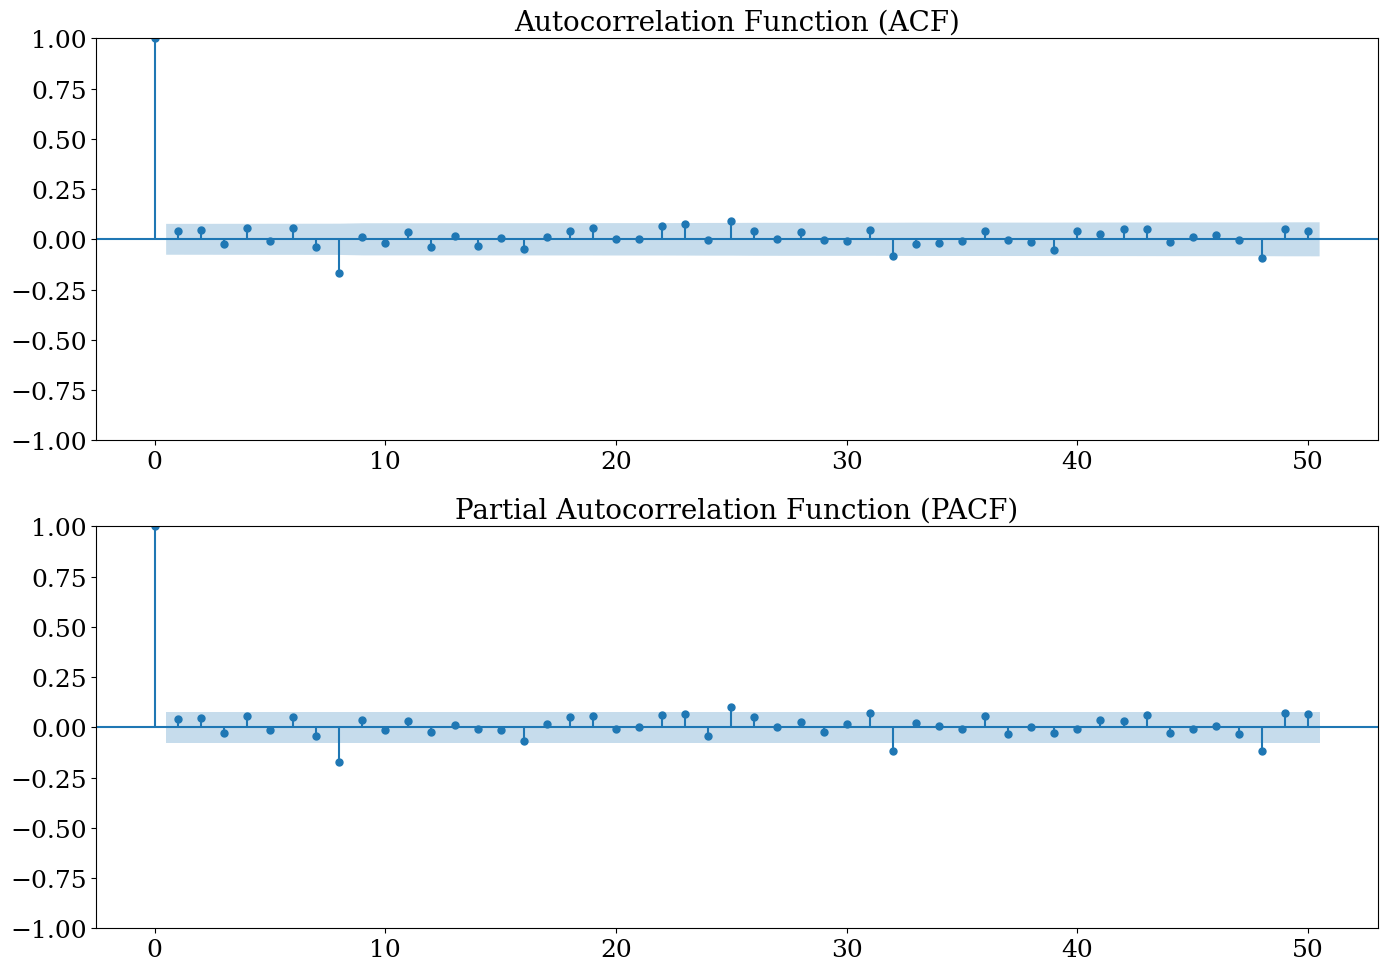

In [301]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot ACF and PACF for the cleaned training data
plt.figure(figsize=(14, 10))

# ACF plot
plt.subplot(2, 1, 1)
plot_acf(y_train['Target'], lags=50, ax=plt.gca())
plt.title("Autocorrelation Function (ACF)")

# PACF plot
plt.subplot(2, 1, 2)
plot_pacf(y_train['Target'], lags=50, ax=plt.gca(), method='ywm')
plt.title("Partial Autocorrelation Function (PACF)")

# Save the figure as an SVG file
plt.savefig("acf_h1.svg", format="svg", dpi=900, bbox_inches='tight', facecolor='white')
plt.tight_layout()
plt.show()

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[8] intercept   : AIC=3832.415, Time=0.06 sec
 ARIMA(1,0,0)(1,0,0)[8] intercept   : AIC=3816.862, Time=0.64 sec
 ARIMA(0,0,1)(0,0,1)[8] intercept   : AIC=3813.907, Time=0.65 sec
 ARIMA(0,0,0)(0,0,0)[8]             : AIC=3833.828, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[8] intercept   : AIC=3833.311, Time=0.11 sec
 ARIMA(0,0,1)(1,0,1)[8] intercept   : AIC=3808.456, Time=0.60 sec
 ARIMA(0,0,1)(1,0,0)[8] intercept   : AIC=3816.969, Time=0.25 sec
 ARIMA(0,0,1)(2,0,1)[8] intercept   : AIC=3808.917, Time=1.11 sec
 ARIMA(0,0,1)(1,0,2)[8] intercept   : AIC=3808.765, Time=1.17 sec
 ARIMA(0,0,1)(0,0,2)[8] intercept   : AIC=3812.575, Time=0.35 sec
 ARIMA(0,0,1)(2,0,0)[8] intercept   : AIC=3814.877, Time=0.60 sec
 ARIMA(0,0,1)(2,0,2)[8] intercept   : AIC=inf, Time=2.65 sec
 ARIMA(0,0,0)(1,0,1)[8] intercept   : AIC=3808.955, Time=0.30 sec
 ARIMA(1,0,1)(1,0,1)[8] intercept   : AIC=3797.830, Time=1.39 sec
 ARIMA(1,0,1)(0,0,1)[8] intercept   : 

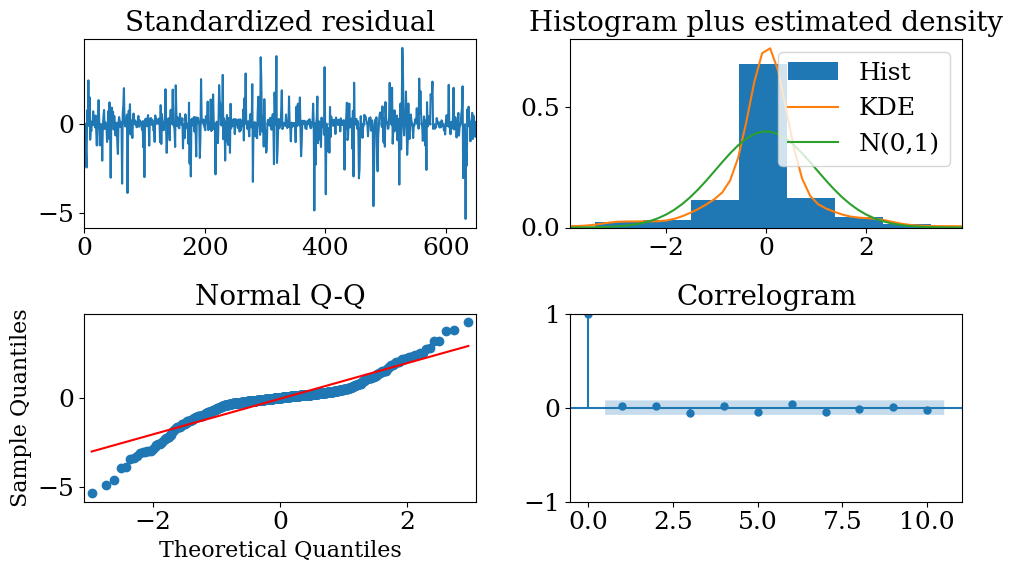

In [302]:
from pmdarima import auto_arima
import matplotlib.pyplot as plt

# Extract the time series from your training data
y_series = y_train['Target']

# Fit the seasonal ARIMA model
stepwise_model = auto_arima(
    y_series,
    start_p=0, start_q=0,
    max_p=5, max_q=5,
    seasonal=True,
    m=8,  # seasonal period
    start_P=0, start_Q=0,
    max_P=2, max_Q=2,
    d=None, D=None,           # let auto_arima figure out differencing
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True,
    information_criterion='aic'
)

# Print summary of the best model
print(stepwise_model.summary())

# Plot diagnostics
stepwise_model.plot_diagnostics(figsize=(10, 6))
plt.tight_layout()
plt.show()


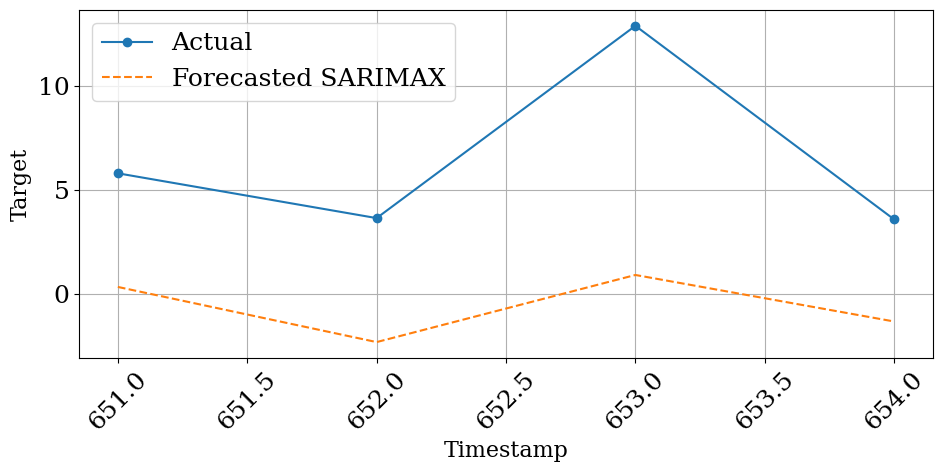

(7.087778292024841, 1.2215814087750088)

In [303]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt


n_periods = len(test_data)
sarima_predictions = stepwise_model.predict(n_periods=n_periods)

# Calculate evaluation metrics
sarima_mse = mean_absolute_error(test_data['Target'], sarima_predictions)
sarima_mape = mean_absolute_percentage_error(test_data['Target'], sarima_predictions)

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(test_data.index, test_data['Target'], label='Actual', marker='o')
plt.plot(test_data.index, sarima_predictions, label='Forecasted SARIMAX', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Output the MSE and MAPE values
sarima_mse, sarima_mape


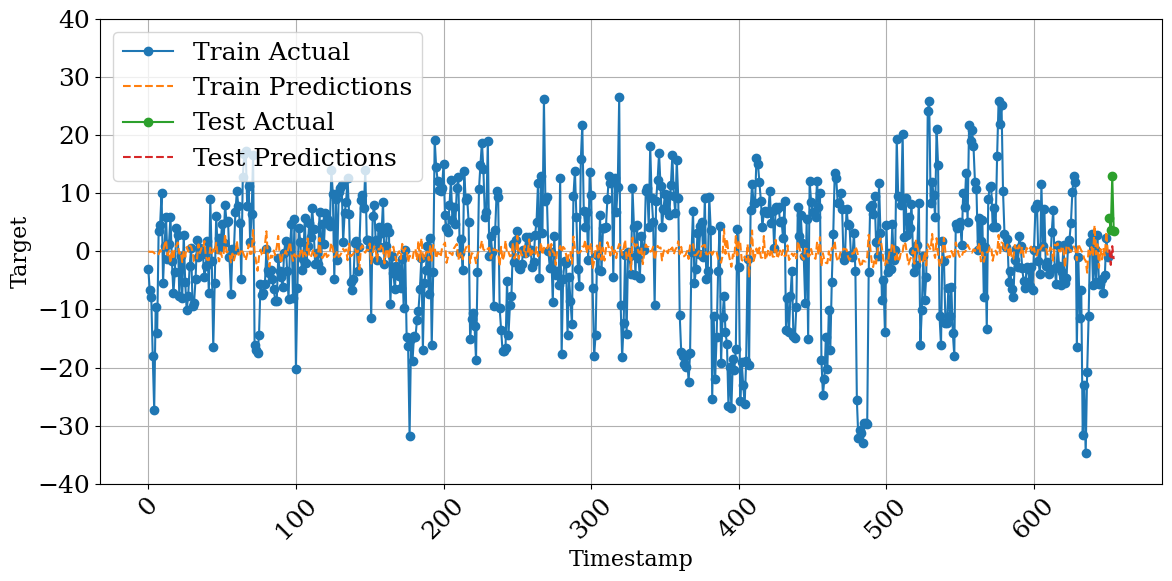

Train MAE: 7.8607
Train MAPE: 1.2015
Test MAE: 7.0878
Test MAPE: 1.2216


In [304]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# In-sample predictions for the training set
train_predictions = stepwise_model.predict_in_sample()

# Forecasting the values for the test set
test_predictions = stepwise_model.predict(n_periods=len(test_data))

# Calculate evaluation metrics for the training set
train_mae = mean_absolute_error(train_data['Target'], train_predictions)
train_mape = mean_absolute_percentage_error(train_data['Target'], train_predictions)

# Calculate evaluation metrics for the test set
test_mae = mean_absolute_error(test_data['Target'], test_predictions)
test_mape = mean_absolute_percentage_error(test_data['Target'], test_predictions)

# Plot the results: actual and predictions for both train and test data
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data['Target'], label='Train Actual', marker='o')
plt.plot(train_data.index, train_predictions, label='Train Predictions', linestyle='--')
plt.plot(test_data.index, test_data['Target'], label='Test Actual', marker='o')
plt.plot(test_data.index, test_predictions, label='Test Predictions', linestyle='--')

plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(-40, 40)
plt.show()

# Output the evaluation metrics
print("Train MAE: {:.4f}".format(train_mae))
print("Train MAPE: {:.4f}".format(train_mape))
print("Test MAE: {:.4f}".format(test_mae))
print("Test MAPE: {:.4f}".format(test_mape))


In [305]:
test_predictions

651    0.327630
652   -2.327806
653    0.903693
654   -1.336576
dtype: float64

In [306]:
# Combine them into one residual prediction series
residual_prediction = pd.concat([train_predictions, test_predictions])

In [307]:
residual_prediction

0      0.000000
1     -0.076696
2     -0.074421
3     -0.072198
4     -0.277064
         ...   
650   -0.494181
651    0.327630
652   -2.327806
653    0.903693
654   -1.336576
Length: 655, dtype: float64

In [308]:
# Step 2: Add SARIMA-predicted residuals to regression predictions
final_predictions = preds_all + residual_prediction

In [309]:
# Step 3: Create final DataFrame
final_df = pd.DataFrame({
    "Regression_Prediction": preds_all,
    "SARIMA_Residual_Prediction": residual_prediction,
    "Final_Prediction": final_predictions,
    "Actual": data["Target"],
    "Difference_Final": data["Target"] - final_predictions
})

# View sample
print(final_df.head())


   Regression_Prediction  SARIMA_Residual_Prediction  Final_Prediction  \
0              -0.759326                    0.000000         -0.759326   
1              -6.617089                   -0.076696         -6.693785   
2              -7.702405                   -0.074421         -7.776827   
3             -11.129329                   -0.072198        -11.201526   
4             -15.802967                   -0.277064        -16.080031   

      Actual  Difference_Final  
0  -3.075369         -2.316043  
1  -6.716898         -0.023114  
2  -7.802650         -0.025823  
3 -18.026339         -6.824813  
4 -27.334787        -11.254756  


In [310]:
sarimax_forecast_array = final_df["Final_Prediction"].iloc[-4:].values
print("📦 sarimax_forecast_array:")
print(sarimax_forecast_array)


📦 sarimax_forecast_array:
[ 0.46126558 -2.58718738  4.9053719   0.19147008]


   Combined_Sum
0     48.439526
1     49.805085
2     42.975060
3     48.789037
MAE: 7.25
MAPE: 13.22%


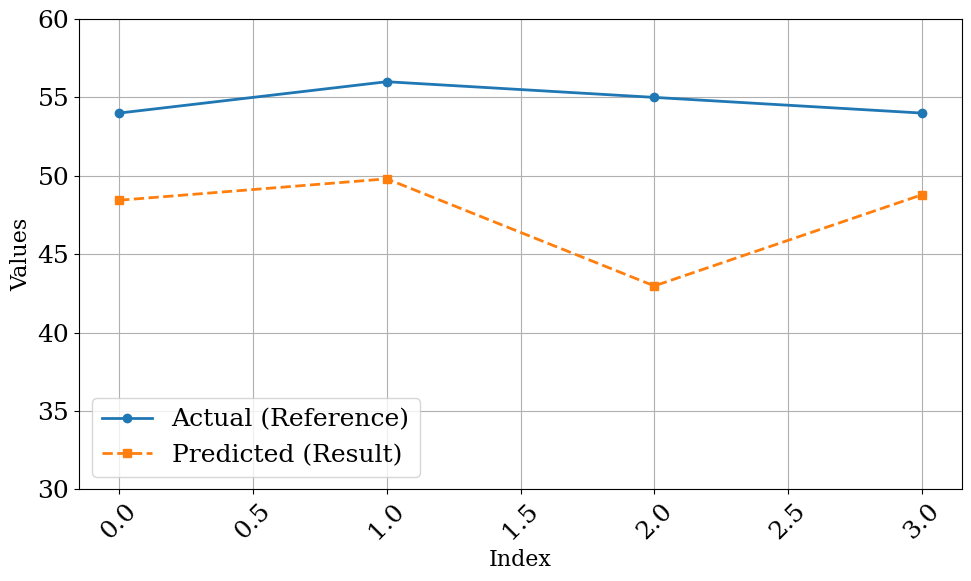

In [311]:
# Convert the DataFrames to NumPy arrays
sarimax_forecast_array = sarima_predictions.to_numpy().flatten()
summed_up_array = summed_up.to_numpy().flatten()

# Ensure both arrays have the same length
min_length = min(len(sarimax_forecast_array), len(summed_up_array))
sarimax_forecast_array = sarimax_forecast_array[:min_length]
summed_up_array = summed_up_array[:min_length]

# Perform element-wise summation
combined_sum_array = sarimax_forecast_array + summed_up_array

# Convert the result back to a DataFrame (optional)
result_df = pd.DataFrame(combined_sum_array, columns=['Combined_Sum'])

# Print the resulting DataFrame
print(result_df)

# Reset the index of the reference DataFrame
reference = reference.reset_index(drop=True)

# Ensure alignment of lengths
min_length = min(len(result_df), len(reference))
predicted = result_df.iloc[:min_length]['Combined_Sum']
test = reference.iloc[:min_length].squeeze()

# Calculate MAE and MAPE
mae = mean_absolute_error(test, predicted)
mape = mean_absolute_percentage_error(test, predicted)

# Print MAE and MAPE
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2%}")

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(test.index, test, label='Actual (Reference)', marker='o', linestyle='-', linewidth=2)
plt.plot(predicted.index, predicted, label='Predicted (Result)', marker='s', linestyle='--', linewidth=2)
 
plt.xlabel('Index')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(30, 60)
plt.show()


In [312]:
end_time=time.time()

In [313]:
Cost=end_time-start_time

In [314]:
main_results = update_results(main_results, 'Hybrid Model', mae, mape, Cost)

In [315]:
main_results

,Model_Name,MAE,MAPE,Cost
0,BASE SARIMA WITHOUT DECOMPOSITION,6.541955,0.119359,18.071575
1,BASE AUTO SARIMA WITHOUT DECOMPOSITION,4.204041,0.076676,40.555002
2,SARIMA by DECOMPOSITION W NO FEATURE,4.151245,0.075817,6.884008
3,AUTO SARIMA BY DECOMPOSITION W NO FEATURE,6.374455,0.116646,79.508049
4,Topological Dataset,0,0,0
5,SARIMA W ALL FEATUREs,6.828631,0.124984,80.456107
6,SARIMA W RFE FEATUREs,2.643748,0.048382,251.586817
7,SARIMA W RFE + PSO FEATUREs,5.279735,0.096445,5.185002
8,SARIMA W RFE + PSO BEST FEATUREs,5.279735,0.096445,7.869986
9,Regression Model W SELECTED FEATURES,5.782944,0.105559,168.565213


In [316]:
main_results.to_excel("main_results.xlsx", index=False)